# 20. Reinforcement Learning for Portfolio Allocation

In [2]:
from __future__ import annotations

import json
import math
import os
import random
import time
import warnings
from pathlib import Path

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_nfci, load_yfinance_panel, prices_to_returns_panel
from quantfinlab.ml.features import (
    assemble_forecasting_table,
    build_asset_feature_block,
    build_cross_asset_feature_block,
    build_fci_feature_block,
    clean_feature_columns,
    regime_probability_features,
    trim_feature_table_by_availability,
)
from quantfinlab.ml.evaluation import walkforward_tabular_predictions
from quantfinlab.ml.sequence_models import TcnForecast, torch_predictions, train_torch_model
from quantfinlab.plotting.curves import set_plot_style
from quantfinlab.plotting.portfolio import (
    active_return_curve,
    concentration_path,
    forecast_policy_sensitivity,
    plot_rolling_sharpe,
    plot_strategy_drawdowns,
    plot_strategy_nav,
    policy_exposure_path,
    policy_weight_area,
    regime_exposure_boxplot,
    turnover_cost_curve,
)
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import covariance, expected_returns, optimizers, views as bl_views
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary
from quantfinlab.portfolio.sizing import forecast_gated_maxsharpe_weight_frame, forecast_kelly_weight_frame
from quantfinlab.portfolio.universe import make_rebalance_dates
from quantfinlab.reports.risk_report import risk_report

warnings.filterwarnings("ignore")
set_plot_style()

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

repo_root = Path.cwd()
if not (repo_root / "data" / "core_cross_asset_etfs.csv").exists():
    repo_root = repo_root.parent
data_path = repo_root / "data" / "core_cross_asset_etfs.csv"
model_dir = repo_root / "models" / "project20_main_strong"
model_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
annualization = 252.0
cost_bps = 10.0
freq = "W-FRI"

assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "DBC", "GLD", "IEF", "TLT", "LQD", "HYG"]
cash_ticker = "SHY"
benchmark_ticker = "SPY"
signal_only_assets = ["AGG", "UUP"]
all_tickers = list(dict.fromkeys(assets + [cash_ticker, benchmark_ticker] + signal_only_assets))

tcn_epochs = 180
ppo_epochs_main = 180
rppo_epochs_main = 220
sac_epochs_main = 180

print({"device": str(device)})


{'device': 'cuda'}


In [2]:
panels = load_yfinance_panel(
    data_path,
    fields=("close", "volume"),
    tickers=all_tickers,
    source="yfinance_export",
    start="2007-01-01",
)
close_all = panels["close"].sort_index().ffill(limit=3)
volume_all = panels["volume"].sort_index().ffill(limit=3).reindex(close_all.index)

first_valid = close_all[assets + [cash_ticker]].dropna(how="any").index.min()
close = close_all.loc[first_valid:, [c for c in all_tickers if c in close_all.columns]].ffill(limit=3)
volume = volume_all.reindex(index=close.index, columns=close.columns).ffill(limit=3)
r_d = prices_to_returns_panel(close, kind="simple").replace([np.inf, -np.inf], np.nan).fillna(0.0)

coverage = pd.DataFrame({
    "first_valid": close[assets + [cash_ticker]].apply(pd.Series.first_valid_index),
    "last_valid": close[assets + [cash_ticker]].apply(pd.Series.last_valid_index),
    "observations": close[assets + [cash_ticker]].notna().sum(),
    "coverage": close[assets + [cash_ticker]].notna().mean(),
})
display(coverage)
print(close.index.min().date(), "to", close.index.max().date(), close.shape)


,first_valid,last_valid,observations,coverage
SPY,2007-04-11,2026-05-22,4897,1.0
QQQ,2007-04-11,2026-05-22,4897,1.0
IWM,2007-04-11,2026-05-22,4897,1.0
EFA,2007-04-11,2026-05-22,4897,1.0
EEM,2007-04-11,2026-05-22,4897,1.0
VNQ,2007-04-11,2026-05-22,4897,1.0
DBC,2007-04-11,2026-05-22,4897,1.0
GLD,2007-04-11,2026-05-22,4897,1.0
IEF,2007-04-11,2026-05-22,4897,1.0
TLT,2007-04-11,2026-05-22,4897,1.0


2007-04-11 to 2026-05-22 (4897, 15)


In [3]:
eligible_index = pd.DatetimeIndex(close.index)[252:]
decision_dates = pd.DatetimeIndex(
    pd.Series(eligible_index, index=eligible_index).resample(freq).last().dropna()
).intersection(close.index)
monthly_dates = make_rebalance_dates(close.index, freq="ME", min_history_days=252)

daily_summary = pd.DataFrame({
    "daily_mean": r_d[assets].mean(),
    "daily_vol": r_d[assets].std(ddof=1),
    "ann_vol": r_d[assets].std(ddof=1) * np.sqrt(252.0),
    "ann_return": r_d[assets].mean() * 252.0,
})
display(daily_summary.round(4))
print("weekly decisions:", len(decision_dates), decision_dates.min().date(), decision_dates.max().date())
print("monthly optimizer dates:", len(monthly_dates), monthly_dates.min().date(), monthly_dates.max().date())


,daily_mean,daily_vol,ann_vol,ann_return
SPY,0.0005,0.0123,0.1956,0.1216
QQQ,0.0007,0.0139,0.2207,0.1753
IWM,0.0004,0.0155,0.2459,0.1078
EFA,0.0003,0.0136,0.2157,0.0671
EEM,0.0003,0.0175,0.2772,0.0839
VNQ,0.0004,0.0186,0.2945,0.0945
DBC,0.0002,0.0120,0.1908,0.0390
GLD,0.0004,0.0113,0.1787,0.1101
IEF,0.0001,0.0044,0.0692,0.0332
TLT,0.0002,0.0095,0.1504,0.0390


weekly decisions: 947 2008-04-04 2026-05-22
monthly optimizer dates: 218 2008-04-30 2026-05-22


In [4]:
macro_path = repo_root / "data" / "us_macro_factors.csv"
nfci_path = repo_root / "data" / "nfci.csv"
macro_factors = load_macro_factors(macro_path, start="1990-01-01") if macro_path.exists() else pd.DataFrame()
nfci = load_nfci(nfci_path) if nfci_path.exists() else pd.DataFrame()

vix_path = repo_root / "data" / "vix_data.csv"
if vix_path.exists():
    vix_raw = pd.read_csv(vix_path)
    vix_raw["Date"] = pd.to_datetime(vix_raw["Date"], errors="coerce")
    vix_level = pd.to_numeric(vix_raw.dropna(subset=["Date"]).set_index("Date")["VIX"], errors="coerce").sort_index()
    vix_level = vix_level[~vix_level.index.duplicated(keep="last")].reindex(vix_level.index.union(close.index)).ffill().reindex(close.index)
    vix_z_20 = ((vix_level - vix_level.rolling(20, min_periods=10).mean()) / vix_level.rolling(20, min_periods=10).std(ddof=1)).clip(-4.0, 4.0)
    vix_ma_ratio_63 = (vix_level / vix_level.rolling(63, min_periods=21).mean().replace(0.0, np.nan)).clip(0.25, 4.0)
    vix_pct_252 = vix_level.rolling(252, min_periods=63).rank(pct=True)
    vix_x = pd.DataFrame({"vix_z_20": vix_z_20, "vix_ma_ratio_63": vix_ma_ratio_63, "vix_pct_252": vix_pct_252}).replace([np.inf, -np.inf], np.nan).fillna(0.0)
else:
    vix_x = pd.DataFrame(index=close.index)

def build_main_forecast_features(
    close,
    volume,
    returns,
    assets,
    rebalance_dates,
    *,
    cache_dir,
    force=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / "main_forecast_features_project19_v3.pkl"
    model_path = cache_dir / "tcnrank_project19_v3.pt"
    if cache_path.exists() and not force:
        cached = pd.read_pickle(cache_path)
        required = {
            "date",
            "asset",
            "sigma_21",
            "z_rf",
            "z_rf_active",
            "z_rf_rank",
            "z_tcn",
            "z_tcn_rank",
            "tcn_rank",
            "tcn_confidence",
        }
        if required.issubset(cached.columns):
            return cached

    horizon = 21
    train_end = pd.Timestamp("2018-12-31")
    validation_start = pd.Timestamp("2017-01-01")
    train_label_cutoff = train_end - pd.tseries.offsets.BDay(horizon)
    validation_end = train_label_cutoff

    r_log = np.log(close[assets] / close[assets].shift(1))
    fwd = np.log(close[assets].shift(-horizon) / close[assets])
    sigma_21 = r_log.rolling(63, min_periods=63).std(ddof=1) * np.sqrt(horizon)
    z_21 = (fwd - horizon * np.log1p(rf_daily)).div(sigma_21.replace(0.0, np.nan)).clip(-4.0, 4.0)
    y_alpha = z_21.sub(z_21.median(axis=1), axis=0).clip(-4.0, 4.0)
    target = (
        pd.concat({"sigma_21": sigma_21, "z_21": z_21, "y_alpha": y_alpha}, axis=1)
        .stack(level=1)
        .rename_axis(["date", "asset"])
        .reset_index()
        .dropna()
    )
    counts = target.groupby("date")["asset"].nunique()
    target = target[target["date"].isin(counts[counts.eq(len(assets))].index)].copy()
    last_label_date = pd.Timestamp(target["date"].max())
    model_rebalance_dates = pd.DatetimeIndex([d for d in rebalance_dates if d <= last_label_date])

    asset_features = build_asset_feature_block(close, volume, returns, assets=assets, rf_daily=rf_daily)
    cross_features = build_cross_asset_feature_block(close, returns, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
    fci_features = build_fci_feature_block(macro_factors, nfci, index=close.index)
    regime_features = regime_probability_features(
        close,
        returns,
        assets=assets,
        cash_ticker=cash_ticker,
        benchmark_ticker=benchmark_ticker,
        model="LogisticRegression",
        horizon=21,
        rebalance_dates=model_rebalance_dates,
        output="features",
        n_jobs=4,
    )
    regime_features = regime_features.reindex(close.index.union(regime_features.index)).sort_index().ffill().reindex(close.index)
    data = assemble_forecasting_table(target, asset_features, cross_features, fci_features, regime_features)
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["y_alpha", "z_21", "sigma_21"])
    data = data[data["asset"].isin(assets)].copy()
    full_dates = data.groupby("date")["asset"].nunique()
    data = data[data["date"].isin(full_dates[full_dates.eq(len(assets))].index)].copy()
    data = data.sort_values(["date", "asset"]).reset_index(drop=True)
    feature_cols = [c for c in data.columns if c not in {"date", "asset", "sigma_21", "z_21", "y_alpha"}]
    stage1 = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
    data, first_model_date, availability = trim_feature_table_by_availability(
        data,
        stage1,
        target_cols=["y_alpha", "sigma_21"],
        min_feature_coverage=0.75,
        min_asset_count=len(assets),
        min_target_complete=1.0,
    )
    stage1 = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
    for col in stage1:
        data[col] = data.groupby("asset", sort=False)[col].transform(lambda s: s.fillna(s.expanding().median().shift(1)))
    train_medians = data.loc[pd.to_datetime(data["date"]) <= train_label_cutoff, stage1].median()
    data[stage1] = data[stage1].fillna(train_medians).fillna(0.0)

    train_data = data[pd.to_datetime(data["date"]) <= train_label_cutoff].copy()
    rf_screen = RandomForestRegressor(
        n_estimators=800,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=seed,
        n_jobs=-1,
    )
    rf_screen.fit(train_data[stage1], train_data["y_alpha"])
    rf_importance = pd.Series(rf_screen.feature_importances_, index=stage1).sort_values(ascending=False)

    enet_scaler = StandardScaler()
    x_train_screen = enet_scaler.fit_transform(train_data[stage1])
    enet_screen = ElasticNet(alpha=0.003, l1_ratio=0.25, max_iter=12000, random_state=seed)
    enet_screen.fit(x_train_screen, train_data["y_alpha"])
    enet_coef = pd.Series(np.abs(enet_screen.coef_), index=stage1).sort_values(ascending=False)

    valid_feature_screen = data[pd.to_datetime(data["date"]).between(validation_start, validation_end)].copy()
    feature_rows = []
    for col in stage1:
        daily_ic, daily_spread = [], []
        for _, group in valid_feature_screen[["date", "asset", "y_alpha", col]].dropna().groupby("date"):
            if len(group) < 4 or group[col].nunique() < 2:
                continue
            daily_ic.append(group[col].corr(group["y_alpha"], method="spearman"))
            n = max(1, int(np.ceil(len(group) * 0.25)))
            ordered = group.sort_values(col)
            daily_spread.append(ordered.tail(n)["y_alpha"].mean() - ordered.head(n)["y_alpha"].mean())
        feature_rows.append({
            "feature": col,
            "valid_rank_ic": float(pd.Series(daily_ic).mean()) if daily_ic else np.nan,
            "valid_bucket_spread": float(pd.Series(daily_spread).mean()) if daily_spread else np.nan,
        })
    feature_rank_screen = pd.DataFrame(feature_rows).set_index("feature")
    feature_rank_screen["valid_score"] = (
        0.55 * feature_rank_screen["valid_rank_ic"].fillna(0.0)
        + 0.45 * feature_rank_screen["valid_bucket_spread"].fillna(0.0)
    )
    screen_rank = pd.concat(
        [
            rf_importance.rank(ascending=False).rename("rf_rank"),
            enet_coef.rank(ascending=False).rename("enet_rank"),
            feature_rank_screen["valid_score"].rank(ascending=False).rename("valid_rank"),
        ],
        axis=1,
    )
    screen_rank["mean_rank"] = screen_rank.mean(axis=1)
    core_features = screen_rank.sort_values("mean_rank").head(40).index.tolist()
    forecast_feature_keywords = ["rank_", "xs_z_", "group_rel_", "corr_", "resid_", "trend_consistency", "autocorr", "skew", "vol_of_vol", "downside_asym"]
    cs_features = [
        f for f in feature_rank_screen["valid_score"].sort_values(ascending=False).index
        if any(k in f for k in forecast_feature_keywords)
    ]
    selected_features = list(dict.fromkeys(core_features + cs_features[:25]))[:60]
    selected_features_tree = selected_features[:46] if selected_features else stage1[:46]
    nn_feature_keywords = [
        "rank_", "xs_z_", "group_rel_", "r_", "skip_r", "vol_", "sharpe_", "drawdown_",
        "trend_consistency", "autocorr", "skew", "vol_of_vol", "downside_asym", "corr_", "resid_",
        "p_risk", "p_neutral", "p_defensive", "regime_confidence", "fci", "stress",
    ]
    macro_penalty_keywords = ["inflation", "growth", "policy", "NFCI", "ANFCI", "leverage"]
    ranked_for_nn = feature_rank_screen["valid_score"].sort_values(ascending=False).index.tolist()
    selected_features_nn = [
        f for f in ranked_for_nn
        if f in selected_features and any(k in f for k in nn_feature_keywords)
    ]
    selected_features_nn += [f for f in selected_features if f not in selected_features_nn and not any(k in f for k in macro_penalty_keywords)]
    selected_features_nn = list(dict.fromkeys(selected_features_nn))[:28] if selected_features_nn else selected_features_tree[:28]
    project19_tcn_features = [
        "corr_spy_63",
        "rank_corr_spy_63",
        "vol_126",
        "trend_21_63_x_stress",
        "vol_of_vol_63",
        "rank_vol_of_vol_63",
        "sharpe_63",
        "rank_vol_63",
        "vol_63",
        "xs_z_vol_63",
        "rank_vol_63_x_p_defensive",
        "rank_r_63",
        "rel_r_63_avg",
        "xs_z_r_63",
        "rel_r_63_avg_x_fci",
        "rank_r_63_x_p_risk_on",
        "mom_63_vol63_x_p_risk_on",
        "down_vol_63",
        "rank_r_126",
        "rel_r_126_avg",
        "xs_z_r_126",
        "rank_sharpe_126",
        "xs_z_sharpe_126",
        "sharpe_126",
        "skip_r_21_252",
        "rank_skip_r_21_252",
        "xs_z_skip_r_21_252",
        "group_rel_vol_63",
    ]
    if all(f in stage1 for f in project19_tcn_features):
        selected_features_nn = project19_tcn_features

    asset_code = {asset: i for i, asset in enumerate(assets)}
    data["asset_id"] = data["asset"].map(asset_code).astype(int)

    dates = pd.to_datetime(data["date"])
    forecast_dates = pd.DatetimeIndex(pd.to_datetime(data.loc[dates >= validation_start, "date"].drop_duplicates())).sort_values()
    refit_dates = pd.DatetimeIndex(pd.Series(forecast_dates, index=forecast_dates).groupby(forecast_dates.to_period("Q")).first().to_list())
    pred_rf = walkforward_tabular_predictions(
        data[selected_features_tree],
        data["y_alpha"],
        dates,
        data["asset"],
        refit_dates=refit_dates,
        prediction_dates=forecast_dates,
        estimators={
            "z_rf": RandomForestRegressor(
                n_estimators=800,
                max_depth=6,
                min_samples_leaf=10,
                max_features="sqrt",
                random_state=seed,
                n_jobs=2,
            )
        },
        train_window=252 * 8,
        horizon=horizon,
        n_jobs=4,
        inner_threads=2,
        min_train=500,
    )

    nn_scaler = StandardScaler()
    train_mask_static = dates <= train_label_cutoff
    x_train_nn = data.loc[train_mask_static, selected_features_nn].copy()
    x_all_nn_z = pd.DataFrame(
        nn_scaler.fit(x_train_nn).transform(data[selected_features_nn]),
        index=data.index,
        columns=selected_features_nn,
    )
    seq_data = data[["date", "asset", "y_alpha", "z_21", "sigma_21", "asset_id"]].join(x_all_nn_z[selected_features_nn]).copy()
    seq_data = seq_data.sort_values(["asset", "date"])

    model = TcnForecast(
        n_features=len(selected_features_nn),
        n_assets=len(assets),
        embedding_dim=4,
        channels=(48, 48, 48),
        kernel_size=3,
        output_size=1,
        dropout=0.16,
    )
    if model_path.exists() and not force:
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
        except Exception as exc:
            print(f"Retraining TCNRank because checkpoint is incompatible: {exc}")
            model_path.unlink(missing_ok=True)
    else:
        model, hist = train_torch_model(
            model,
            data=seq_data,
            features=selected_features_nn,
            target="y_alpha",
            asset_col="asset_id",
            date_col="date",
            lookback=63,
            valid_start=validation_start,
            valid_end=validation_end,
            epochs=tcn_epochs,
            batch_size=256,
            lr=1e-3,
            weight_decay=1e-4,
            patience=35,
            loss_name="huber",
            early_stop_metric="composite",
            device=device,
        )
        cache_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), model_path)
        hist.to_csv(cache_dir / "tcnrank_project19_v3_training_history.csv", index=False)
    if not model_path.exists():
        model, hist = train_torch_model(
            model,
            data=seq_data,
            features=selected_features_nn,
            target="y_alpha",
            asset_col="asset_id",
            date_col="date",
            lookback=63,
            valid_start=validation_start,
            valid_end=validation_end,
            epochs=tcn_epochs,
            batch_size=256,
            lr=1e-3,
            weight_decay=1e-4,
            patience=35,
            loss_name="huber",
            early_stop_metric="composite",
            device=device,
        )
        cache_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), model_path)
        hist.to_csv(cache_dir / "tcnrank_project19_v3_training_history.csv", index=False)

    pred = torch_predictions(
        model,
        data=seq_data,
        features=selected_features_nn,
        asset_col="asset_id",
        date_col="date",
        lookback=63,
        batch_size=512,
        device=device,
    )
    pred_tcn = data.loc[pred.index, ["date", "asset"]].copy()
    pred_tcn["z_tcn"] = pd.Series(pred, index=pred.index).to_numpy(dtype=float)

    out = data[["date", "asset", "sigma_21", "z_21", "y_alpha"]].copy()
    out = out.merge(pred_rf, on=["date", "asset"], how="left")
    out = out.merge(pred_tcn, on=["date", "asset"], how="left")
    out["tcn_alpha"] = out["z_tcn"]
    out["z_tcn_rank"] = out.groupby("date")["z_tcn"].rank(pct=True) - 0.5
    out["tcn_rank"] = out["z_tcn_rank"]
    out["z_rf_rank"] = out.groupby("date")["z_rf"].rank(pct=True) - 0.5
    rf_alpha_h = out["z_rf"] * out["sigma_21"]
    rf_alpha_active_h = rf_alpha_h - rf_alpha_h.groupby(out["date"]).transform("median")
    out["z_rf_active"] = rf_alpha_active_h.div(out["sigma_21"].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    rf_scale = out.groupby("date")["z_rf"].transform(lambda s: s.abs().median())
    out["rf_confidence"] = out["z_rf"].abs().div(rf_scale.replace(0.0, np.nan)).clip(0.0, 3.0).fillna(0.0) / 3.0
    scale = out.groupby("date")["tcn_rank"].transform(lambda s: s.abs().median())
    out["tcn_confidence"] = out["tcn_rank"].abs().div(scale.replace(0.0, np.nan)).clip(0.0, 3.0).fillna(0.0) / 3.0
    out = out.dropna(subset=["z_tcn"]).sort_values(["date", "asset"]).reset_index(drop=True)
    out.to_pickle(cache_path)
    display(pd.Series({
        "first_model_date": first_model_date,
        "daily_forecast_rows": len(out),
        "tree_features": len(selected_features_tree),
        "nn_features": len(selected_features_nn),
        "train_label_cutoff": train_label_cutoff,
        "validation_start": validation_start,
        "validation_end": validation_end,
    }).to_frame("value"))
    return out

forecast_x = build_main_forecast_features(close, volume, r_d, assets, monthly_dates, cache_dir=model_dir / "forecasts")

rf_rank = forecast_x.groupby("date")["z_rf"].rank(pct=True) - 0.5
forecast_x["z_rf_rank"] = rf_rank
forecast_x["z_blend_rank"] = np.where(forecast_x["z_rf"].notna(), 0.5 * (forecast_x["z_tcn_rank"] + rf_rank), forecast_x["z_tcn_rank"])
forecast_x["_bvs"] = forecast_x["z_blend_rank"] / forecast_x["sigma_21"].replace(0.0, np.nan)
forecast_x["z_blend_volscaled"] = (forecast_x.groupby("date")["_bvs"].rank(pct=True) - 0.5).fillna(0.0)
forecast_x = forecast_x.drop(columns=["_bvs"])

forecast_dates_available = set(pd.to_datetime(forecast_x["date"].dropna().unique()))
benchmark_dates = pd.DatetimeIndex([d for d in monthly_dates if d in forecast_dates_available])
validation_weight_dates = pd.DatetimeIndex([
    d for d in benchmark_dates
    if pd.Timestamp("2017-01-01") <= d <= pd.Timestamp("2018-12-31") - pd.tseries.offsets.BDay(21)
])
lambda_rows = []
for lam in [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50]:
    W_lam = forecast_gated_maxsharpe_weight_frame(
        forecast_x,
        alpha_col="z_blend_rank",
        returns=r_d[assets + [cash_ticker]],
        rebalance_dates=validation_weight_dates,
        sigma_col="sigma_21",
        alpha_is_z=True,
        prior_model="momentum",
        lambda_alpha=lam,
        assets=assets + [cash_ticker],
        cash_asset=cash_ticker,
        max_weight=0.35,
        turnover_penalty_bps=cost_bps,
        rf_daily=rf_daily,
        annualization=annualization,
        horizon=21,
    )
    if W_lam.empty:
        continue
    bt_lam = run_many_weights_backtests(
        {f"lambda={lam:.2f}": W_lam},
        returns=r_d.loc[:pd.Timestamp("2018-12-31"), assets + [cash_ticker]],
        cost_bps=cost_bps,
        rf_daily=rf_daily,
    )
    summary_lam = build_strategy_summary(bt_lam, rf_daily=rf_daily, annualization=annualization)
    lambda_rows.append({"lambda_alpha": lam, "Sharpe": float(summary_lam.iloc[0]["Sharpe"]) if len(summary_lam) else np.nan})
lambda_table = pd.DataFrame(lambda_rows)
lambda_alpha_tcn = float(lambda_table.sort_values("Sharpe", ascending=False).iloc[0]["lambda_alpha"]) if not lambda_table.empty and lambda_table["Sharpe"].notna().any() else 1.00
display(lambda_table.round(4))
print("selected TCNRank lambda_alpha:", lambda_alpha_tcn)

w_eq = pd.DataFrame(1.0 / len(assets), index=benchmark_dates, columns=assets)
w_forecast_gated_ms = forecast_gated_maxsharpe_weight_frame(
    forecast_x,
    alpha_col="z_blend_rank",
    returns=r_d[assets + [cash_ticker]],
    rebalance_dates=benchmark_dates,
    sigma_col="sigma_21",
    alpha_is_z=True,
    prior_model="momentum",
    lambda_alpha=lambda_alpha_tcn,
    assets=assets + [cash_ticker],
    cash_asset=cash_ticker,
    max_weight=0.35,
    turnover_penalty_bps=cost_bps,
    rf_daily=rf_daily,
    annualization=annualization,
    horizon=21,
)
w_rf_kelly = forecast_kelly_weight_frame(
    forecast_x,
    mu_col="z_rf_active",
    returns=r_d[assets + [cash_ticker]],
    rebalance_dates=benchmark_dates,
    sigma_col="sigma_21",
    mu_is_z=True,
    assets=assets,
    cash_asset=cash_ticker,
    kelly_fraction=0.60,
    max_weight=0.35,
    smooth=0.00,
    target_vol=None,
)
w_regime = regime_probability_features(
    close,
    r_d,
    assets=assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="LogisticRegression",
    horizon=21,
    rebalance_dates=benchmark_dates,
    output="weights",
    max_weight=0.35,
    n_jobs=4,
)

official_benchmark_weights = {
    "Equal Weight": w_eq,
    "Forecast-Gated MaxSharpe": w_forecast_gated_ms,
    "RandomForest Kelly": w_rf_kelly,
    "ML Regime-Aware": w_regime,
}
display(pd.Series({k: v.shape for k, v in official_benchmark_weights.items()}, name="weight_shape").to_frame())


,lambda_alpha,Sharpe
0,0.00,0.0817
1,0.05,0.1169
2,0.10,0.1469
3,0.20,0.1940
4,0.30,0.2053
5,0.50,0.1624
6,0.75,0.1776
7,1.00,0.2282
8,1.50,0.2149


selected TCNRank lambda_alpha: 1.0


,weight_shape
Equal Weight,"(216, 12)"
Forecast-Gated MaxSharpe,"(216, 13)"
RandomForest Kelly,"(216, 13)"
ML Regime-Aware,"(201, 12)"


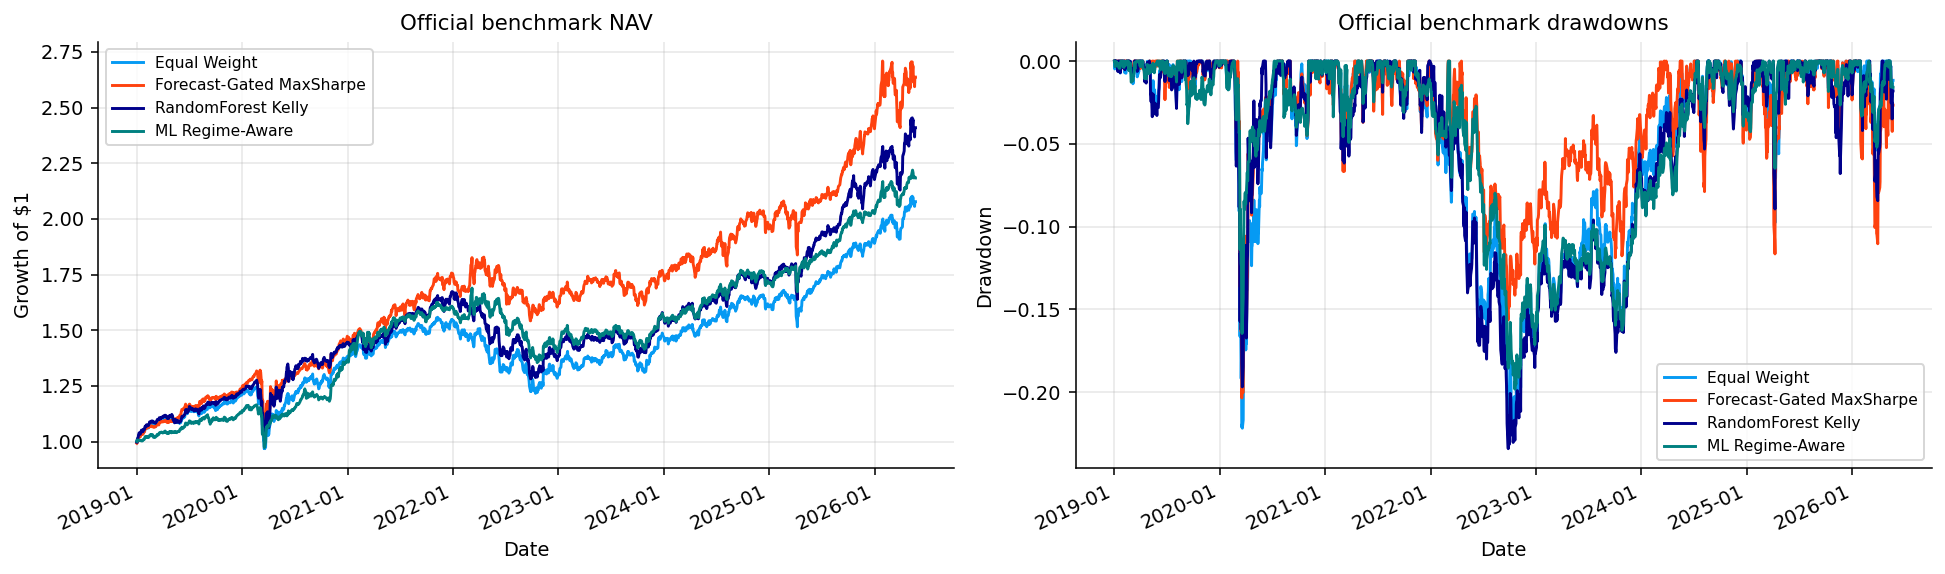

In [5]:
benchmark_nav_backtests = run_many_weights_backtests(official_benchmark_weights, returns=r_d.loc[pd.Timestamp("2019-01-01"):, assets + [cash_ticker]], cost_bps=cost_bps, rf_daily=rf_daily, w_min=0.0, w_max=1.0, long_only=True, normalize=True, weight_timing="next_close")
benchmark_nav = pd.DataFrame({name: res.net_values for name, res in benchmark_nav_backtests.items()}).dropna(how="all")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
plot_strategy_nav(benchmark_nav, ax=axes[0], title="Official benchmark NAV")
plot_strategy_drawdowns(benchmark_nav, ax=axes[1], title="Official benchmark drawdowns")
plt.tight_layout()
plt.show()


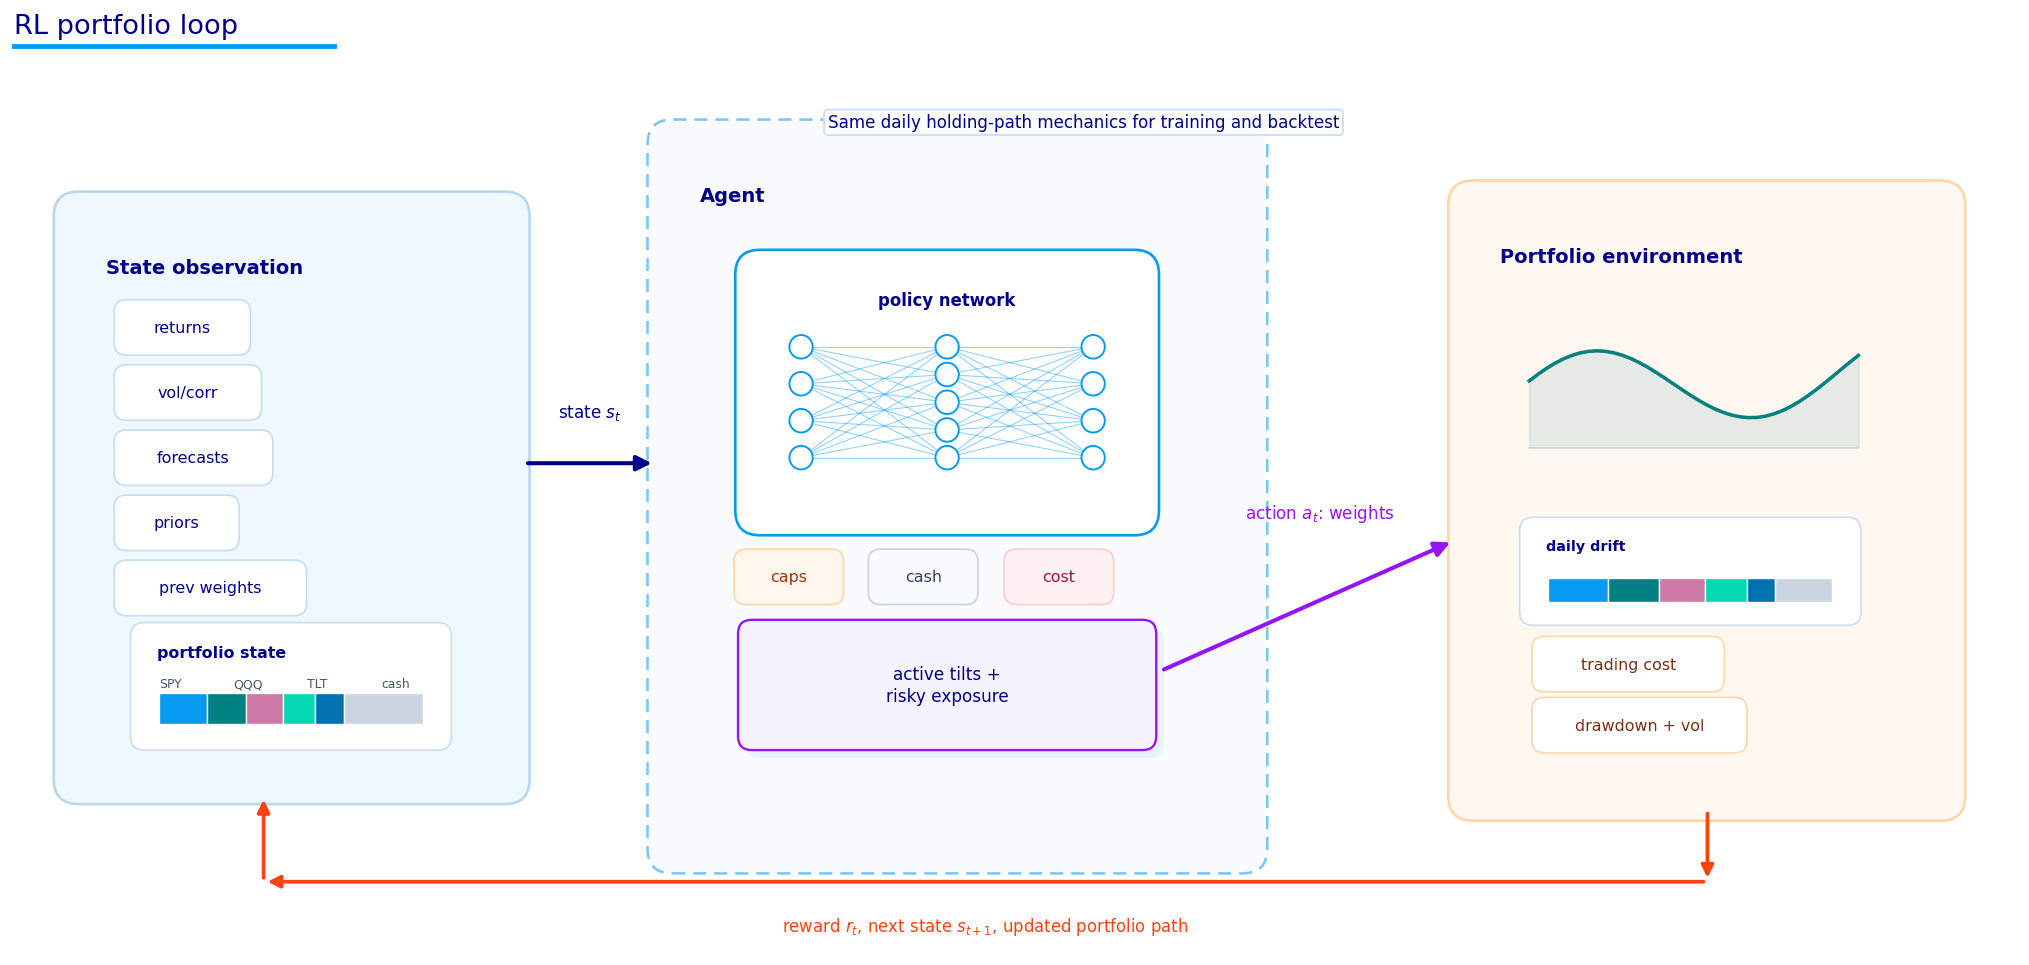

In [3]:
from quantfinlab.plotting.diagrams import agent_environment_loop_diagram
fig, ax = agent_environment_loop_diagram()
plt.show()


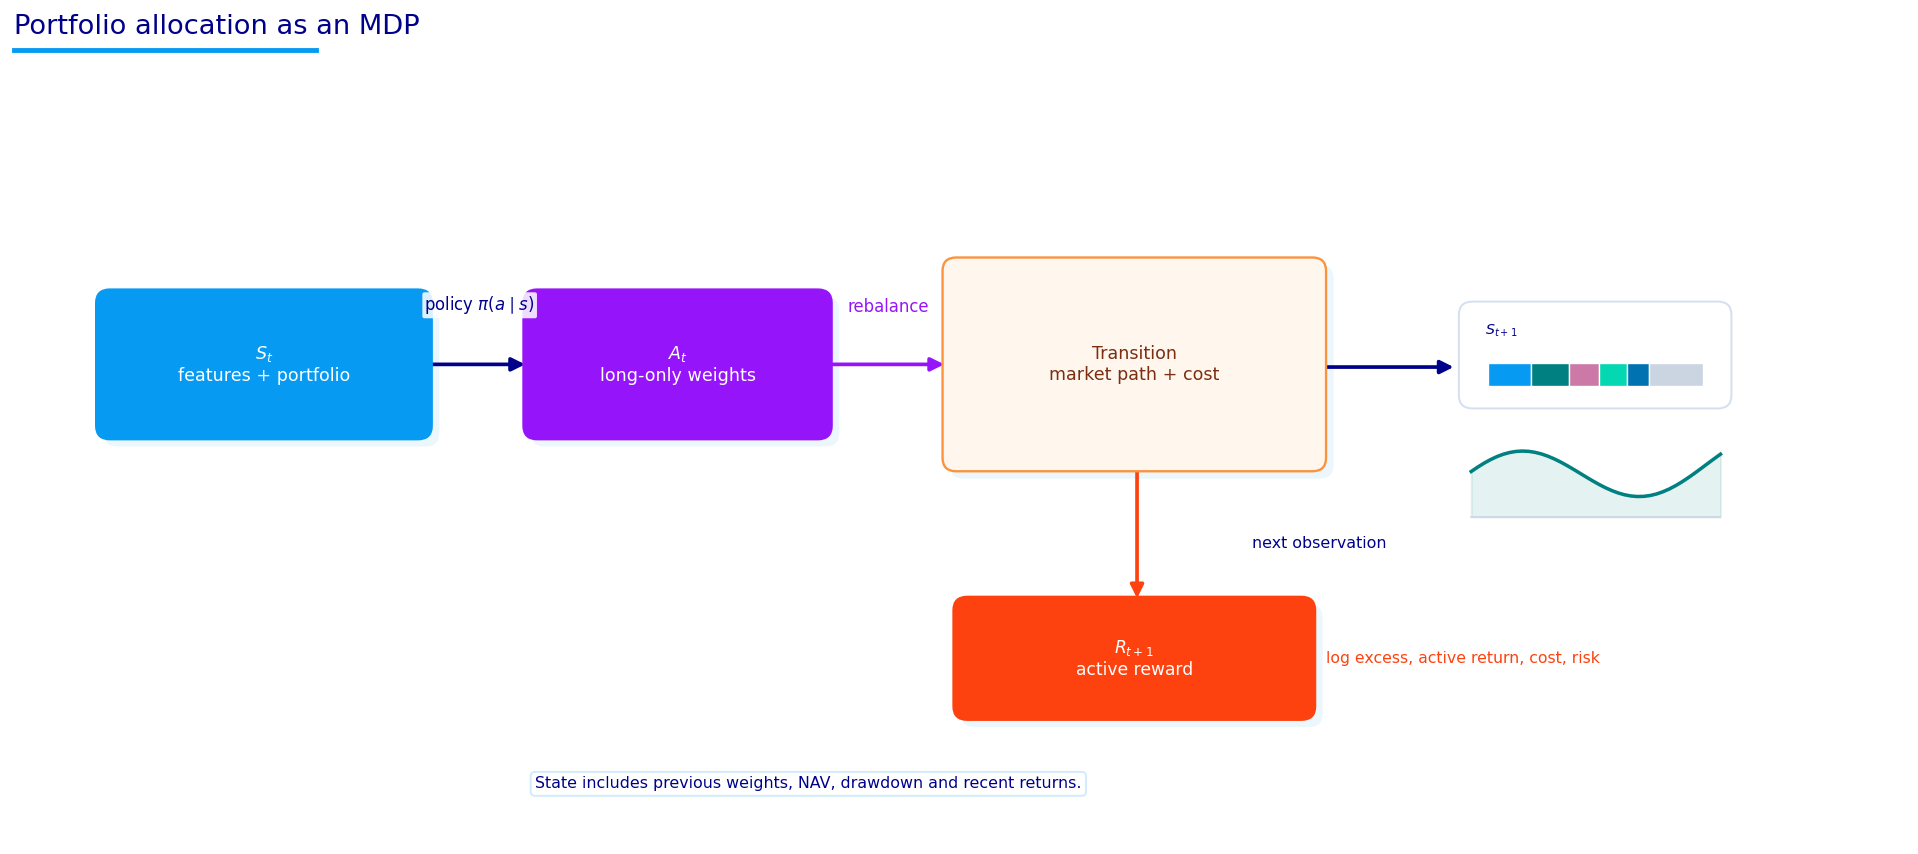

In [3]:
from quantfinlab.plotting.diagrams import mdp_diagram
fig, ax = mdp_diagram()
plt.show()


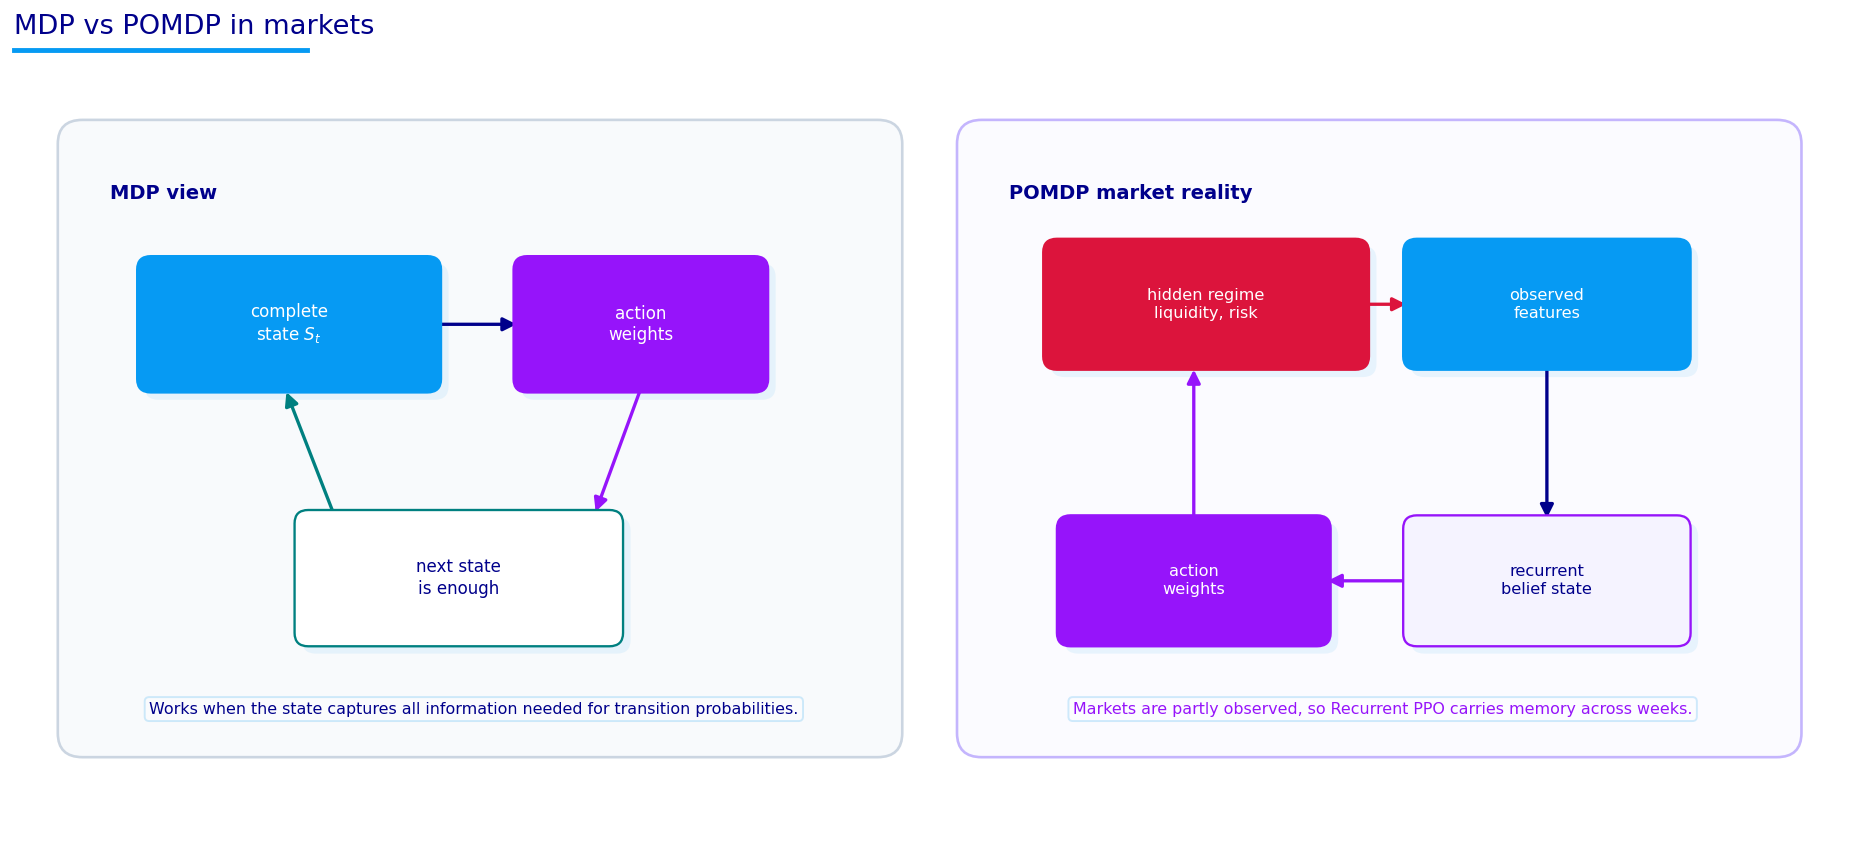

In [4]:
from quantfinlab.plotting.diagrams import mdp_pomdp_diagram
fig, ax = mdp_pomdp_diagram()
plt.show()


In [9]:
asset_x = build_asset_feature_block(close, volume, r_d, assets=assets, rf_daily=rf_daily)
asset_x = asset_x.merge(
    forecast_x[["date", "asset", "tcn_alpha", "tcn_rank", "tcn_confidence", "z_blend_rank", "z_blend_volscaled"]],
    on=["date", "asset"],
    how="left",
)
asset_feature_cols = [
    c for c in asset_x.columns
    if c not in {"date", "asset"} and pd.api.types.is_numeric_dtype(asset_x[c])
]
asset_coverage_by_date = asset_x.groupby("date")[asset_feature_cols].apply(lambda frame: frame.notna().mean().mean())
asset_count_by_date = asset_x.groupby("date")["asset"].nunique()
complete_asset_dates = asset_coverage_by_date.index[
    asset_coverage_by_date.ge(1.0) & asset_count_by_date.ge(len(assets))
]
state_ready_start = pd.Timestamp(complete_asset_dates.min()) if len(complete_asset_dates) else pd.Timestamp(asset_x["date"].min())
asset_train_mask = pd.to_datetime(asset_x["date"]) <= pd.Timestamp("2018-12-31")
asset_feature_fill_values = asset_x.loc[asset_train_mask, asset_feature_cols].median().replace([np.inf, -np.inf], np.nan).fillna(0.0)
asset_feature_fill_by_asset = (
    asset_x.loc[asset_train_mask, ["asset"] + asset_feature_cols]
    .groupby("asset", sort=False)
    .median(numeric_only=True)
    .replace([np.inf, -np.inf], np.nan)
)
display(pd.Series({
    "raw_first_date": pd.Timestamp(asset_x["date"].min()),
    "first_complete_asset_feature_date": state_ready_start,
    "raw_rows": len(asset_x),
    "feature_count": len(asset_feature_cols),
}).to_frame("value"))
display(asset_coverage_by_date.loc[:state_ready_start].tail(5).rename("raw_feature_coverage").to_frame().round(4))
display(asset_x.loc[pd.to_datetime(asset_x["date"]).ge(state_ready_start)].head())
print(asset_x.shape)


,value
raw_first_date,2007-04-11 00:00:00
first_complete_asset_feature_date,2008-04-04 00:00:00
raw_rows,58764
feature_count,49


,raw_feature_coverage
date,
2008-03-31,0.9592
2008-04-01,0.9592
2008-04-02,0.9592
2008-04-03,0.9592
2008-04-04,1.0000


,date,asset,r_1,r_5,r_21,r_63,r_126,skip_r_21_252,vol_21,vol_63,...,group_rel_vol_63,xs_z_trend_consistency,group_rel_trend_consistency,xs_z_resid_mom_63_spy,group_rel_resid_mom_63_spy,tcn_alpha,tcn_rank,tcn_confidence,z_blend_rank,z_blend_volscaled
252,2008-04-04,SPY,-0.001095,0.040909,0.027928,-0.026483,-0.112622,-0.057345,0.296537,0.230873,...,-0.034378,-0.768350,0.0,-0.597543,0.001484,-0.258730,-0.416667,0.555556,-0.416667,-0.416667
253,2008-04-07,SPY,0.000512,0.037811,0.050191,-0.025157,-0.107415,-0.080940,0.285447,0.230877,...,-0.034335,-1.069045,0.0,-0.626282,0.002932,-0.285169,-0.416667,0.555556,-0.416667,-0.416667
254,2008-04-08,SPY,-0.001023,0.001537,0.060036,-0.010170,-0.116647,-0.094538,0.281999,0.228628,...,-0.032088,-0.811503,0.0,-0.563776,-0.002008,-0.242561,-0.416667,0.555556,-0.416667,-0.416667
255,2008-04-09,SPY,-0.007235,-0.006364,0.066426,-0.027552,-0.121579,-0.114881,0.278447,0.228047,...,-0.031945,-1.192079,0.0,-0.531544,0.004495,-0.230837,-0.416667,0.555556,-0.416667,-0.416667
256,2008-04-10,SPY,0.001398,-0.007443,0.030870,-0.032533,-0.116107,-0.085503,0.251723,0.227646,...,-0.032599,-1.193166,0.0,-0.566011,-0.002142,-0.201631,-0.416667,0.555556,-0.416667,-0.416667


(58764, 51)


In [10]:
context_x = build_cross_asset_feature_block(close, r_d, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
fci_x = build_fci_feature_block(macro_factors, nfci, index=close.index)
regime_x = regime_probability_features(
    close,
    r_d,
    assets=assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="LogisticRegression",
    horizon=21,
    rebalance_dates=decision_dates,
    output="features",
    n_jobs=4,
)
global_x = pd.concat([context_x, fci_x, regime_x, vix_x], axis=1)
global_x = global_x.loc[:, ~global_x.columns.duplicated()].sort_index()
display(global_x.tail())
print(global_x.shape)


,breadth_21,breadth_63,dispersion_21,dispersion_63,rolling_avg_corr_63,rolling_avg_corr_126,spy_r_63,qqq_spy_63,hyg_lqd_63,hyg_lqd_change_63,...,nfci_credit,nfci_leverage,nfci_nonfinancial_leverage,p_risk_on,p_neutral,p_defensive,regime_confidence,vix_z_20,vix_ma_ratio_63,vix_pct_252
date,,,,,,,,,,,,,,,,,,,,,
2026-05-18,0.416667,0.500000,0.050265,0.113426,0.462031,0.412785,0.084671,0.090733,0.024188,0.024720,...,-0.019,0.234,-0.413,NaN,NaN,NaN,NaN,-0.234984,0.833347,0.595238
2026-05-19,0.333333,0.500000,0.050454,0.109621,0.464932,0.415888,0.072045,0.087457,0.024504,0.022552,...,-0.019,0.234,-0.413,NaN,NaN,NaN,NaN,0.185565,0.845550,0.642857
2026-05-20,0.583333,0.583333,0.040691,0.100836,0.469921,0.419444,0.085911,0.097328,0.023796,0.022708,...,-0.019,0.234,-0.413,NaN,NaN,NaN,NaN,-0.629576,0.818218,0.547619
2026-05-21,0.583333,0.583333,0.036407,0.099422,0.470451,0.421966,0.078114,0.094746,0.022265,0.017566,...,-0.019,0.234,-0.413,NaN,NaN,NaN,NaN,-1.585693,0.787682,0.414683
2026-05-22,0.583333,0.583333,0.036491,0.104557,0.478578,0.422080,0.089237,0.098055,0.024925,0.022817,...,-0.019,0.234,-0.413,0.300862,0.267547,0.431592,0.431592,-1.530646,0.787394,0.396825


(4897, 38)


In [11]:
def align_weight_frame(weights, target_dates, columns, fallback_equal=False):
    dates = pd.DatetimeIndex(target_dates).sort_values().unique()
    W = pd.DataFrame(weights).copy()
    if W.empty:
        base = pd.DataFrame(0.0, index=dates, columns=columns)
        if fallback_equal:
            base[assets] = 1.0 / len(assets)
        return base
    W.index = pd.to_datetime(W.index)
    W = W.sort_index().reindex(columns=columns)
    W = W.reindex(W.index.union(dates)).sort_index().ffill().reindex(dates).fillna(0.0)
    zero = W.sum(axis=1).abs() <= 1e-12
    if bool(zero.any()) and fallback_equal:
        W.loc[zero, assets] = 1.0 / len(assets)
    row_sum = W.sum(axis=1).replace(0.0, np.nan)
    return W.div(row_sum, axis=0).fillna(0.0)

def period_daily_windows(returns, decision_dates, columns):
    R = returns.reindex(columns=columns).fillna(0.0)
    idx = pd.DatetimeIndex(R.index)
    rows, windows = [], []
    for i, dt in enumerate(decision_dates):
        start = idx.searchsorted(pd.Timestamp(dt), side="right")
        if start >= len(idx):
            continue
        end = idx.searchsorted(pd.Timestamp(decision_dates[i + 1]), side="right") if i + 1 < len(decision_dates) else min(start + 5, len(idx))
        if end <= start:
            continue
        window = R.iloc[start:end].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        rows.append(((1.0 + window).prod() - 1.0).rename(pd.Timestamp(dt)))
        windows.append(window)
    return pd.DataFrame(rows).reindex(columns=columns).fillna(0.0), windows

state_dates = pd.DatetimeIndex([d for d in decision_dates if pd.Timestamp(d) >= state_ready_start])
state_columns = assets + [cash_ticker]
returns_next, daily_windows = period_daily_windows(r_d, state_dates, state_columns)
state_dates = returns_next.index
daily_windows_np = [w.reindex(columns=state_columns).fillna(0.0).to_numpy(dtype=float) for w in daily_windows]


In [12]:
feature_cols = [
    c for c in asset_x.columns
    if c not in {"date", "asset"} and pd.api.types.is_numeric_dtype(asset_x[c])
]

asset_blocks = []
asset_feature_names = []
for col in feature_cols:
    piv = asset_x.pivot_table(index="date", columns="asset", values=col, aggfunc="last")
    piv = piv.reindex(piv.index.union(state_dates)).sort_index().ffill().reindex(state_dates)
    piv = piv.reindex(columns=assets)
    fill_by_asset = asset_feature_fill_by_asset[col].reindex(assets) if col in asset_feature_fill_by_asset.columns else pd.Series(np.nan, index=assets)
    fill_by_asset = fill_by_asset.fillna(float(asset_feature_fill_values.get(col, 0.0)))
    asset_blocks.append(piv.fillna(fill_by_asset).fillna(0.0))
    asset_feature_names.append(col)
asset_blocks.append(pd.DataFrame(0.0, index=state_dates, columns=assets))
asset_feature_names.append("previous_weight")

asset_state = np.stack([b.to_numpy(dtype=np.float32) for b in asset_blocks], axis=2)
global_state_frame = global_x.reindex(global_x.index.union(state_dates)).sort_index().ffill().reindex(state_dates)
global_state_frame = global_state_frame.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
global_state = global_state_frame.to_numpy(dtype=np.float32)
shape_table = pd.DataFrame({
    "shape": [
        asset_state.shape,
        global_state.shape,
        returns_next.shape,
    ]
}, index=["asset_state", "global_state", "returns_next"])
display(shape_table)


,shape
asset_state,"(946, 12, 50)"
global_state,"(946, 38)"
returns_next,"(946, 13)"


In [13]:
diagnostics = pd.DataFrame({
    "missing_share": [
        float(np.isnan(asset_state).mean()),
        float(np.isnan(global_state).mean()),
        float(returns_next.isna().mean().mean()),
    ],
    "max_abs": [
        float(np.nanmax(np.abs(asset_state))),
        float(np.nanmax(np.abs(global_state))),
        float(np.nanmax(np.abs(returns_next.to_numpy()))),
    ],
}, index=["asset_state", "global_state", "returns_next"])
display(diagnostics.round(4))
print(state_dates.min().date(), state_dates.max().date(), len(state_dates))


,missing_share,max_abs
asset_state,0.0,7.1312
global_state,0.0,3.9612
returns_next,0.0,0.2830


2008-04-04 2026-05-15 946


In [14]:
def action_to_weights(raw_action, min_exposure=0.55, max_exposure=1.00, max_weight=0.35, active_scale=0.35):
    if torch.is_tensor(raw_action):
        logits = raw_action[..., :-1]
        exposure = min_exposure + (max_exposure - min_exposure) * torch.sigmoid(raw_action[..., -1])
        risky = torch.softmax(logits, dim=-1) * exposure.unsqueeze(-1)
        for _ in range(12):
            capped = risky.clamp(max=max_weight)
            excess = (risky - capped).clamp_min(0.0).sum(dim=-1, keepdim=True)
            room = (max_weight - capped).clamp_min(0.0)
            risky = capped + excess * room / room.sum(dim=-1, keepdim=True).clamp_min(1e-8)
            if not bool((risky > max_weight + 1e-7).any()):
                break
        cash = 1.0 - risky.sum(dim=-1, keepdim=True).clamp(0.0, 1.0)
        return torch.cat([risky, cash], dim=-1)
    raw = np.asarray(raw_action, dtype=float)
    logits = raw[..., :-1]
    exposure = min_exposure + (max_exposure - min_exposure) / (1.0 + np.exp(-raw[..., -1]))
    shifted = logits - np.max(logits, axis=-1, keepdims=True)
    soft = np.exp(shifted) / np.exp(shifted).sum(axis=-1, keepdims=True)
    risky = soft * np.expand_dims(exposure, axis=-1)
    for _ in range(20):
        capped = np.minimum(risky, max_weight)
        excess = np.maximum(risky - capped, 0.0).sum(axis=-1, keepdims=True)
        room = np.maximum(max_weight - capped, 0.0)
        risky = capped + excess * room / np.maximum(room.sum(axis=-1, keepdims=True), 1e-12)
        if not np.any(risky > max_weight + 1e-10):
            break
    cash = 1.0 - risky.sum(axis=-1, keepdims=True)
    return np.concatenate([risky, cash], axis=-1)

display(pd.Series(action_to_weights(np.zeros(len(assets) + 1)), index=state_columns).round(4).to_frame("weight"))


,weight
SPY,0.0646
QQQ,0.0646
IWM,0.0646
EFA,0.0646
EEM,0.0646
VNQ,0.0646
DBC,0.0646
GLD,0.0646
IEF,0.0646
TLT,0.0646


In [15]:
def portfolio_turnover(w_new, w_prev):
    new = np.asarray(w_new, dtype=float)
    prev = np.asarray(w_prev, dtype=float)
    if prev.sum() > 1e-12:
        prev = prev / prev.sum()
    return 0.5 * float(np.abs(new - prev).sum())

def portfolio_step_return(w_new, r_next, w_prev=None, cost_bps=10.0):
    turnover = portfolio_turnover(w_new, w_prev) if w_prev is not None else 0.0
    cost = float(cost_bps) / 10000.0 * turnover
    gross = float(np.dot(np.asarray(w_new), np.asarray(r_next)))
    return gross - cost, turnover, cost

def portfolio_step_path_return(w_new, daily_window, w_prev=None, cost_bps=10.0):
    w = np.asarray(w_new, dtype=float).reshape(-1)
    if w.sum() > 1e-12:
        w = w / w.sum()
    prev = np.zeros_like(w) if w_prev is None else np.asarray(w_prev, dtype=float).reshape(-1)
    if prev.sum() > 1e-12:
        prev = prev / prev.sum()
    turnover = 0.5 * float(np.abs(w - prev).sum())
    cost = float(cost_bps) / 10000.0 * turnover
    net = max(1.0 - cost, 1e-12)
    drift_w = w.copy()
    daily_net_returns, nav_path = [], []
    prev_net = 1.0
    R = daily_window if isinstance(daily_window, np.ndarray) else pd.DataFrame(daily_window).reindex(columns=state_columns).fillna(0.0).to_numpy(dtype=float)
    for i, row in enumerate(R):
        port_ret = float(np.dot(drift_w, row))
        net *= 1.0 + port_ret
        daily_net_returns.append(net / prev_net - 1.0 if i == 0 else port_ret)
        nav_path.append(net)
        grossed = drift_w * (1.0 + row)
        gross_sum = float(grossed.sum())
        drift_w = grossed / gross_sum if gross_sum > 0 and np.isfinite(gross_sum) else np.zeros_like(drift_w)
        prev_net = net
    return float(net - 1.0), turnover, cost, drift_w, np.asarray(daily_net_returns, dtype=float), np.asarray(nav_path, dtype=float)

print(portfolio_step_path_return(np.r_[np.repeat(1/len(assets), len(assets)), 0.0], daily_windows[0], np.zeros(len(state_columns)), cost_bps)[:3])


(-0.011906387299702503, 0.5, 0.0005)


In [16]:
class DifferentialSharpe:
    def __init__(self, eta=0.01):
        self.eta = float(eta)
        self.A = 0.0
        self.B = 0.0
        self.initialized = False

    def update(self, r):
        r = float(r)
        if not self.initialized:
            self.A, self.B, self.initialized = r, r * r, True
            return 0.0
        delta_a = r - self.A
        delta_b = r * r - self.B
        denom = max((self.B - self.A * self.A) ** 1.5, 1e-8)
        dsr = (self.B * delta_a - 0.5 * self.A * delta_b) / denom
        self.A += self.eta * delta_a
        self.B += self.eta * delta_b
        return float(np.clip(dsr, -10.0, 10.0))

def reward_components(portfolio_return, dsr_value, turnover, cost, weights, realized_vol, drawdown, settings, decorr=0.0):
    primary = settings["dsr_scale"] * dsr_value
    dd_excess = max(0.0, settings["drawdown_floor"] - drawdown)
    dd_pen = settings["lambda_drawdown"] * 100.0 * dd_excess ** 2
    vol_excess = max(0.0, realized_vol - settings["target_vol"])
    vol_pen = settings["lambda_vol"] * 100.0 * vol_excess ** 2
    cost_pen = settings["lambda_cost"] * settings["cost_bps"] * turnover
    hhi = float(np.square(np.clip(weights[:-1], 0.0, 1.0)).sum())
    conc_pen = settings["lambda_conc"] * max(0.0, hhi - settings["hhi_target"])
    cash = float(weights[-1])
    cash_pen = settings["lambda_cash"] * max(0.0, cash - settings["cash_cap"])
    decorr_pen = settings["lambda_decorr"] * 100.0 * decorr ** 2
    reward = primary - dd_pen - vol_pen - cost_pen - conc_pen - cash_pen - decorr_pen
    return {
        "reward": float(reward),
        "dsr": float(dsr_value),
        "primary_reward": float(primary),
        "portfolio_return": float(portfolio_return),
        "turnover": float(turnover),
        "cost": float(cost),
        "drawdown": float(drawdown),
        "drawdown_penalty": float(dd_pen),
        "vol_excess": float(vol_excess),
        "vol_penalty": float(vol_pen),
        "cost_penalty": float(cost_pen),
        "concentration_penalty": float(conc_pen),
        "cash": float(cash),
        "cash_penalty": float(cash_pen),
        "decorr_penalty": float(decorr_pen),
        "hhi": float(hhi),
    }

reward_settings = {
    "rf_daily": rf_daily,
    "cost_bps": cost_bps,
    "reward_mode": "dsr",
    "dsr_scale": 4.0,
    "dsr_eta": 0.01,
    "target_vol": 0.18,
    "drawdown_floor": -0.12,
    "lambda_cost": 0.10,
    "lambda_vol": 0.25,
    "lambda_drawdown": 1.5,
    "lambda_conc": 0.10,
    "hhi_target": 0.30,
    "cash_cap": 0.20,
    "lambda_cash": 0.5,
    "decorr_cap": 0.88,
    "lambda_decorr": 0.5,
    "min_exposure": 0.55,
    "max_exposure": 1.00,
    "max_weight": 0.35,
    "sac_gamma": 0.97,
}
display(pd.Series(reward_settings).to_frame("value"))


,value
rf_daily,0.000156
cost_bps,10.0
reward_mode,dsr
dsr_scale,4.0
dsr_eta,0.01
target_vol,0.18
drawdown_floor,-0.12
lambda_cost,0.1
lambda_vol,0.25
lambda_drawdown,1.5


In [17]:
def portfolio_state_vector(w_prev, previous_turnover=0.0, current_drawdown=0.0, rolling_portfolio_vol=0.0, recent_portfolio_return=0.0):
    w_prev = np.asarray(w_prev, dtype=np.float32)
    return np.r_[w_prev[:-1], w_prev[:-1].sum(), previous_turnover, current_drawdown, rolling_portfolio_vol, recent_portfolio_return].astype(np.float32)

def environment_step(t, raw_action, w_prev, nav, peak, daily_returns_hist, ew_daily_hist, dsr_state, settings):
    weights = action_to_weights(raw_action, settings["min_exposure"], settings["max_exposure"], settings["max_weight"])
    port_ret, turnover, cost, w_end, daily_net, nav_path = portfolio_step_path_return(weights, daily_windows_np[t], w_prev, settings["cost_bps"])
    equal_daily = daily_windows_np[t][:, :len(assets)].mean(axis=1)
    nav_path_abs = nav * nav_path
    nav_next = float(nav_path_abs[-1]) if len(nav_path_abs) else nav * (1.0 + port_ret)
    peak_next = max(peak, float(np.nanmax(nav_path_abs)) if len(nav_path_abs) else nav_next)
    realized_vol = np.std([*daily_returns_hist[-63:], *daily_net], ddof=1) * np.sqrt(252.0) if len(daily_returns_hist) + len(daily_net) > 20 else 0.0
    dsr_value = 0.0
    for daily_r in daily_net:
        dsr_value = dsr_state.update(float(daily_r))
    decorr = 0.0
    hist_p = [*daily_returns_hist[-63:], *daily_net]
    hist_e = [*ew_daily_hist[-63:], *equal_daily]
    if len(hist_p) > 20 and len(hist_p) == len(hist_e):
        sp, se = np.std(hist_p), np.std(hist_e)
        if sp > 1e-9 and se > 1e-9:
            decorr = max(0.0, float(np.corrcoef(hist_p, hist_e)[0, 1]) - settings["decorr_cap"])
    comps = reward_components(port_ret, dsr_value, turnover, cost, weights, realized_vol, nav_next / peak_next - 1.0, settings, decorr=decorr)
    return weights, port_ret, turnover, cost, w_end, nav_next, peak_next, comps, daily_net, equal_daily


In [18]:
def inputs_for_step(t, w_prev, nav, peak, returns_hist, previous_turnover, daily_returns_hist=None):
    ax = asset_state[t].copy()
    if "previous_weight" in asset_feature_names:
        ax[:, asset_feature_names.index("previous_weight")] = w_prev[:-1]
    daily_returns_hist = [] if daily_returns_hist is None else daily_returns_hist
    rolling_vol = np.std(daily_returns_hist[-63:], ddof=1) * np.sqrt(252.0) if len(daily_returns_hist) > 20 else (np.std(returns_hist[-13:], ddof=1) * np.sqrt(52.0) if len(returns_hist) > 2 else 0.0)
    px = portfolio_state_vector(
        w_prev,
        previous_turnover=previous_turnover,
        current_drawdown=nav / peak - 1.0,
        rolling_portfolio_vol=rolling_vol,
        recent_portfolio_return=returns_hist[-1] if returns_hist else 0.0,
    )
    return ax.astype(np.float32), global_state[t].astype(np.float32), px.astype(np.float32)

def evaluate_weight_frame(weights, settings=reward_settings):
    W = align_weight_frame(weights, state_dates, state_columns, fallback_equal=True).reindex(columns=state_columns).fillna(0.0)
    w_prev = np.zeros(len(state_columns), dtype=float)
    nav = peak = 1.0
    returns_hist, daily_returns_hist, rows = [], [], []
    dsr_state = DifferentialSharpe(settings["dsr_eta"])
    for t, dt in enumerate(state_dates):
        w = W.iloc[t].values
        port_ret, turnover, cost, w_end, daily_net, _ = portfolio_step_path_return(w, daily_windows_np[t], w_prev, settings["cost_bps"])
        nav_next = nav * (1.0 + port_ret)
        peak_next = max(peak, nav_next)
        realized_vol = np.std([*daily_returns_hist[-63:], *daily_net], ddof=1) * np.sqrt(252.0) if len(daily_returns_hist) + len(daily_net) > 20 else 0.0
        dsr_value = 0.0
        for daily_r in daily_net:
            dsr_value = dsr_state.update(float(daily_r))
        comp = reward_components(port_ret, dsr_value, turnover, cost, w, realized_vol, nav_next / peak_next - 1.0, settings)
        rows.append({"date": dt, "return": port_ret, "nav": nav_next, "turnover": turnover, **comp})
        returns_hist.append(port_ret)
        daily_returns_hist.extend([float(x) for x in daily_net])
        w_prev, nav, peak = w_end, nav_next, peak_next
    return pd.DataFrame(rows).set_index("date")


In [19]:
env_sanity = evaluate_weight_frame(w_forecast_gated_ms)
sanity_weights = align_weight_frame(w_forecast_gated_ms, state_dates, state_columns, fallback_equal=True)
sanity_returns = r_d.loc[daily_windows[0].index[0]:daily_windows[-1].index[-1], state_columns]
bt_sanity = run_many_weights_backtests(
    {"Forecast-Gated MaxSharpe": sanity_weights},
    returns=sanity_returns,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=1.0,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)["Forecast-Gated MaxSharpe"]
env_total_return = float((1.0 + env_sanity["return"]).prod() - 1.0)
daily_total_return = float(bt_sanity.net_values.iloc[-1] - 1.0)
sanity_check = pd.Series({
    "env_path_total_return": env_total_return,
    "daily_backtest_total_return": daily_total_return,
    "absolute_total_return_gap": abs(env_total_return - daily_total_return),
    "env_reward_sum": env_sanity["reward"].sum(),
    "env_avg_turnover": env_sanity["turnover"].mean(),
})
display(sanity_check.round(4).to_frame("value"))
assert abs(env_total_return - daily_total_return) < 1e-6, "Environment daily path does not match run_weights_backtest."


,value
env_path_total_return,8.7463
daily_backtest_total_return,8.7463
absolute_total_return_gap,0.0000
env_reward_sum,-132.4665
env_avg_turnover,0.0893


In [20]:
reward_tables = {}
for name, weights in official_benchmark_weights.items():
    tbl = evaluate_weight_frame(weights)
    reward_tables[name] = tbl.mean(numeric_only=True)
reward_decomposition = pd.DataFrame(reward_tables).T
display(reward_decomposition[["reward", "dsr", "primary_reward", "turnover", "vol_penalty", "drawdown_penalty", "concentration_penalty", "cash_penalty"]].round(4))


,reward,dsr,primary_reward,turnover,vol_penalty,drawdown_penalty,concentration_penalty,cash_penalty
Equal Weight,-0.1627,0.0107,0.0430,0.0072,0.0382,0.1603,0.0000,0.0000
Forecast-Gated MaxSharpe,-0.1400,-0.0084,-0.0337,0.0893,0.0114,0.0044,0.0012,0.0000
RandomForest Kelly,-0.2677,0.0016,0.0064,0.0536,0.0089,0.0184,0.0000,0.1932
ML Regime-Aware,-0.1948,0.0096,0.0385,0.0507,0.0318,0.1508,0.0000,0.0000


In [21]:
train_period = ("2008-01-01", "2016-12-31")
valid_period = ("2017-01-01", "2018-12-31")
test_period = ("2019-01-01", "2026-12-31")

def period_indices(period):
    start, end = map(pd.Timestamp, period)
    return np.where((state_dates >= start) & (state_dates <= end))[0]

train_idx = period_indices(train_period)
valid_idx = period_indices(valid_period)
test_idx = period_indices(test_period)
display(pd.Series({"train": len(train_idx), "validation": len(valid_idx), "test": len(test_idx)}).to_frame("weeks"))


,weeks
train,457
validation,104
test,385


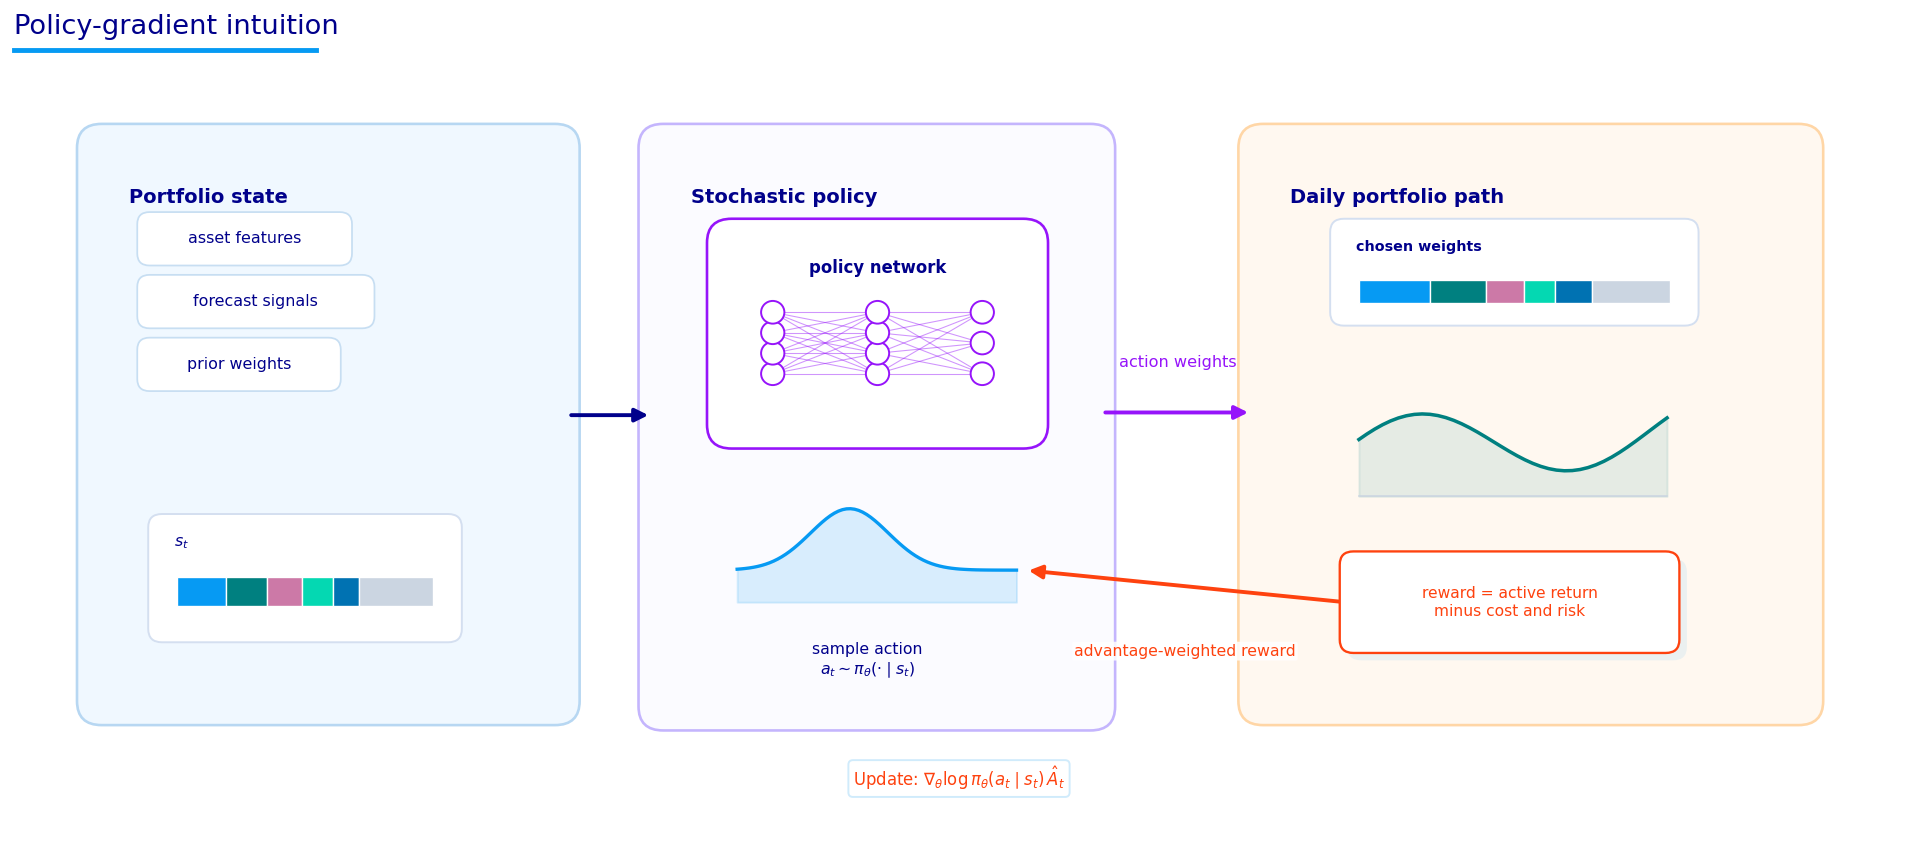

In [5]:
from quantfinlab.plotting.diagrams import policy_gradient_diagram
fig, ax = policy_gradient_diagram()
plt.show()


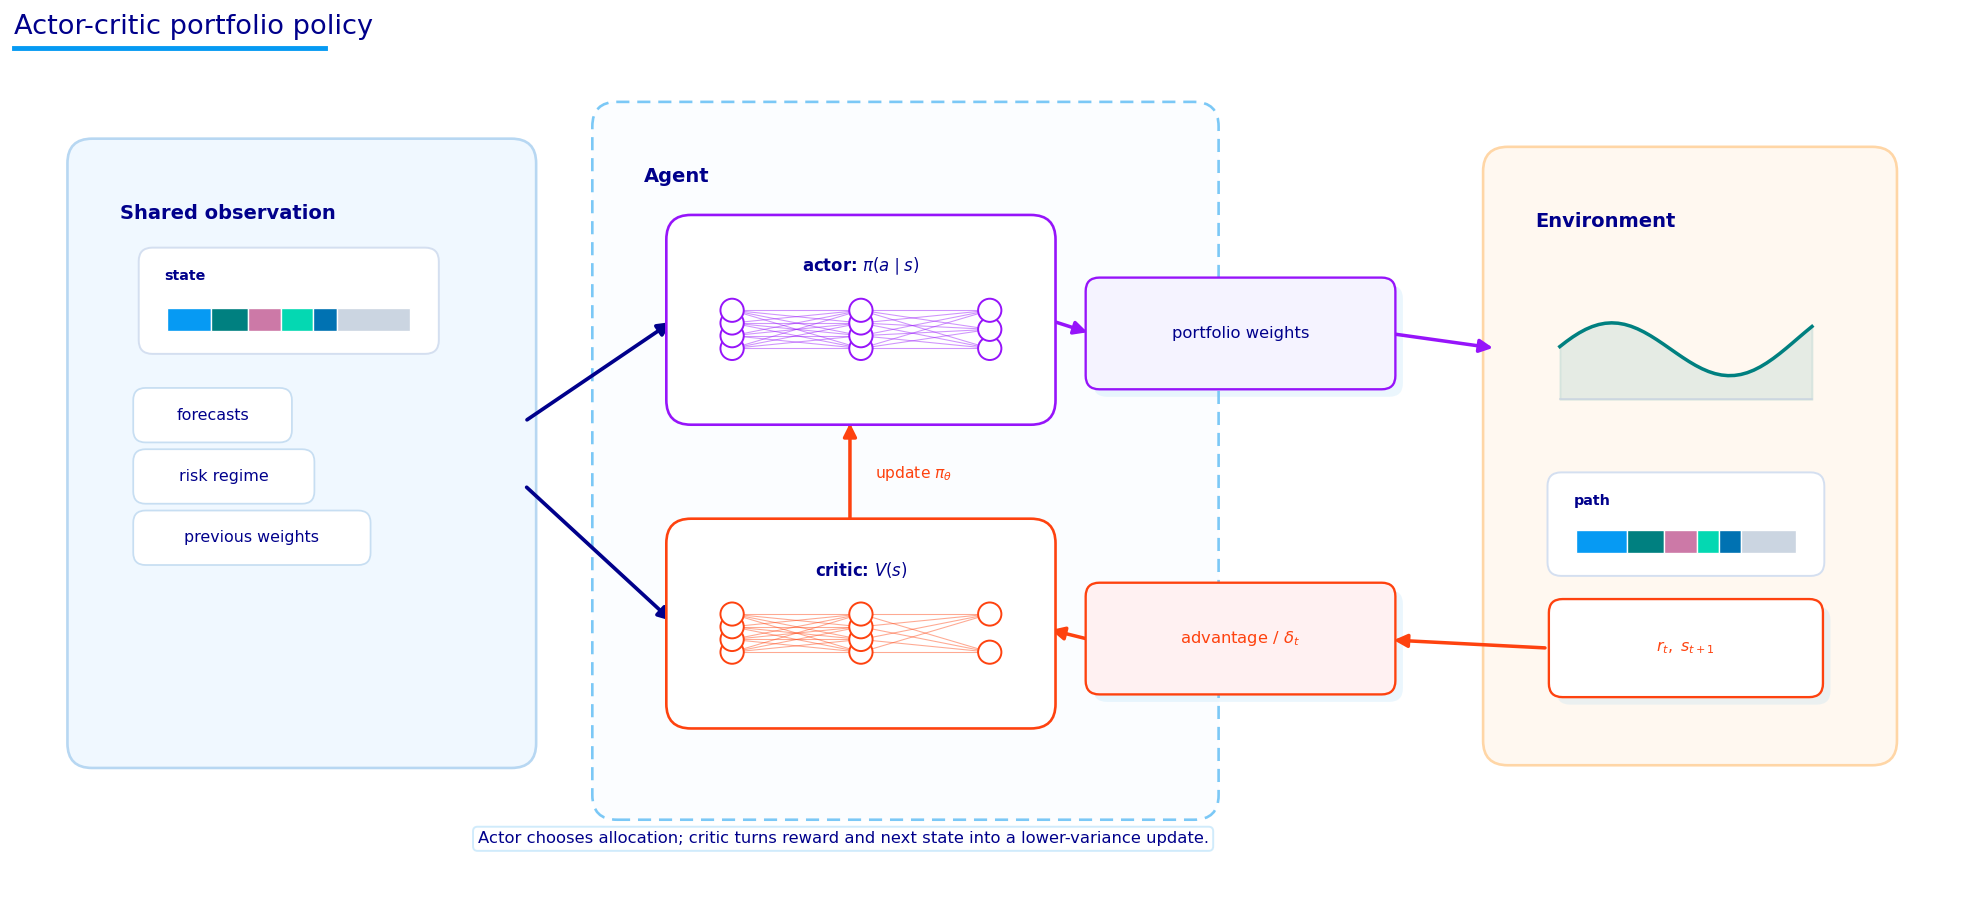

In [6]:
from quantfinlab.plotting.diagrams import actor_critic_diagram
fig, ax = actor_critic_diagram()
plt.show()


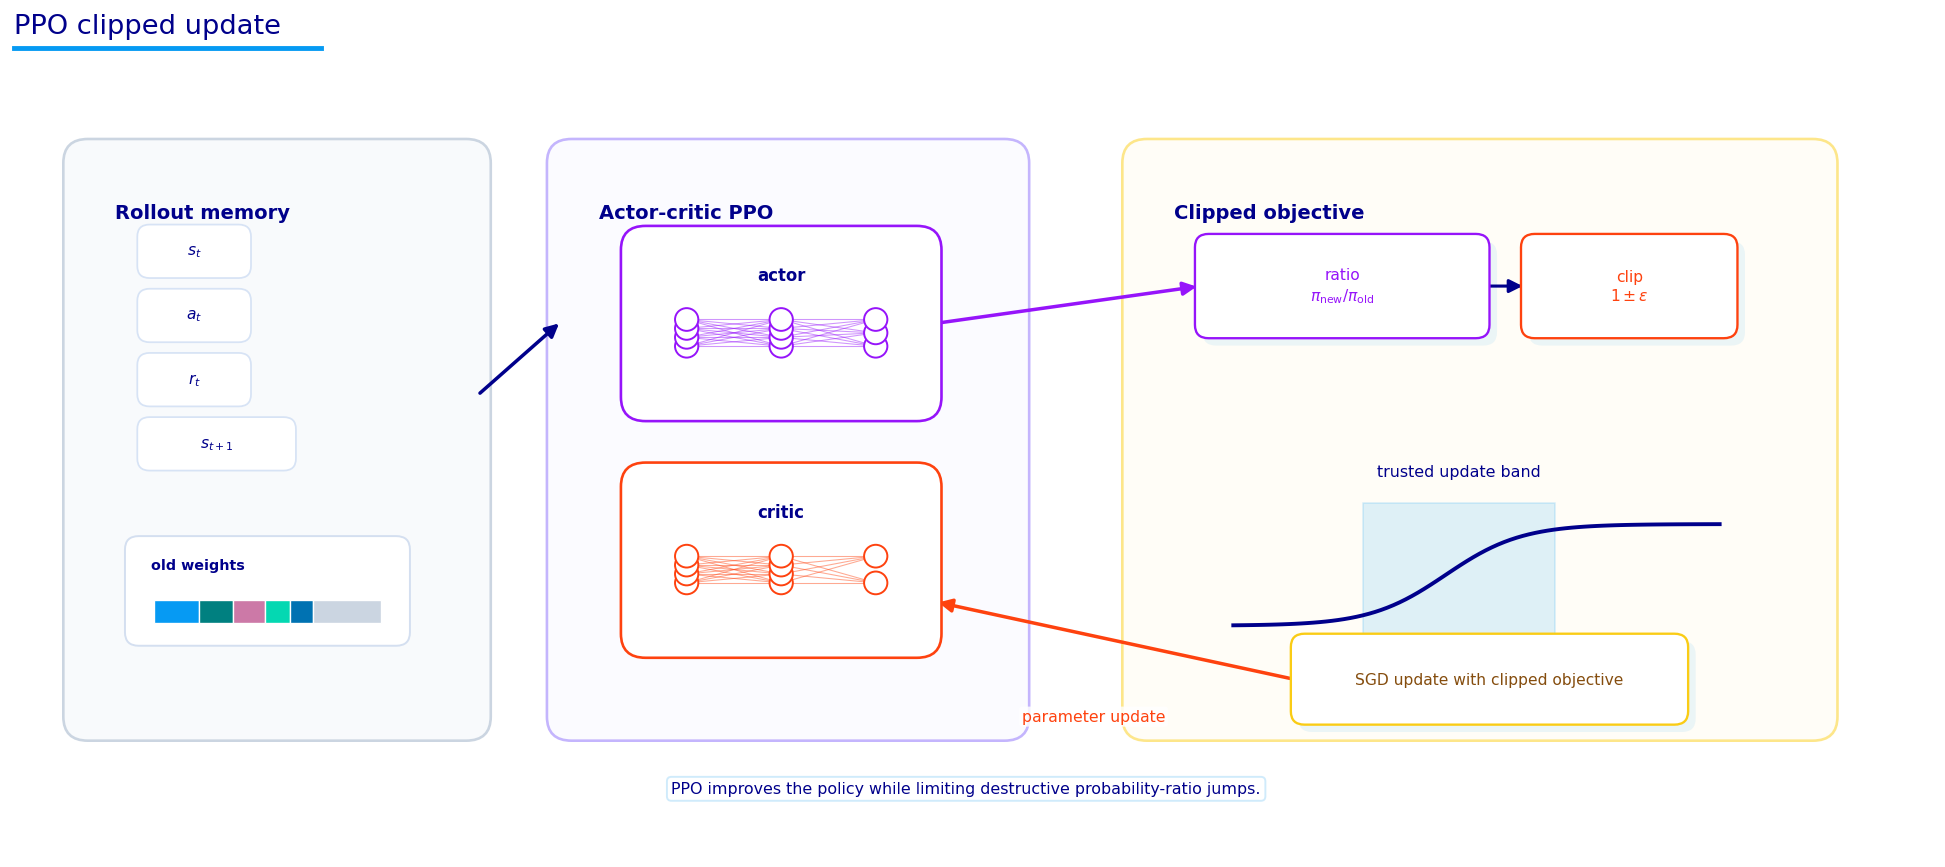

In [7]:
from quantfinlab.plotting.diagrams import ppo_diagram
fig, ax = ppo_diagram()
plt.show()


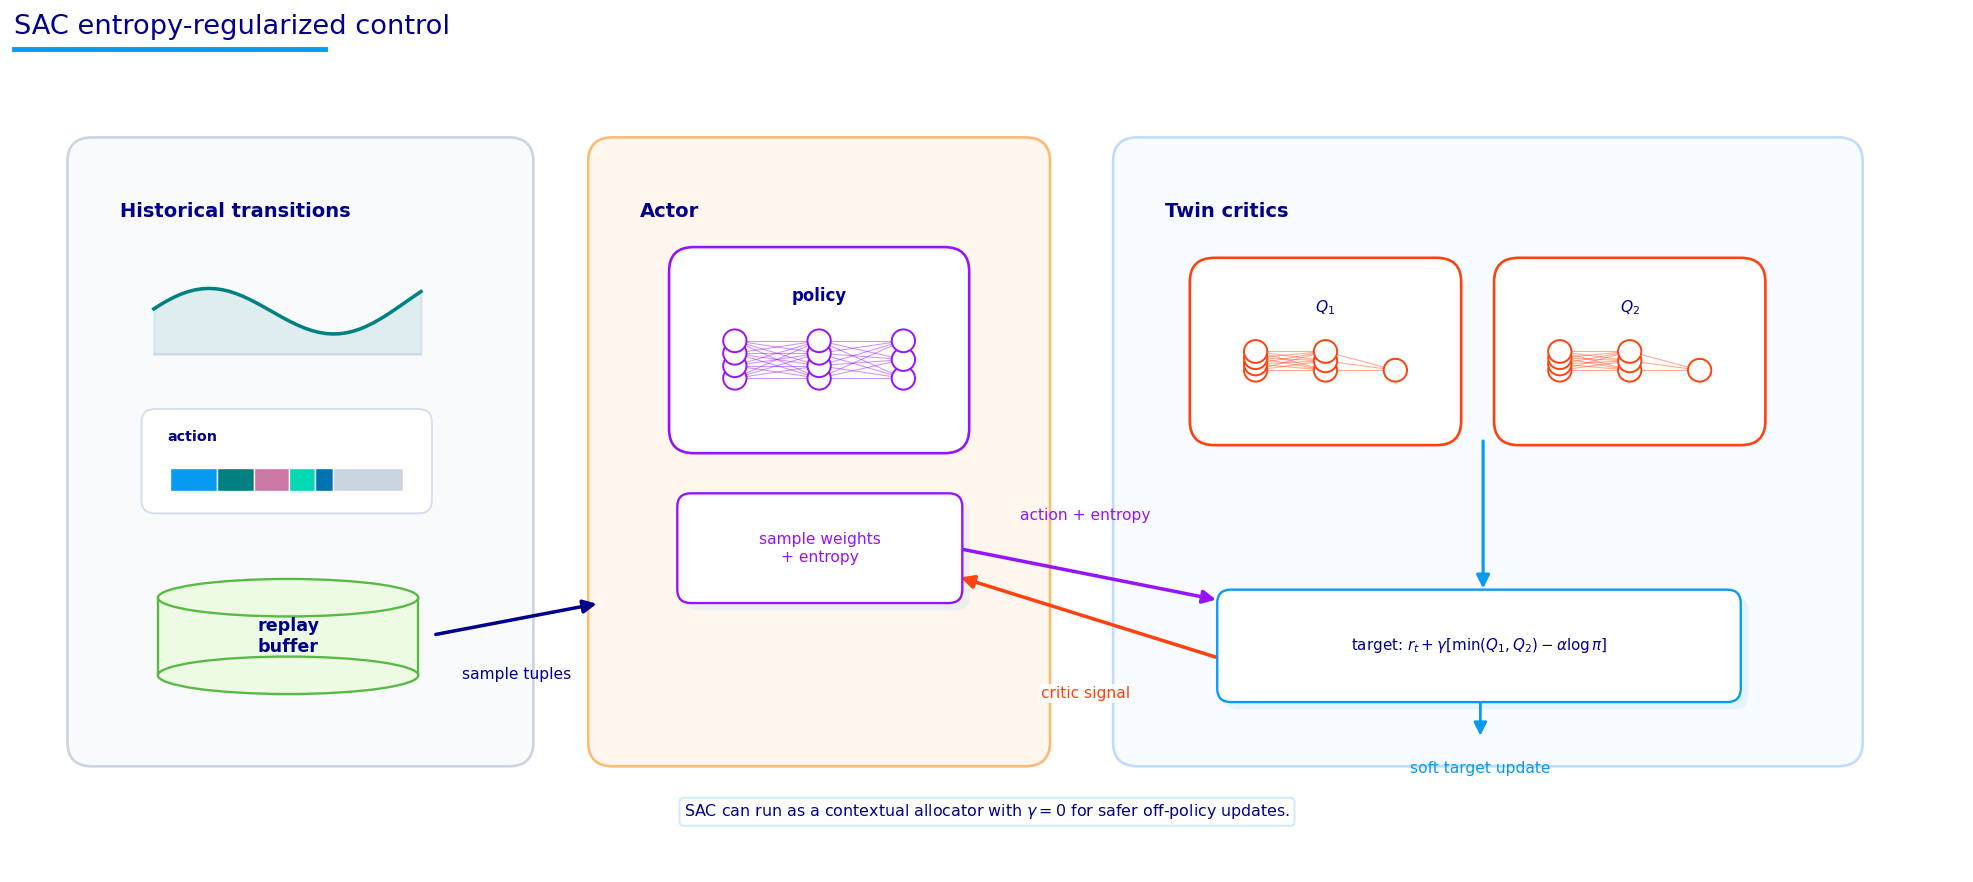

In [8]:
from quantfinlab.plotting.diagrams import sac_diagram
fig, ax = sac_diagram()
plt.show()


In [26]:
import torch.nn as nn
from torch.distributions import Normal

class CrossAssetEncoder(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, heads=4):
        super().__init__()
        self.n_assets = n_assets
        self.n_portfolio_features = n_assets + 5
        self.asset_encoder = nn.Sequential(nn.LayerNorm(n_asset_features), nn.Linear(n_asset_features, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU())
        self.attn = nn.MultiheadAttention(hidden_size, heads, batch_first=True)
        self.asset_norm = nn.LayerNorm(hidden_size)
        self.pool_score = nn.Linear(hidden_size, 1)
        self.global_encoder = nn.Sequential(nn.LayerNorm(n_global_features), nn.Linear(n_global_features, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU())
        self.port_encoder = nn.Sequential(nn.LayerNorm(self.n_portfolio_features), nn.Linear(self.n_portfolio_features, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU())
        self.output_dim = 3 * hidden_size
        self.asset_score_dim = 4 * hidden_size
        self.hidden_size = hidden_size
    def encode(self, ax, gx, px):
        a = self.asset_encoder(ax.float())
        attn, _ = self.attn(a, a, a, need_weights=False)
        h_asset = self.asset_norm(a + attn)
        pool_w = torch.softmax(self.pool_score(h_asset).squeeze(-1), dim=-1)
        context = (h_asset * pool_w.unsqueeze(-1)).sum(dim=1)
        global_h = self.global_encoder(gx.float())
        port_h = self.port_encoder(px.float())
        fused = torch.cat([context, global_h, port_h], dim=-1)
        return h_asset, context, global_h, port_h, fused
    def forward(self, ax, gx, px):
        return self.encode(ax, gx, px)[-1]

class PpoActorCritic(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, alpha_index=None):
        super().__init__()
        self.n_assets = n_assets
        self.alpha_index = alpha_index
        self.alpha_gain = nn.Parameter(torch.tensor(4.0)) if alpha_index is not None else None
        self.encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        self.score_head = nn.Sequential(nn.LayerNorm(self.encoder.asset_score_dim), nn.Linear(self.encoder.asset_score_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.exposure_head = nn.Sequential(nn.LayerNorm(self.encoder.output_dim), nn.Linear(self.encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.log_std = nn.Parameter(torch.full((n_assets + 1,), -0.65))
        self.value = nn.Sequential(nn.LayerNorm(self.encoder.output_dim), nn.Linear(self.encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
    def action_mean(self, ax, gx, px):
        h_asset, context, global_h, port_h, fused = self.encoder.encode(ax, gx, px)
        n = h_asset.shape[1]
        score_x = torch.cat([
            h_asset,
            context.unsqueeze(1).expand(-1, n, -1),
            global_h.unsqueeze(1).expand(-1, n, -1),
            port_h.unsqueeze(1).expand(-1, n, -1),
        ], dim=-1)
        risky_logits = self.score_head(score_x).squeeze(-1)
        if self.alpha_index is not None:
            risky_logits = risky_logits + self.alpha_gain * ax.float()[..., self.alpha_index]
        exposure_logit = self.exposure_head(fused).squeeze(-1)
        return torch.cat([risky_logits, exposure_logit.unsqueeze(-1)], dim=-1), fused
    def distribution(self, ax, gx, px):
        mean, z = self.action_mean(ax, gx, px)
        std = torch.exp(self.log_std).clamp(0.05, 2.0).expand_as(mean)
        return Normal(mean, std), self.value(z).squeeze(-1)
    def act(self, ax, gx, px, deterministic=False):
        dist, value = self.distribution(ax, gx, px)
        action = dist.mean if deterministic else dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        weights = action_to_weights(action, reward_settings["min_exposure"], reward_settings["max_exposure"], reward_settings["max_weight"])
        return action, log_prob, entropy, value, weights
    def evaluate_actions(self, ax, gx, px, action):
        dist, value = self.distribution(ax, gx, px)
        return dist.log_prob(action).sum(-1), dist.entropy().sum(-1), value


In [27]:
def collect_policy_rollout(model, indices, deterministic=False):
    model.to(device)
    w_prev = np.zeros(len(state_columns), dtype=float)
    nav = peak = 1.0
    prev_turnover = 0.0
    returns_hist, daily_returns_hist = [], []
    dsr_state = DifferentialSharpe(reward_settings["dsr_eta"])
    ew_daily_hist = []
    rows = {k: [] for k in ["asset", "global", "portfolio", "action", "log_prob", "entropy", "value", "reward", "return", "daily_returns", "weights", "date", "components"]}
    for t in indices:
        ax_np, gx_np, px_np = inputs_for_step(t, w_prev, nav, peak, returns_hist, prev_turnover, daily_returns_hist)
        ax_t = torch.tensor(ax_np[None], dtype=torch.float32, device=device)
        gx_t = torch.tensor(gx_np[None], dtype=torch.float32, device=device)
        px_t = torch.tensor(px_np[None], dtype=torch.float32, device=device)
        with torch.no_grad():
            action, logp, entropy, value, w_t = model.act(ax_t, gx_t, px_t, deterministic=deterministic)
        w_new, port_ret, turnover, cost, w_end, nav, peak, comps, daily_net, equal_daily = environment_step(t, action.detach().cpu().numpy().reshape(-1), w_prev, nav, peak, daily_returns_hist, ew_daily_hist, dsr_state, reward_settings)
        for key, val in [
            ("asset", ax_np), ("global", gx_np), ("portfolio", px_np), ("action", action.detach().cpu().numpy().reshape(-1)),
            ("log_prob", float(logp.detach().cpu())), ("entropy", float(entropy.detach().cpu())), ("value", float(value.detach().cpu())),
            ("reward", comps["reward"]), ("return", port_ret), ("daily_returns", daily_net), ("weights", w_new), ("date", state_dates[t]), ("components", comps)
        ]:
            rows[key].append(val)
        returns_hist.append(port_ret)
        daily_returns_hist.extend([float(x) for x in daily_net])
        ew_daily_hist.extend([float(x) for x in equal_daily])
        prev_turnover = turnover
        w_prev = w_end
    return rows

def gae(rewards, values, gamma=0.97, lam=0.90):
    rewards = np.asarray(rewards, dtype=np.float32)
    values = np.asarray(values, dtype=np.float32)
    adv = np.zeros_like(rewards)
    last = 0.0
    for i in range(len(rewards) - 1, -1, -1):
        next_value = values[i + 1] if i + 1 < len(values) else 0.0
        delta = rewards[i] + gamma * next_value - values[i]
        last = delta + gamma * lam * last
        adv[i] = last
    return adv, adv + values

def validation_stats_from_rollout(rows):
    if "daily_returns" in rows and rows["daily_returns"]:
        daily = np.concatenate([np.asarray(x, dtype=float).reshape(-1) for x in rows["daily_returns"]])
        r = pd.Series(daily)
        nav = (1.0 + r).cumprod()
        vol = r.std(ddof=1) * np.sqrt(252.0)
        sharpe = ((r - rf_daily).mean() / r.std(ddof=1) * np.sqrt(252.0)) if r.std(ddof=1) > 0 else np.nan
    else:
        r = pd.Series(rows["return"], index=pd.DatetimeIndex(rows["date"]))
        nav = (1 + r).cumprod()
        vol = r.std(ddof=1) * np.sqrt(52.0)
        rf_week = (1.0 + rf_daily) ** 5 - 1.0
        sharpe = ((r - rf_week).mean() / r.std(ddof=1) * np.sqrt(52.0)) if r.std(ddof=1) > 0 else np.nan
    return {"total_reward": float(np.sum(rows["reward"])), "mean_reward": float(np.mean(rows["reward"])), "return": float(nav.iloc[-1] - 1), "vol": float(vol), "sharpe": float(sharpe), "max_drawdown": float((nav / nav.cummax() - 1).min()), "avg_exposure": float(np.mean([w[:-1].sum() for w in rows["weights"]]))}

def train_ppo_model(model, model_path, epochs=80, rollout_length=96, lr=3e-4, entropy_weight=0.005):
    model.to(device)
    if model_path.exists():
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            rows = collect_policy_rollout(model, valid_idx, deterministic=True)
            return pd.DataFrame(), validation_stats_from_rollout(rows)
        except Exception as exc:
            print(f"Retraining PPO because checkpoint is incompatible: {exc}")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    history = []
    best_score, best_state = -np.inf, None
    for epoch in range(1, epochs + 1):
        if len(train_idx) > rollout_length:
            start = int(np.random.randint(0, max(1, len(train_idx) // 5))) if np.random.rand() < 0.4 else int(np.random.randint(0, max(1, len(train_idx) - rollout_length)))
            idx = train_idx[start:start + rollout_length]
        else:
            idx = train_idx
        rows = collect_policy_rollout(model, idx, deterministic=False)
        adv, ret = gae(rows["reward"], rows["value"])
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        ax_t = torch.tensor(np.asarray(rows["asset"]), dtype=torch.float32, device=device)
        gx_t = torch.tensor(np.asarray(rows["global"]), dtype=torch.float32, device=device)
        px_t = torch.tensor(np.asarray(rows["portfolio"]), dtype=torch.float32, device=device)
        act_t = torch.tensor(np.asarray(rows["action"]), dtype=torch.float32, device=device)
        old_log = torch.tensor(np.asarray(rows["log_prob"]), dtype=torch.float32, device=device)
        adv_t = torch.tensor(adv, dtype=torch.float32, device=device)
        ret_t = torch.tensor(ret, dtype=torch.float32, device=device)
        for _ in range(5):
            logp, entropy, value = model.evaluate_actions(ax_t, gx_t, px_t, act_t)
            ratio = torch.exp(logp - old_log)
            loss_pi = -torch.min(ratio * adv_t, torch.clamp(ratio, 0.8, 1.2) * adv_t).mean()
            loss_v = torch.nn.functional.mse_loss(value, ret_t)
            loss = loss_pi + 0.5 * loss_v - entropy_weight * entropy.mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()
        valid_rows = collect_policy_rollout(model, valid_idx, deterministic=True) if epoch % max(1, epochs // 10) == 0 or epoch == epochs else None
        valid_reward = np.nan
        valid_sharpe = np.nan
        if valid_rows is not None:
            stats = validation_stats_from_rollout(valid_rows)
            valid_reward = stats["total_reward"]
            valid_sharpe = stats["sharpe"]
            score = valid_sharpe if np.isfinite(valid_sharpe) else valid_reward
            if score > best_score:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        history.append({"epoch": epoch, "train_reward": np.sum(rows["reward"]), "policy_loss": float(loss_pi.detach().cpu()), "value_loss": float(loss_v.detach().cpu()), "entropy": float(entropy.mean().detach().cpu()), "avg_exposure": np.mean([w[:-1].sum() for w in rows["weights"]]), "validation_reward": valid_reward, "validation_sharpe": valid_sharpe})
    if best_state is not None:
        model.load_state_dict(best_state)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    return pd.DataFrame(history), validation_stats_from_rollout(collect_policy_rollout(model, valid_idx, deterministic=True))


In [28]:
alpha_index = asset_feature_names.index("z_blend_volscaled") if "z_blend_volscaled" in asset_feature_names else None
ppo = PpoActorCritic(asset_state.shape[2], global_state.shape[1], len(assets), hidden_size=128, alpha_index=alpha_index)
ppo_history, ppo_validation = train_ppo_model(
    ppo,
    model_dir / "ppo_dsr.pt",
    epochs=ppo_epochs_main,
    rollout_length=96,
    lr=3e-4,
    entropy_weight=0.006,
)
display(pd.Series(ppo_validation).to_frame("PPO").round(4))


,PPO
total_reward,69.3339
mean_reward,0.6667
return,0.1195
vol,0.0750
sharpe,0.2587
max_drawdown,-0.0817
avg_exposure,0.8814


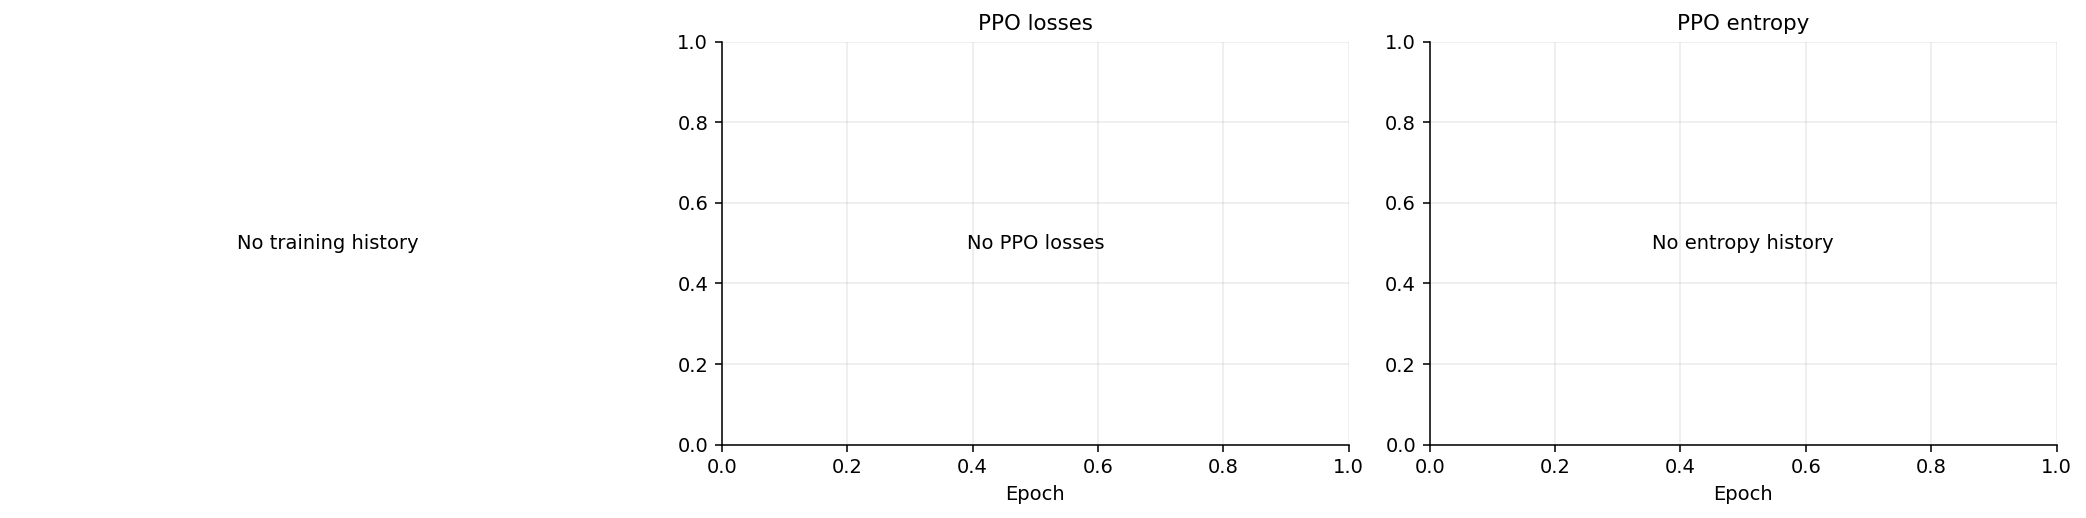

In [29]:
from quantfinlab.plotting.ml import policy_entropy_curve, ppo_loss_curves, training_reward_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
training_reward_curve(axes[0], ppo_history, label="PPO", title="PPO reward")
ppo_loss_curves(axes[1], ppo_history, title="PPO losses")
policy_entropy_curve(axes[2], ppo_history, title="PPO entropy")
plt.tight_layout()
plt.show()


,mean,std,min,max
SPY,0.1950,0.0580,0.0508,0.3294
QQQ,0.1046,0.0510,0.0215,0.2265
IWM,0.1181,0.0645,0.0174,0.2707
EFA,0.0742,0.0542,0.0070,0.2149
EEM,0.0359,0.0169,0.0119,0.0996
VNQ,0.0565,0.0637,0.0069,0.3307
DBC,0.0478,0.0445,0.0049,0.2148
GLD,0.0224,0.0239,0.0029,0.1311
IEF,0.0125,0.0157,0.0037,0.1572
TLT,0.0551,0.0704,0.0062,0.3500


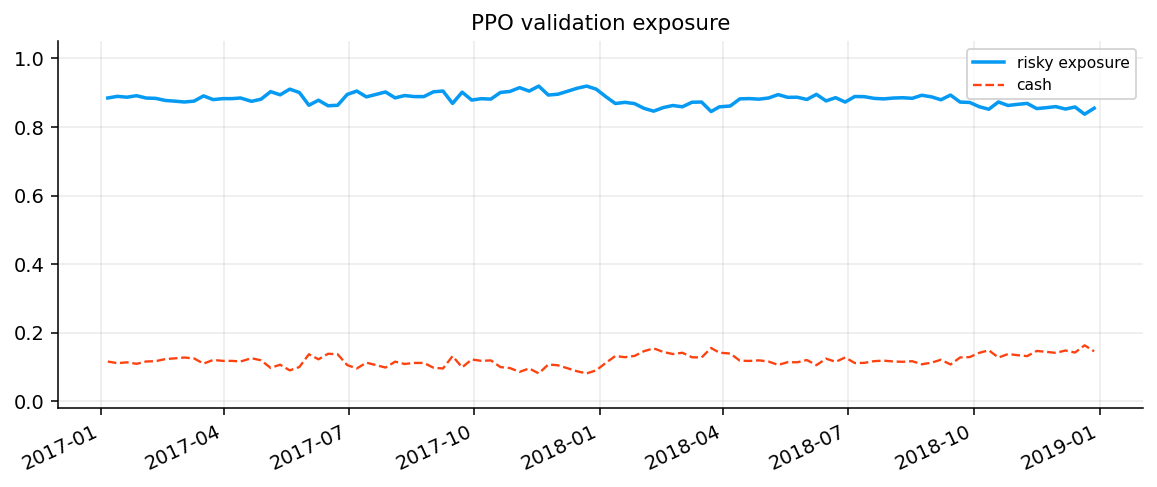

In [30]:
ppo_valid_rows = collect_policy_rollout(ppo, valid_idx, deterministic=True)
w_ppo_valid = pd.DataFrame(ppo_valid_rows["weights"], index=pd.DatetimeIndex(ppo_valid_rows["date"]), columns=state_columns)
display(w_ppo_valid.describe().T[["mean", "std", "min", "max"]].round(4))
fig, ax = plt.subplots(figsize=(10, 3.4))
policy_exposure_path(ax, w_ppo_valid, cash_ticker=cash_ticker, title="PPO validation exposure")
plt.show()


In [31]:
class RecurrentPpoActorCritic(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, recurrent_size=80, alpha_index=None):
        super().__init__()
        self.n_assets = n_assets
        self.sequence_length = 52
        self.alpha_index = alpha_index
        self.alpha_gain = nn.Parameter(torch.tensor(4.0)) if alpha_index is not None else None
        self.encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        self.lstm = nn.LSTM(self.encoder.output_dim, recurrent_size, batch_first=True)
        self.score_head = nn.Sequential(nn.LayerNorm(self.encoder.asset_score_dim + recurrent_size), nn.Linear(self.encoder.asset_score_dim + recurrent_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.exposure_head = nn.Sequential(nn.LayerNorm(self.encoder.output_dim + recurrent_size), nn.Linear(self.encoder.output_dim + recurrent_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.log_std = nn.Parameter(torch.full((n_assets + 1,), -0.70))
        self.value = nn.Sequential(nn.LayerNorm(self.encoder.output_dim + recurrent_size), nn.Linear(self.encoder.output_dim + recurrent_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
    def _apply_alpha(self, mean, ax):
        if self.alpha_index is None:
            return mean
        n = self.n_assets
        risky = mean[..., :n] + self.alpha_gain * ax.float()[..., self.alpha_index]
        return torch.cat([risky, mean[..., n:]], dim=-1)
    def _heads(self, h_asset, context, global_h, port_h, fused, memory):
        if memory.ndim == 2:
            n = h_asset.shape[1]
            score_x = torch.cat([
                h_asset,
                context.unsqueeze(1).expand(-1, n, -1),
                global_h.unsqueeze(1).expand(-1, n, -1),
                port_h.unsqueeze(1).expand(-1, n, -1),
                memory.unsqueeze(1).expand(-1, n, -1),
            ], dim=-1)
            risky = self.score_head(score_x).squeeze(-1)
            base = torch.cat([fused, memory], dim=-1)
            exposure = self.exposure_head(base).squeeze(-1)
            value = self.value(base).squeeze(-1)
            return torch.cat([risky, exposure.unsqueeze(-1)], dim=-1), value
        B, T, N, H = h_asset.shape
        score_x = torch.cat([
            h_asset,
            context.unsqueeze(2).expand(-1, -1, N, -1),
            global_h.unsqueeze(2).expand(-1, -1, N, -1),
            port_h.unsqueeze(2).expand(-1, -1, N, -1),
            memory.unsqueeze(2).expand(-1, -1, N, -1),
        ], dim=-1)
        risky = self.score_head(score_x.reshape(B * T, N, -1)).reshape(B, T, N)
        base = torch.cat([fused, memory], dim=-1)
        exposure = self.exposure_head(base).squeeze(-1)
        value = self.value(base).squeeze(-1)
        return torch.cat([risky, exposure.unsqueeze(-1)], dim=-1), value
    def distribution(self, ax, gx, px, hidden=None):
        h_asset, context, global_h, port_h, fused = self.encoder.encode(ax, gx, px)
        memory, hidden = self.lstm(fused.unsqueeze(1), hidden)
        mean, value = self._heads(h_asset, context, global_h, port_h, fused, memory[:, -1, :])
        mean = self._apply_alpha(mean, ax)
        std = torch.exp(self.log_std).clamp(0.05, 2.0).expand_as(mean)
        return Normal(mean, std), value, hidden
    def sequence_distribution(self, ax, gx, px):
        B, T = ax.shape[0], ax.shape[1]
        flat_ax = ax.reshape(B * T, ax.shape[2], ax.shape[3])
        flat_gx = gx.reshape(B * T, gx.shape[2])
        flat_px = px.reshape(B * T, px.shape[2])
        h_asset, context, global_h, port_h, fused = self.encoder.encode(flat_ax, flat_gx, flat_px)
        h_asset = h_asset.reshape(B, T, h_asset.shape[1], h_asset.shape[2])
        context = context.reshape(B, T, -1)
        global_h = global_h.reshape(B, T, -1)
        port_h = port_h.reshape(B, T, -1)
        fused = fused.reshape(B, T, -1)
        memory, _ = self.lstm(fused)
        mean, value = self._heads(h_asset, context, global_h, port_h, fused, memory)
        mean = self._apply_alpha(mean, ax)
        std = torch.exp(self.log_std).clamp(0.05, 2.0).view(1, 1, -1).expand_as(mean)
        return Normal(mean, std), value
    def act(self, ax, gx, px, hidden=None, deterministic=False):
        dist, value, hidden = self.distribution(ax, gx, px, hidden)
        action = dist.mean if deterministic else dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        weights = action_to_weights(action, reward_settings["min_exposure"], reward_settings["max_exposure"], reward_settings["max_weight"])
        return action, log_prob, entropy, value, weights, hidden
    def evaluate_actions(self, ax, gx, px, action):
        dist, value, _ = self.distribution(ax, gx, px, None)
        return dist.log_prob(action).sum(-1), dist.entropy().sum(-1), value
    def evaluate_sequence_actions(self, ax, gx, px, action):
        dist, value = self.sequence_distribution(ax, gx, px)
        return dist.log_prob(action).sum(-1), dist.entropy().sum(-1), value


In [32]:
def collect_recurrent_rollout(model, indices, deterministic=False):
    model.to(device)
    w_prev = np.zeros(len(state_columns), dtype=float)
    nav = peak = 1.0
    prev_turnover = 0.0
    returns_hist, daily_returns_hist = [], []
    dsr_state = DifferentialSharpe(reward_settings["dsr_eta"])
    ew_daily_hist = []
    hidden = None
    rows = {k: [] for k in ["asset", "global", "portfolio", "action", "log_prob", "entropy", "value", "reward", "return", "daily_returns", "weights", "date", "components"]}
    for pos, t in enumerate(indices):
        if pos % 52 == 0:
            hidden = None
        ax_np, gx_np, px_np = inputs_for_step(t, w_prev, nav, peak, returns_hist, prev_turnover, daily_returns_hist)
        ax_t = torch.tensor(ax_np[None], dtype=torch.float32, device=device)
        gx_t = torch.tensor(gx_np[None], dtype=torch.float32, device=device)
        px_t = torch.tensor(px_np[None], dtype=torch.float32, device=device)
        with torch.no_grad():
            action, logp, entropy, value, w_t, hidden = model.act(ax_t, gx_t, px_t, hidden=hidden, deterministic=deterministic)
            hidden = tuple(h.detach() for h in hidden)
        w_new, port_ret, turnover, cost, w_end, nav, peak, comps, daily_net, equal_daily = environment_step(t, action.detach().cpu().numpy().reshape(-1), w_prev, nav, peak, daily_returns_hist, ew_daily_hist, dsr_state, reward_settings)
        for key, val in [
            ("asset", ax_np), ("global", gx_np), ("portfolio", px_np), ("action", action.detach().cpu().numpy().reshape(-1)),
            ("log_prob", float(logp.detach().cpu())), ("entropy", float(entropy.detach().cpu())), ("value", float(value.detach().cpu())),
            ("reward", comps["reward"]), ("return", port_ret), ("daily_returns", daily_net), ("weights", w_new), ("date", state_dates[t]), ("components", comps)
        ]:
            rows[key].append(val)
        returns_hist.append(port_ret)
        daily_returns_hist.extend([float(x) for x in daily_net])
        ew_daily_hist.extend([float(x) for x in equal_daily])
        prev_turnover = turnover
        w_prev = w_end
    return rows

def train_recurrent_ppo_model(model, model_path, epochs=100, lr=2.5e-4):
    model.to(device)
    if model_path.exists():
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            rows = collect_recurrent_rollout(model, valid_idx, deterministic=True)
            return pd.DataFrame(), validation_stats_from_rollout(rows)
        except Exception as exc:
            print(f"Retraining Recurrent PPO because checkpoint is incompatible: {exc}")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    history, best_score, best_state = [], -np.inf, None
    for epoch in range(1, epochs + 1):
        if len(train_idx) > 104:
            start = int(np.random.randint(0, max(1, len(train_idx) // 5))) if np.random.rand() < 0.4 else int(np.random.randint(0, max(1, len(train_idx) - 104)))
            idx = train_idx[start:start + 104]
        else:
            idx = train_idx
        rows = collect_recurrent_rollout(model, idx, deterministic=False)
        rewards = np.asarray(rows["reward"], dtype=np.float32)
        values = np.asarray(rows["value"], dtype=np.float32)
        ranges = [(i, min(i + 52, len(rewards))) for i in range(0, len(rewards), 52) if min(i + 52, len(rewards)) - i >= 2]
        adv = np.zeros_like(rewards)
        ret = np.zeros_like(rewards)
        for a, b in ranges:
            adv[a:b], ret[a:b] = gae(rewards[a:b], values[a:b])
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        asset_np = np.asarray(rows["asset"])
        global_np = np.asarray(rows["global"])
        port_np = np.asarray(rows["portfolio"])
        action_np = np.asarray(rows["action"])
        old_log_np = np.asarray(rows["log_prob"], dtype=np.float32)
        last_loss_pi = last_loss_v = last_entropy = torch.tensor(np.nan, device=device)
        for _ in range(5):
            for a, b in ranges:
                ax_t = torch.tensor(asset_np[a:b][None], dtype=torch.float32, device=device)
                gx_t = torch.tensor(global_np[a:b][None], dtype=torch.float32, device=device)
                px_t = torch.tensor(port_np[a:b][None], dtype=torch.float32, device=device)
                act_t = torch.tensor(action_np[a:b][None], dtype=torch.float32, device=device)
                old_log = torch.tensor(old_log_np[a:b][None], dtype=torch.float32, device=device)
                adv_t = torch.tensor(adv[a:b][None], dtype=torch.float32, device=device)
                ret_t = torch.tensor(ret[a:b][None], dtype=torch.float32, device=device)
                logp, entropy, value = model.evaluate_sequence_actions(ax_t, gx_t, px_t, act_t)
                ratio = torch.exp(logp - old_log)
                loss_pi = -torch.min(ratio * adv_t, torch.clamp(ratio, 0.8, 1.2) * adv_t).mean()
                loss_v = torch.nn.functional.mse_loss(value, ret_t)
                loss = loss_pi + 0.5 * loss_v - 0.004 * entropy.mean()
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                opt.step()
                last_loss_pi, last_loss_v, last_entropy = loss_pi, loss_v, entropy.mean()
        valid_reward = np.nan
        valid_sharpe = np.nan
        if epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            stats = validation_stats_from_rollout(collect_recurrent_rollout(model, valid_idx, deterministic=True))
            valid_reward, valid_sharpe = stats["total_reward"], stats["sharpe"]
            score = valid_sharpe if np.isfinite(valid_sharpe) else valid_reward
            if score > best_score:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        history.append({"epoch": epoch, "train_reward": np.sum(rows["reward"]), "policy_loss": float(last_loss_pi.detach().cpu()), "value_loss": float(last_loss_v.detach().cpu()), "entropy": float(last_entropy.detach().cpu()), "avg_exposure": np.mean([w[:-1].sum() for w in rows["weights"]]), "validation_reward": valid_reward, "validation_sharpe": valid_sharpe})
    if best_state is not None:
        model.load_state_dict(best_state)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    return pd.DataFrame(history), validation_stats_from_rollout(collect_recurrent_rollout(model, valid_idx, deterministic=True))


In [33]:
rppo = RecurrentPpoActorCritic(asset_state.shape[2], global_state.shape[1], len(assets), hidden_size=128, recurrent_size=96, alpha_index=alpha_index)
rppo_history, rppo_validation = train_recurrent_ppo_model(
    rppo,
    model_dir / "recurrent_ppo_dsr.pt",
    epochs=rppo_epochs_main,
)
display(pd.Series(rppo_validation).to_frame("Recurrent PPO").round(4))


,Recurrent PPO
total_reward,79.8662
mean_reward,0.7679
return,0.1128
vol,0.0757
sharpe,0.2176
max_drawdown,-0.0918
avg_exposure,0.7574


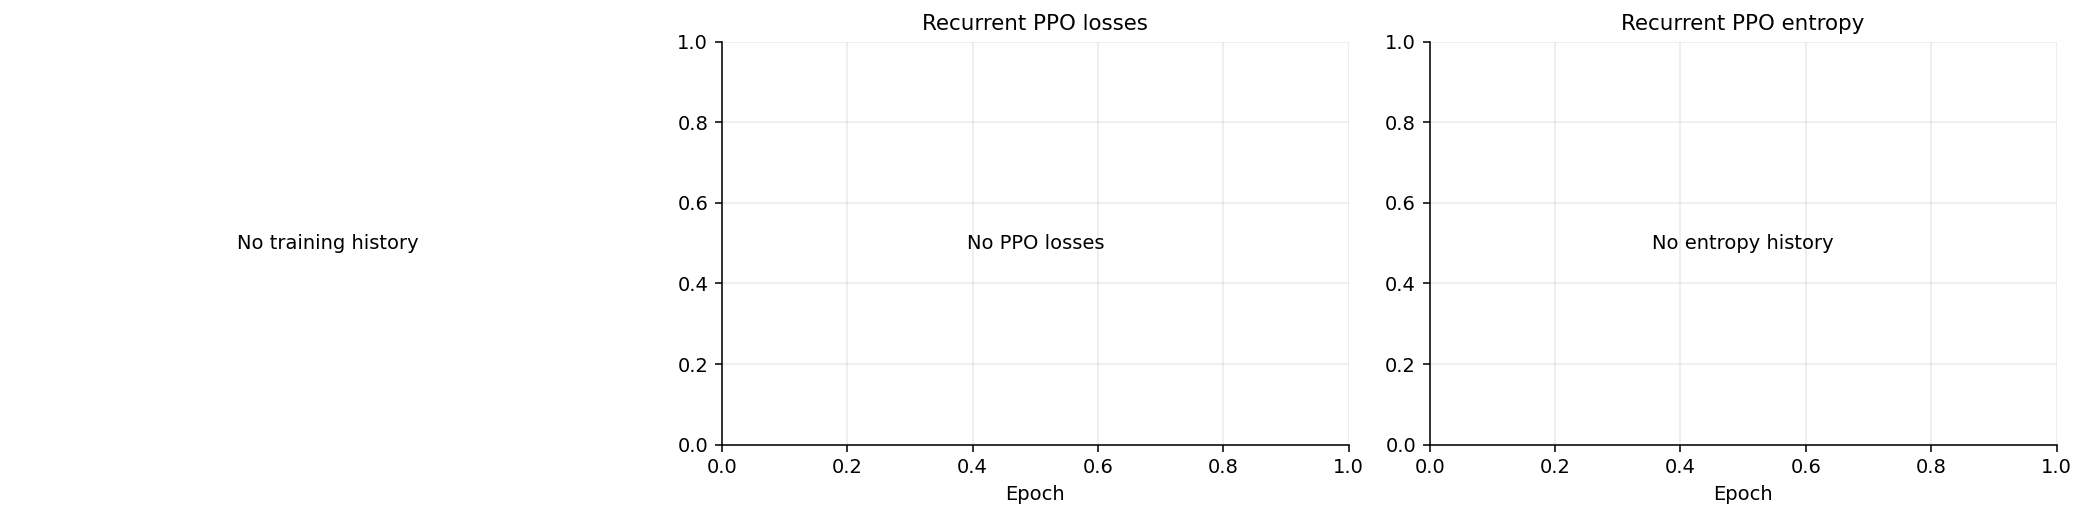

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
training_reward_curve(axes[0], rppo_history, label="Recurrent PPO", title="Recurrent PPO reward")
ppo_loss_curves(axes[1], rppo_history, title="Recurrent PPO losses")
policy_entropy_curve(axes[2], rppo_history, title="Recurrent PPO entropy")
plt.tight_layout()
plt.show()


,mean,std,min,max
SPY,0.2153,0.0762,0.0525,0.3500
QQQ,0.1236,0.0771,0.0144,0.3500
IWM,0.1259,0.0946,0.0094,0.3500
EFA,0.0679,0.0530,0.0031,0.2188
EEM,0.0337,0.0291,0.0058,0.1899
VNQ,0.0420,0.0586,0.0018,0.3297
DBC,0.0387,0.0488,0.0021,0.2570
GLD,0.0088,0.0112,0.0014,0.0678
IEF,0.0037,0.0043,0.0013,0.0379
TLT,0.0291,0.0562,0.0021,0.2837


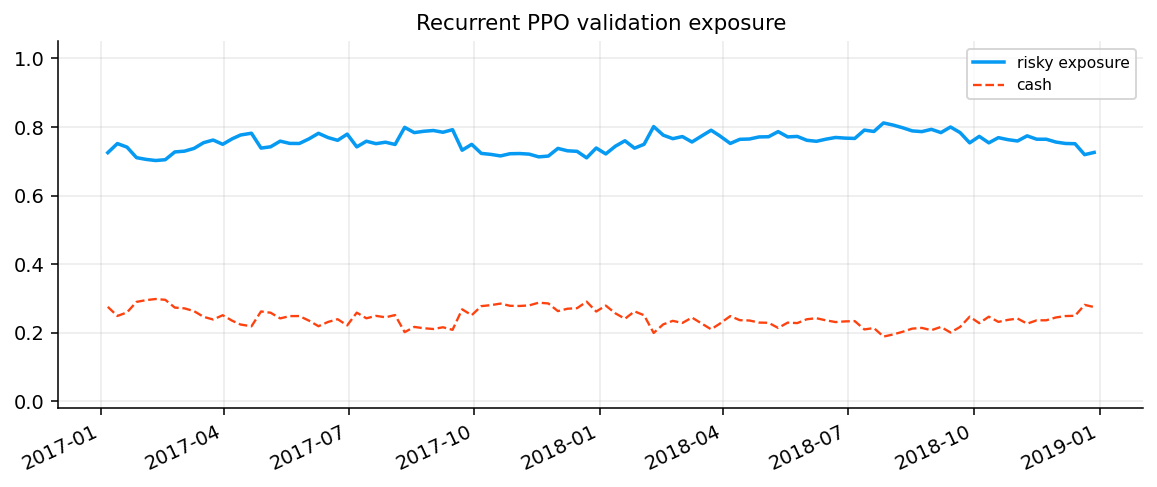

In [35]:
rppo_valid_rows = collect_recurrent_rollout(rppo, valid_idx, deterministic=True)
w_rppo_valid = pd.DataFrame(rppo_valid_rows["weights"], index=pd.DatetimeIndex(rppo_valid_rows["date"]), columns=state_columns)
display(w_rppo_valid.describe().T[["mean", "std", "min", "max"]].round(4))
fig, ax = plt.subplots(figsize=(10, 3.4))
policy_exposure_path(ax, w_rppo_valid, cash_ticker=cash_ticker, title="Recurrent PPO validation exposure")
plt.show()


In [36]:
class SacCriticLocal(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96):
        super().__init__()
        self.encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        q_in = self.encoder.output_dim + n_assets + 1
        self.q1 = nn.Sequential(nn.LayerNorm(q_in), nn.Linear(q_in, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.q2 = nn.Sequential(nn.LayerNorm(q_in), nn.Linear(q_in, hidden_size), nn.SiLU(), nn.Linear(hidden_size, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
    def forward(self, ax, gx, px, action):
        z = self.encoder(ax, gx, px)
        qx = torch.cat([z, action.float()], dim=-1)
        return self.q1(qx).squeeze(-1), self.q2(qx).squeeze(-1)

class SacActorCritic(nn.Module):
    def __init__(self, n_asset_features, n_global_features, n_assets, hidden_size=96, alpha_index=None):
        super().__init__()
        self.n_assets = n_assets
        self.alpha_index = alpha_index
        self.alpha_gain = nn.Parameter(torch.tensor(4.0)) if alpha_index is not None else None
        self.actor_encoder = CrossAssetEncoder(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
        self.actor_score_head = nn.Sequential(nn.LayerNorm(self.actor_encoder.asset_score_dim), nn.Linear(self.actor_encoder.asset_score_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.actor_exposure_head = nn.Sequential(nn.LayerNorm(self.actor_encoder.output_dim), nn.Linear(self.actor_encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, 1))
        self.actor_log_std_head = nn.Sequential(nn.LayerNorm(self.actor_encoder.output_dim), nn.Linear(self.actor_encoder.output_dim, hidden_size), nn.SiLU(), nn.Linear(hidden_size, n_assets + 1))
        self.critic = SacCriticLocal(n_asset_features, n_global_features, n_assets, hidden_size=hidden_size)
    def action_mean(self, ax, gx, px):
        h_asset, context, global_h, port_h, fused = self.actor_encoder.encode(ax, gx, px)
        n = h_asset.shape[1]
        score_x = torch.cat([
            h_asset,
            context.unsqueeze(1).expand(-1, n, -1),
            global_h.unsqueeze(1).expand(-1, n, -1),
            port_h.unsqueeze(1).expand(-1, n, -1),
        ], dim=-1)
        risky = self.actor_score_head(score_x).squeeze(-1)
        if self.alpha_index is not None:
            risky = risky + self.alpha_gain * ax.float()[..., self.alpha_index]
        exposure = self.actor_exposure_head(fused).squeeze(-1)
        return torch.cat([risky, exposure.unsqueeze(-1)], dim=-1), fused
    def sample_action(self, ax, gx, px, deterministic=False):
        mean, fused = self.action_mean(ax, gx, px)
        std = torch.exp(self.actor_log_std_head(fused).clamp(-5, 1))
        dist = Normal(mean, std)
        action = mean if deterministic else dist.rsample()
        logp = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        weights = action_to_weights(action, reward_settings["min_exposure"], reward_settings["max_exposure"], reward_settings["max_weight"])
        return action, logp, entropy, weights
    def q_values(self, ax, gx, px, action):
        return self.critic(ax, gx, px, action)
    def act(self, ax, gx, px, deterministic=False):
        action, logp, entropy, weights = self.sample_action(ax, gx, px, deterministic=deterministic)
        return action, logp, entropy, torch.zeros_like(logp), weights


In [37]:
def train_sac_model(model, model_path, epochs=120, batch_size=128, alpha=0.05):
    model.to(device)
    if model_path.exists():
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            rows = collect_policy_rollout(model, valid_idx, deterministic=True)
            return pd.DataFrame(), validation_stats_from_rollout(rows)
        except Exception as exc:
            print(f"Retraining SAC because checkpoint is incompatible: {exc}")
    target_critic = copy.deepcopy(model.critic).to(device)
    actor_params = list(model.actor_encoder.parameters()) + list(model.actor_score_head.parameters()) + list(model.actor_exposure_head.parameters()) + list(model.actor_log_std_head.parameters()) + ([model.alpha_gain] if getattr(model, "alpha_gain", None) is not None else [])
    critic_params = list(model.critic.parameters())
    actor_opt = torch.optim.AdamW(actor_params, lr=3e-4, weight_decay=1e-5)
    critic_opt = torch.optim.AdamW(critic_params, lr=3e-4, weight_decay=1e-5)
    log_alpha = torch.tensor(np.log(alpha), dtype=torch.float32, device=device, requires_grad=True)
    alpha_opt = torch.optim.AdamW([log_alpha], lr=3e-4)
    target_entropy = -0.75 * (len(assets) + 1)
    reward_scale = 0.01
    replay, history, best_score, best_state = [], [], -np.inf, None
    update_count = 0
    sac_rollout_length = 156
    for epoch in range(1, epochs + 1):
        if len(train_idx) > sac_rollout_length:
            start = int(np.random.randint(0, max(1, len(train_idx) // 5))) if np.random.rand() < 0.4 else int(np.random.randint(0, max(1, len(train_idx) - sac_rollout_length)))
            idx = train_idx[start:start + sac_rollout_length]
        else:
            idx = train_idx
        rows = collect_policy_rollout(model, idx, deterministic=False)
        for i in range(len(rows["reward"])):
            ni = min(i + 1, len(rows["reward"]) - 1)
            replay.append((rows["asset"][i], rows["global"][i], rows["portfolio"][i], rows["action"][i], rows["reward"][i], rows["asset"][ni], rows["global"][ni], rows["portfolio"][ni], float(i == len(rows["reward"]) - 1)))
        replay = replay[-100000:]
        critic_losses, actor_losses, q_values = [], [], []
        updates = max(1, len(train_idx) // batch_size)
        for _ in range(updates):
            if len(replay) < batch_size:
                break
            pick = np.random.randint(0, len(replay), size=batch_size)
            batch = [replay[i] for i in pick]
            ax = torch.tensor(np.asarray([b[0] for b in batch]), dtype=torch.float32, device=device)
            gx = torch.tensor(np.asarray([b[1] for b in batch]), dtype=torch.float32, device=device)
            px = torch.tensor(np.asarray([b[2] for b in batch]), dtype=torch.float32, device=device)
            act = torch.tensor(np.asarray([b[3] for b in batch]), dtype=torch.float32, device=device)
            rew = torch.tensor(np.asarray([b[4] for b in batch]), dtype=torch.float32, device=device) * reward_scale
            nax = torch.tensor(np.asarray([b[5] for b in batch]), dtype=torch.float32, device=device)
            ngx = torch.tensor(np.asarray([b[6] for b in batch]), dtype=torch.float32, device=device)
            npx = torch.tensor(np.asarray([b[7] for b in batch]), dtype=torch.float32, device=device)
            done = torch.tensor(np.asarray([b[8] for b in batch]), dtype=torch.float32, device=device)
            with torch.no_grad():
                nact, nlogp, _, _ = model.sample_action(nax, ngx, npx)
                tq1, tq2 = target_critic(nax, ngx, npx, nact)
                target_q = torch.min(tq1, tq2) - log_alpha.exp().detach() * nlogp
                y = rew + reward_settings["sac_gamma"] * (1.0 - done) * target_q
            q1, q2 = model.q_values(ax, gx, px, act)
            critic_loss = torch.nn.functional.mse_loss(q1, y) + torch.nn.functional.mse_loss(q2, y)
            critic_opt.zero_grad(set_to_none=True)
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(critic_params, 2.0)
            critic_opt.step()
            update_count += 1
            if update_count % 2 == 0:
                for p in model.critic.parameters():
                    p.requires_grad_(False)
                pact, logp, entropy, _ = model.sample_action(ax, gx, px)
                q1p, q2p = model.q_values(ax, gx, px, pact)
                qpi = torch.min(q1p, q2p)
                actor_loss = (log_alpha.exp().detach() * logp - qpi).mean()
                actor_opt.zero_grad(set_to_none=True)
                actor_loss.backward()
                torch.nn.utils.clip_grad_norm_(actor_params, 2.0)
                actor_opt.step()
                alpha_loss = -(log_alpha * (logp.detach() + target_entropy)).mean()
                alpha_opt.zero_grad(set_to_none=True)
                alpha_loss.backward()
                alpha_opt.step()
                for p in model.critic.parameters():
                    p.requires_grad_(True)
                for tp, sp in zip(target_critic.parameters(), model.critic.parameters()):
                    tp.data.mul_(0.995).add_(sp.data, alpha=0.005)
                actor_losses.append(float(actor_loss.detach().cpu()))
                q_values.append(float(qpi.mean().detach().cpu()))
            critic_losses.append(float(critic_loss.detach().cpu()))
        valid_reward = np.nan
        valid_sharpe = np.nan
        if epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            stats = validation_stats_from_rollout(collect_policy_rollout(model, valid_idx, deterministic=True))
            valid_reward, valid_sharpe = stats["total_reward"], stats["sharpe"]
            score = valid_sharpe if np.isfinite(valid_sharpe) else valid_reward
            if score > best_score:
                best_score = score
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        history.append({"epoch": epoch, "train_reward": np.sum(rows["reward"]), "critic_loss": np.mean(critic_losses) if critic_losses else np.nan, "actor_loss": np.mean(actor_losses) if actor_losses else np.nan, "q_value": np.mean(q_values) if q_values else np.nan, "alpha": float(log_alpha.exp().detach().cpu()), "entropy": np.mean(rows["entropy"]), "avg_exposure": np.mean([w[:-1].sum() for w in rows["weights"]]), "validation_reward": valid_reward, "validation_sharpe": valid_sharpe})
    if best_state is not None:
        model.load_state_dict(best_state)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    return pd.DataFrame(history), validation_stats_from_rollout(collect_policy_rollout(model, valid_idx, deterministic=True))


In [38]:
import copy
sac = SacActorCritic(asset_state.shape[2], global_state.shape[1], len(assets), hidden_size=128, alpha_index=alpha_index)
sac_history, sac_validation = train_sac_model(
    sac,
    model_dir / "sac_dsr.pt",
    epochs=sac_epochs_main,
    batch_size=128,
    alpha=0.05,
)
display(pd.Series(sac_validation).to_frame("SAC").round(4))


,SAC
total_reward,62.0742
mean_reward,0.5969
return,0.0923
vol,0.0786
sharpe,0.0955
max_drawdown,-0.1086
avg_exposure,0.7961


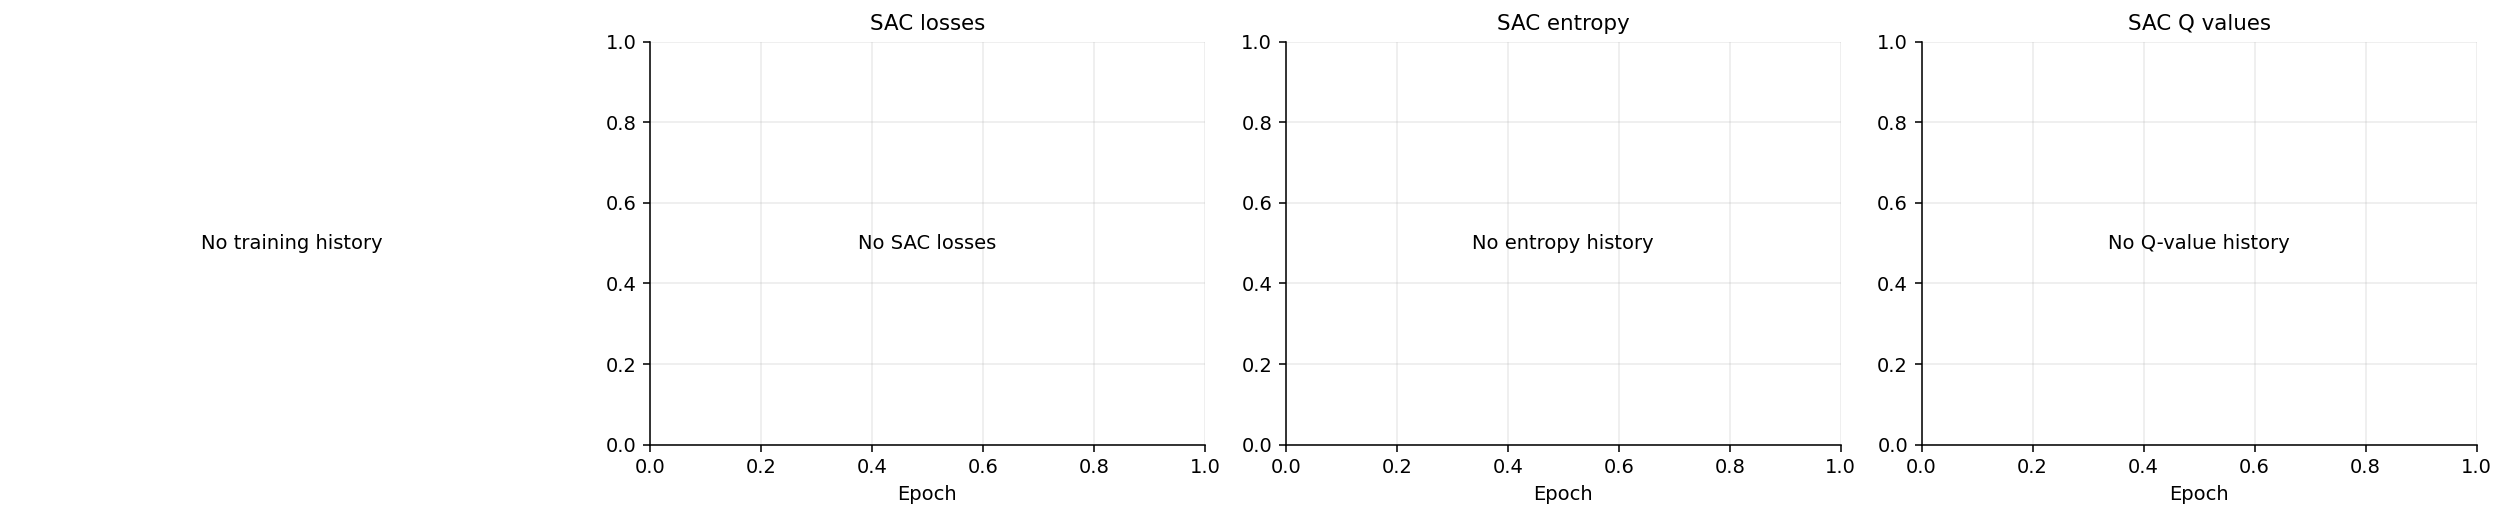

In [39]:
from quantfinlab.plotting.ml import q_value_curve, sac_loss_curves
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
training_reward_curve(axes[0], sac_history, label="SAC", title="SAC reward")
sac_loss_curves(axes[1], sac_history, title="SAC losses")
policy_entropy_curve(axes[2], sac_history, title="SAC entropy")
q_value_curve(axes[3], sac_history, title="SAC Q values")
plt.tight_layout()
plt.show()


,mean,std,min,max
SPY,0.2051,0.0479,0.0950,0.2821
QQQ,0.1147,0.0468,0.0342,0.2371
IWM,0.1165,0.0531,0.0211,0.2320
EFA,0.0750,0.0521,0.0086,0.2274
EEM,0.0360,0.0154,0.0123,0.0776
VNQ,0.0429,0.0446,0.0056,0.2130
DBC,0.0404,0.0354,0.0050,0.1570
GLD,0.0120,0.0111,0.0030,0.0651
IEF,0.0065,0.0046,0.0034,0.0444
TLT,0.0333,0.0338,0.0049,0.1608


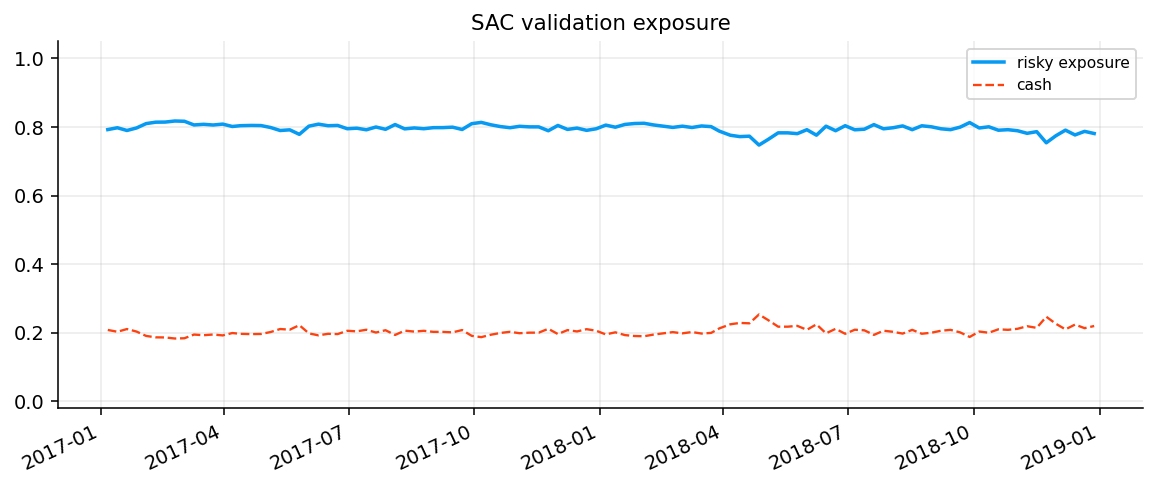

In [40]:
sac_valid_rows = collect_policy_rollout(sac, valid_idx, deterministic=True)
w_sac_valid = pd.DataFrame(sac_valid_rows["weights"], index=pd.DatetimeIndex(sac_valid_rows["date"]), columns=state_columns)
display(w_sac_valid.describe().T[["mean", "std", "min", "max"]].round(4))
fig, ax = plt.subplots(figsize=(10, 3.4))
policy_exposure_path(ax, w_sac_valid, cash_ticker=cash_ticker, title="SAC validation exposure")
plt.show()


In [41]:
def policy_weight_frame_local(model, indices, recurrent=False):
    rows = collect_recurrent_rollout(model, indices, deterministic=True) if recurrent else collect_policy_rollout(model, indices, deterministic=True)
    return pd.DataFrame(rows["weights"], index=pd.DatetimeIndex(rows["date"]), columns=state_columns)

def blend_policy_weights(weight_frames, blend_weights):
    total = sum(max(0.0, v) for v in blend_weights.values()) or float(len(weight_frames))
    columns = sorted({c for f in weight_frames.values() for c in f.columns})
    index = sorted({d for f in weight_frames.values() for d in f.index})
    blended = pd.DataFrame(0.0, index=pd.DatetimeIndex(index), columns=columns)
    for name, frame in weight_frames.items():
        blended = blended + (max(0.0, blend_weights.get(name, 0.0)) / total) * frame.reindex(index=blended.index, columns=columns).fillna(0.0)
    return blended.div(blended.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)

w_ppo = policy_weight_frame_local(ppo, test_idx)
w_rppo = policy_weight_frame_local(rppo, test_idx, recurrent=True)
w_sac = policy_weight_frame_local(sac, test_idx)
w_ensemble = blend_policy_weights(
    {"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac},
    {
        "PPO": max(0.01, ppo_validation["sharpe"]),
        "Recurrent PPO": max(0.01, rppo_validation["sharpe"]),
        "SAC": max(0.01, sac_validation["sharpe"]),
    },
).reindex(columns=state_columns).fillna(0.0)

weights_by_strategy = {
    "Equal Weight": w_eq,
    "Forecast-Gated MaxSharpe": w_forecast_gated_ms,
    "RandomForest Kelly": w_rf_kelly,
    "ML Regime-Aware": w_regime,
    "PPO": w_ppo,
    "Recurrent PPO": w_rppo,
    "SAC": w_sac,
    "Ensemble RL": w_ensemble,
}
test_returns_daily = r_d.loc[pd.Timestamp(test_period[0]):pd.Timestamp(test_period[1]), assets + [cash_ticker]]
final_backtests = run_many_weights_backtests(
    weights_by_strategy,
    returns=test_returns_daily,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=1.0,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)


In [42]:
final_summary = build_strategy_summary(final_backtests, rf_daily=rf_daily, annualization=annualization)
final_summary = final_summary.sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
display(final_summary[["CAGR", "Vol", "Sharpe", "Sortino", "Max Drawdown", "Turnover", "Effective N"]].round(4))


,CAGR,Vol,Sharpe,Sortino,Max Drawdown,Turnover,Effective N
Strategy,,,,,,,
Forecast-Gated MaxSharpe,0.1378,0.1344,0.7433,0.8964,-0.2035,0.3422,3.2603
ML Regime-Aware,0.1096,0.0997,0.6977,0.8659,-0.1982,0.2167,7.4312
RandomForest Kelly,0.1242,0.1312,0.6621,0.8575,-0.2342,0.4166,5.2439
Equal Weight,0.1022,0.1167,0.5570,0.6733,-0.2218,0.0178,12.0000
Recurrent PPO,0.0875,0.0983,0.4988,0.6045,-0.1938,0.1476,5.7204
SAC,0.0882,0.1025,0.4854,0.5811,-0.1942,0.1408,6.7317
Ensemble RL,0.0861,0.0999,0.4786,0.5755,-0.1964,0.1484,6.6771
PPO,0.0826,0.1021,0.4384,0.5263,-0.2155,0.1784,6.6505


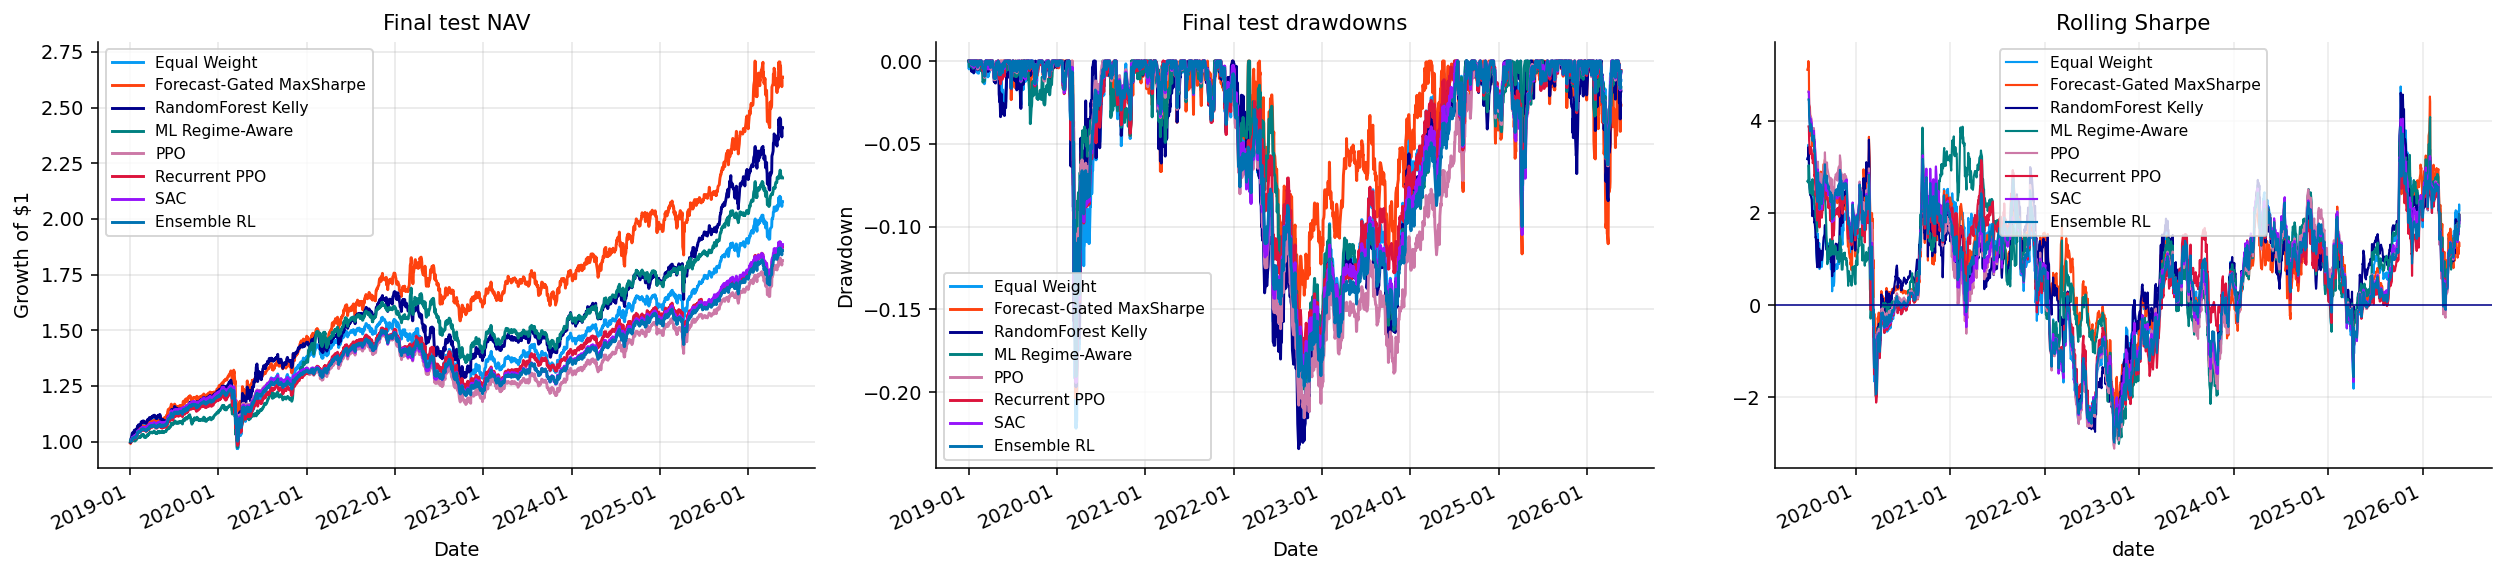

In [43]:
strategy_returns = pd.DataFrame({name: res.net_returns for name, res in final_backtests.items()}).dropna(how="all")
nav = pd.DataFrame({name: res.net_values for name, res in final_backtests.items()}).dropna(how="all")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
plot_strategy_nav(nav, ax=axes[0], title="Final test NAV")
plot_strategy_drawdowns(nav, ax=axes[1], title="Final test drawdowns")
plot_rolling_sharpe(axes[2], strategy_returns, window=126, rf_daily=rf_daily, title="Rolling Sharpe")
plt.tight_layout()
plt.show()


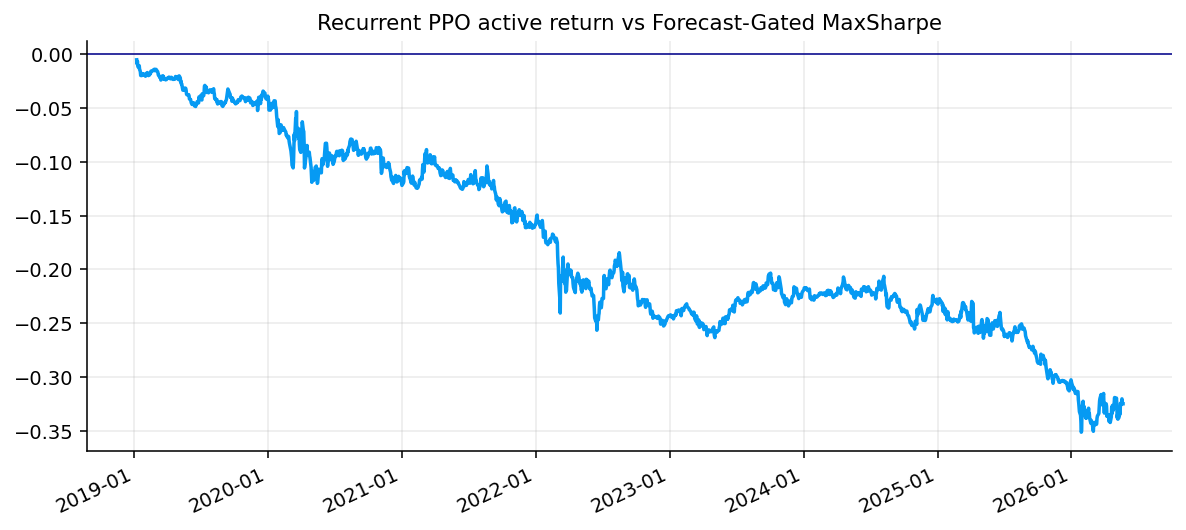

best policy: Recurrent PPO


In [44]:
best_policy_name = final_summary.loc[[x for x in final_summary.index if x in ["PPO", "Recurrent PPO", "SAC"]], "Sharpe"].idxmax()
fig, ax = plt.subplots(figsize=(10, 3.8))
active_return_curve(ax, strategy_returns, strategy=best_policy_name, benchmark="Forecast-Gated MaxSharpe", title=f"{best_policy_name} active return vs Forecast-Gated MaxSharpe")
plt.show()
print("best policy:", best_policy_name)


In [45]:
def active_performance(strategy_returns, benchmark):
    R = strategy_returns.copy()
    rows = []
    b = R[benchmark]
    for name in R.columns:
        if name == benchmark:
            continue
        active = (R[name] - b).dropna()
        te = active.std(ddof=1) * np.sqrt(252.0)
        active_ann = active.mean() * 252.0
        active_nav = (1 + active).cumprod()
        rows.append({
            "Strategy": name,
            "Active CAGR": active_ann,
            "Tracking Error": te,
            "Information Ratio": active_ann / te if te > 0 else np.nan,
            "Active Max Drawdown": (active_nav / active_nav.cummax() - 1).min(),
            "Monthly Active Hit Rate": (active.resample("ME").sum() > 0).mean(),
        })
    return pd.DataFrame(rows).set_index("Strategy")

active_table = active_performance(strategy_returns, "Forecast-Gated MaxSharpe")
display(active_table.round(4))


,Active CAGR,Tracking Error,Information Ratio,Active Max Drawdown,Monthly Active Hit Rate
Strategy,,,,,
Equal Weight,-0.0349,0.0747,-0.4675,-0.2976,0.4157
RandomForest Kelly,-0.0131,0.0744,-0.1756,-0.2496,0.5056
ML Regime-Aware,-0.0304,0.0774,-0.3924,-0.2506,0.3820
PPO,-0.0540,0.0730,-0.7401,-0.3788,0.3596
Recurrent PPO,-0.0497,0.0729,-0.6824,-0.3482,0.4494
SAC,-0.0490,0.0723,-0.6782,-0.3504,0.4607
Ensemble RL,-0.0509,0.0718,-0.7101,-0.3592,0.4045


In [46]:
policy_weights = {"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac}
diagnostic_rows = []
for name, W in policy_weights.items():
    risky = W[assets].sum(axis=1)
    turnover = 0.5 * W.diff().abs().sum(axis=1).fillna(0.0)
    hhi = (W[assets] ** 2).sum(axis=1)
    diagnostic_rows.append({
        "Policy": name,
        "Avg Risky Exposure": risky.mean(),
        "Avg Cash": W[cash_ticker].mean(),
        "Avg Turnover": turnover.mean(),
        "Avg HHI": hhi.mean(),
        "Effective N": 1.0 / hhi.mean(),
        "Avg Max Weight": W[assets].max(axis=1).mean(),
    })
policy_diagnostics = pd.DataFrame(diagnostic_rows).set_index("Policy")
display(policy_diagnostics.round(4))


,Avg Risky Exposure,Avg Cash,Avg Turnover,Avg HHI,Effective N,Avg Max Weight
Policy,,,,,,
PPO,0.8773,0.1227,0.1779,0.1374,7.2785,0.2627
Recurrent PPO,0.7508,0.2492,0.1467,0.1152,8.6797,0.2453
SAC,0.7948,0.2052,0.1393,0.1067,9.3701,0.2215


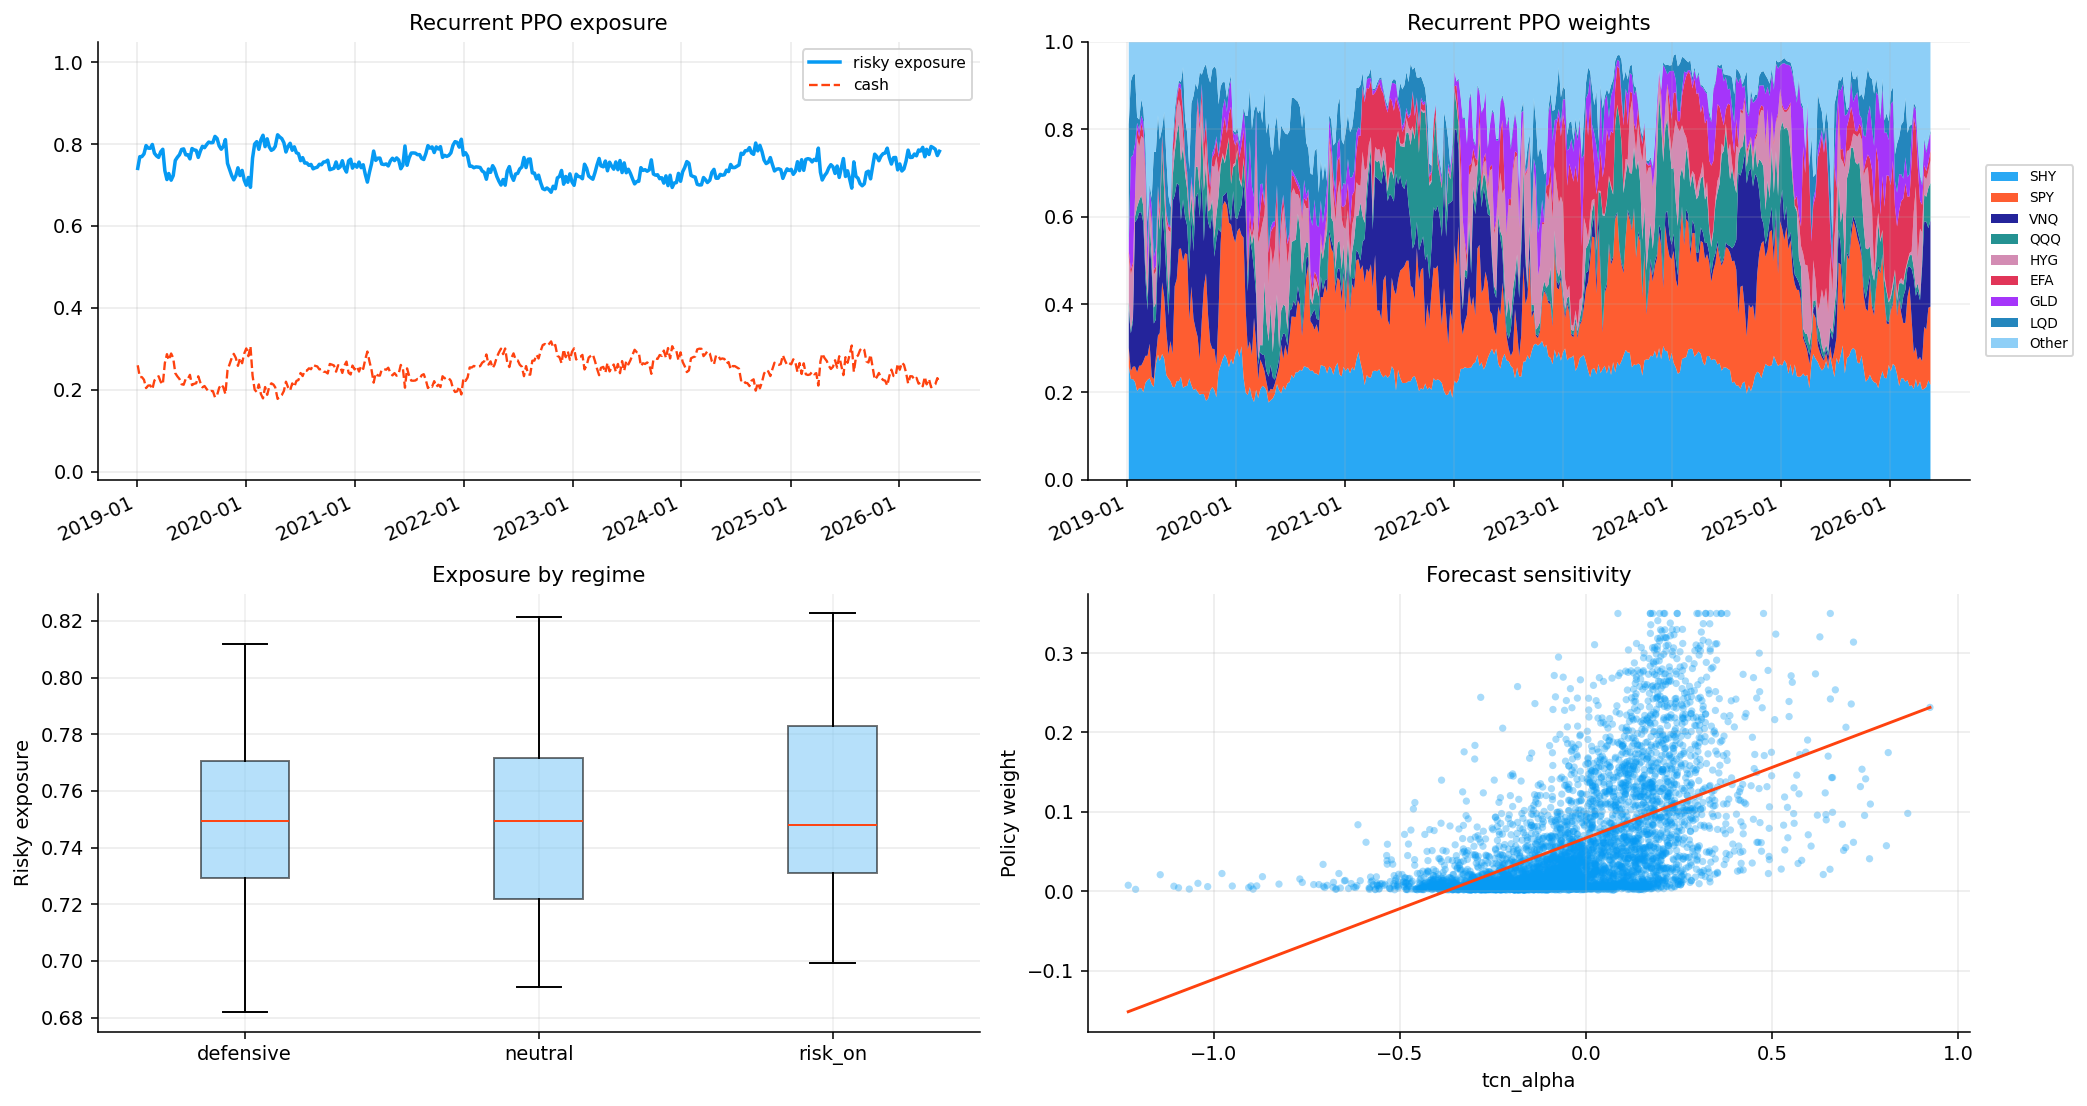

In [47]:
best_weights = policy_weights[best_policy_name]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
policy_exposure_path(axes[0, 0], best_weights, cash_ticker=cash_ticker, title=f"{best_policy_name} exposure")
policy_weight_area(axes[0, 1], best_weights, title=f"{best_policy_name} weights")
regime_exposure_boxplot(axes[1, 0], best_weights, regime_x, title="Exposure by regime")
forecast_policy_sensitivity(axes[1, 1], best_weights, forecast_x, title="Forecast sensitivity")
plt.tight_layout()
plt.show()


In [48]:
def ablated_asset_state(kind, base_state):
    arr = base_state.copy()
    if kind == "no_forecasts":
        for i, name in enumerate(asset_feature_names):
            lname = name.lower()
            if "tcn" in lname or "forecast" in lname or "alpha" in lname or "hgb" in lname or "rf" in lname or lname.startswith("z_"):
                arr[:, :, i] = 0.0
    elif kind == "no_priors":
        for i, name in enumerate(asset_feature_names):
            if name.startswith("prior_"):
                arr[:, :, i] = 0.0
    elif kind == "shuffled_forecasts":
        rng = np.random.default_rng(seed)
        for i, name in enumerate(asset_feature_names):
            lname = name.lower()
            if "tcn" in lname or "forecast" in lname or "alpha" in lname or "hgb" in lname or "rf" in lname or lname.startswith("z_"):
                arr[:, :, i] = arr[rng.permutation(arr.shape[0]), :, i]
    return arr

base_asset_state = asset_state.copy()
ablation_results = {}
try:
    for kind in ["no_forecasts", "no_priors", "shuffled_forecasts"]:
        asset_state = ablated_asset_state(kind, base_asset_state)
        rows = collect_recurrent_rollout(rppo, test_idx, deterministic=True) if best_policy_name == "Recurrent PPO" else collect_policy_rollout({"PPO": ppo, "SAC": sac}.get(best_policy_name, ppo), test_idx, deterministic=True)
        ablation_results[kind] = validation_stats_from_rollout(rows)
finally:
    asset_state = base_asset_state


In [49]:
ablation_table = pd.DataFrame(ablation_results).T
base_eval = validation_stats_from_rollout(collect_recurrent_rollout(rppo, test_idx, deterministic=True) if best_policy_name == "Recurrent PPO" else collect_policy_rollout({"PPO": ppo, "SAC": sac}.get(best_policy_name, ppo), test_idx, deterministic=True))
ablation_table.loc["base"] = base_eval
display(ablation_table[["total_reward", "return", "sharpe", "max_drawdown", "avg_exposure"]].round(4))


,total_reward,return,sharpe,max_drawdown,avg_exposure
no_forecasts,-311.9888,0.8485,0.5101,-0.1809,0.7458
no_priors,-303.0271,0.8755,0.5033,-0.1938,0.7508
shuffled_forecasts,-336.9653,0.5091,0.2068,-0.2231,0.7543
base,-303.0271,0.8755,0.5033,-0.1938,0.7508


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Ensemble RL,0.0090,0.0149,0.0097,0.0267,0.0108,0.0166
Equal Weight,0.0105,0.0174,0.0114,0.0303,0.0114,0.0175
Forecast-Gated MaxSharpe,0.0121,0.0201,0.0124,0.0341,0.0236,0.0344
ML Regime-Aware,0.0093,0.0150,0.0101,0.0206,0.0075,0.0112
PPO,0.0089,0.0151,0.0098,0.0283,0.0114,0.0175
RandomForest Kelly,0.0123,0.0192,0.0117,0.0278,0.0198,0.0296
Recurrent PPO,0.0090,0.0149,0.0097,0.0239,0.0103,0.0158
SAC,0.0092,0.0152,0.0097,0.0293,0.0107,0.0165


breach_count  breach_rate  coverage_error  \
object                   method                                              
Ensemble RL              cf                90       0.0549          0.0049   
                         fhs               92       0.0562          0.0062   
                         hist              98       0.0598          0.0098   
Equal Weight             cf                98       0.0597          0.0097   
                         fhs               92       0.0561          0.0061   
                         hist              97       0.0591          0.0091   
Forecast-Gated MaxSharpe cf                98       0.0597          0.0097   
                         fhs               85       0.0518          0.0018   
                         hist              95       0.0579          0.0079   
ML Regime-Aware          cf                73       0.0445         -0.0055   
                         fhs               88       0.0536          0.0036   
                         hist              88       0.0536          0.0036   
PPO                      cf                92       0.0562          0.0062   
                         fhs               93       0.0568          0.0068   
                         hist             101       0.0617          0.0117   
RandomForest Kelly       cf               119       0.0725          0.0225   
                         fhs               94       0.0573          0.0073   
                         hist             102       0.0622          0.0122   
Recurrent PPO            cf                86       0.0525          0.0025   
                         fhs               94       0.0574          0.0074   
                         hist             100       0.0611          0.0111   
SAC                      cf                92       0.0562          0.0062   
                         fhs               91       0.0556          0.0056   
                         hist              97       0.0592          0.0092   

                                 abs_coverage_error  longest_breach_streak  \
object                   method                                              
Ensemble RL              cf                  0.0049                      3   
                         fhs                 0.0062                      2   
                         hist                0.0098                      4   
Equal Weight             cf                  0.0097                      4   
                         fhs                 0.0061                      3   
                         hist                0.0091                      4   
Forecast-Gated MaxSharpe cf                  0.0097                      3   
                         fhs                 0.0018                      2   
                         hist                0.0079                      3   
ML Regime-Aware          cf                  0.0055                      3   
                         fhs                 0.0036                      3   
                         hist                0.0036                      3   
PPO                      cf                  0.0062                      3   
                         fhs                 0.0068                      2   
                         hist                0.0117                      4   
RandomForest Kelly       cf                  0.0225                      3   
                         fhs                 0.0073                      2   
                         hist                0.0122                      3   
Recurrent PPO            cf                  0.0025                      3   
                         fhs                 0.0074                      3   
                         hist                0.0111                      3   
SAC                      cf                  0.0062                      3   
                         fhs                 0.0056                      2   
                         hist                0.0092   

,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 rates/inflation shock,Ensemble RL,-0.1744,-0.1889,-0.0285,-0.0349
2022 rates/inflation shock,Equal Weight,-0.1865,-0.2110,-0.0324,-0.0392
2022 rates/inflation shock,Forecast-Gated MaxSharpe,-0.0904,-0.1564,-0.0337,-0.0316
2022 rates/inflation shock,ML Regime-Aware,-0.1417,-0.1982,-0.0361,-0.0326
2022 rates/inflation shock,PPO,-0.1891,-0.2038,-0.0302,-0.0361
2022 rates/inflation shock,RandomForest Kelly,-0.2042,-0.2327,-0.0339,-0.0438
2022 rates/inflation shock,Recurrent PPO,-0.1593,-0.1734,-0.0263,-0.0337
2022 rates/inflation shock,SAC,-0.1714,-0.1859,-0.0291,-0.0347
2023 rebound,Ensemble RL,0.1148,-0.0679,-0.0139,-0.0267


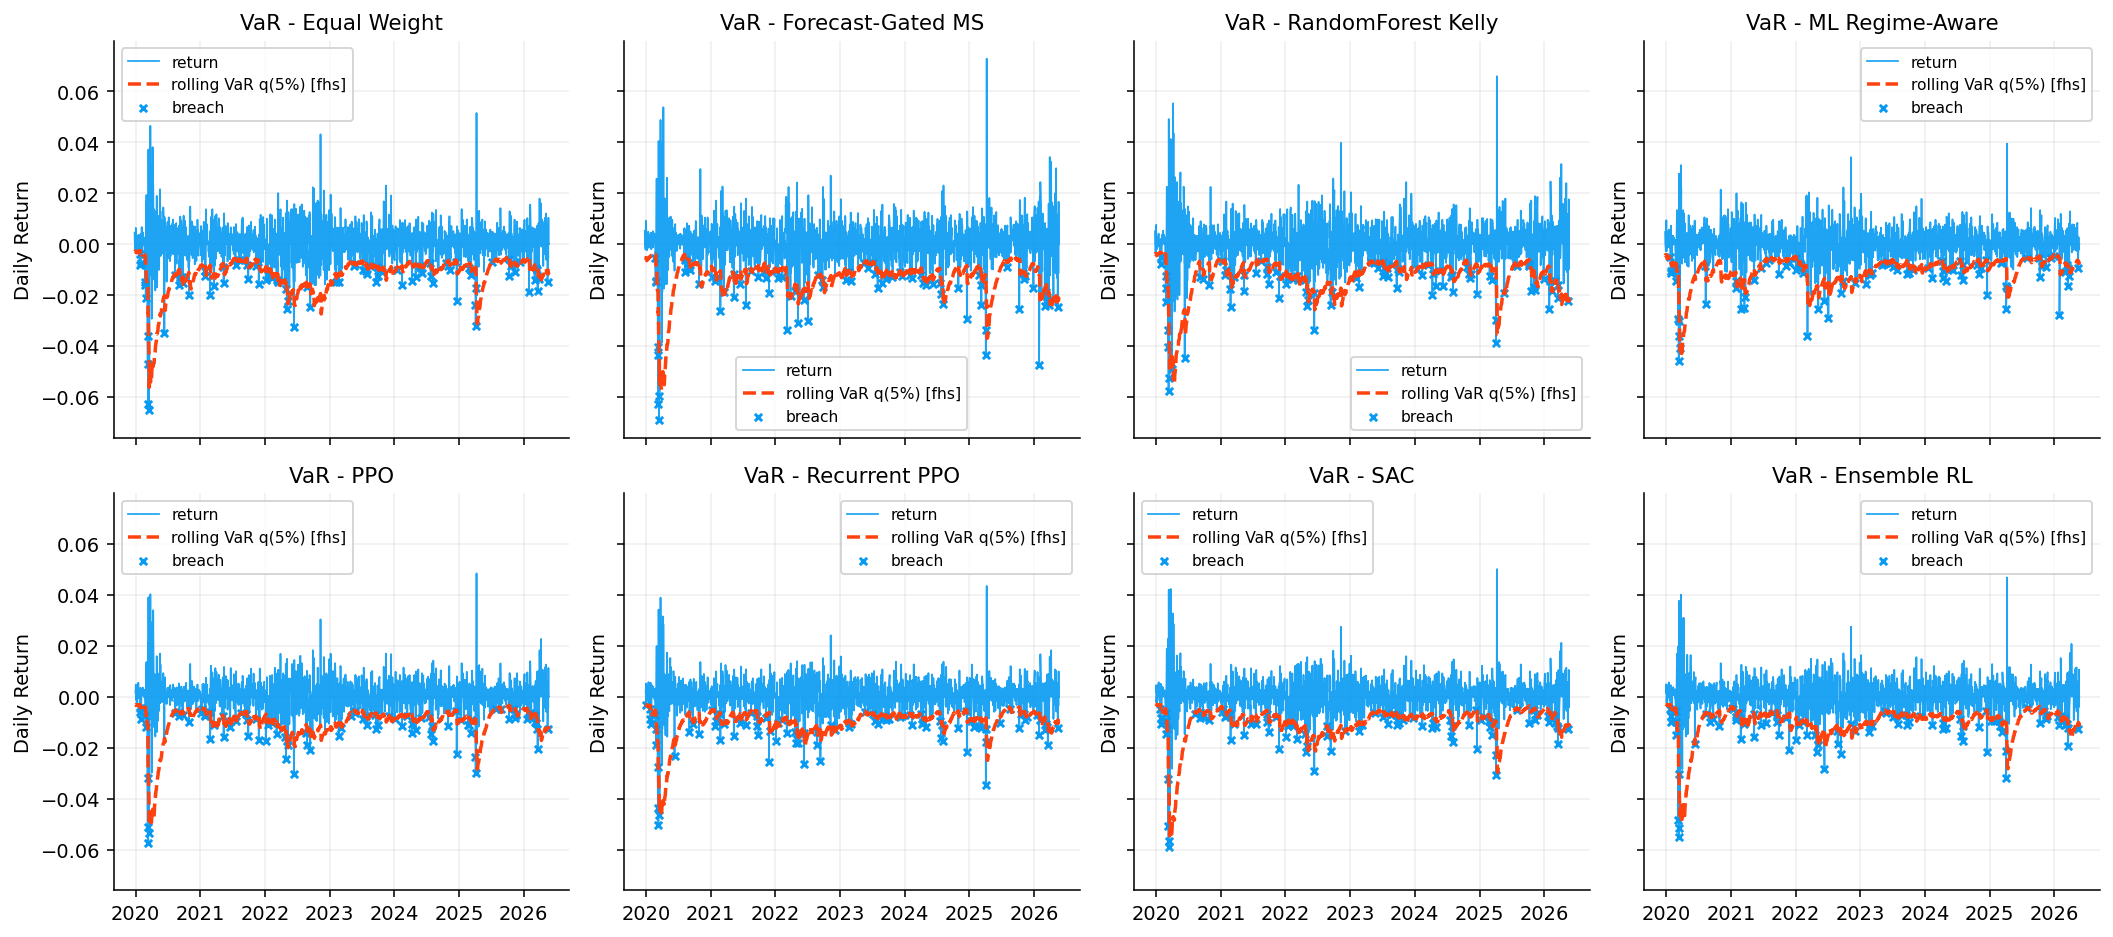

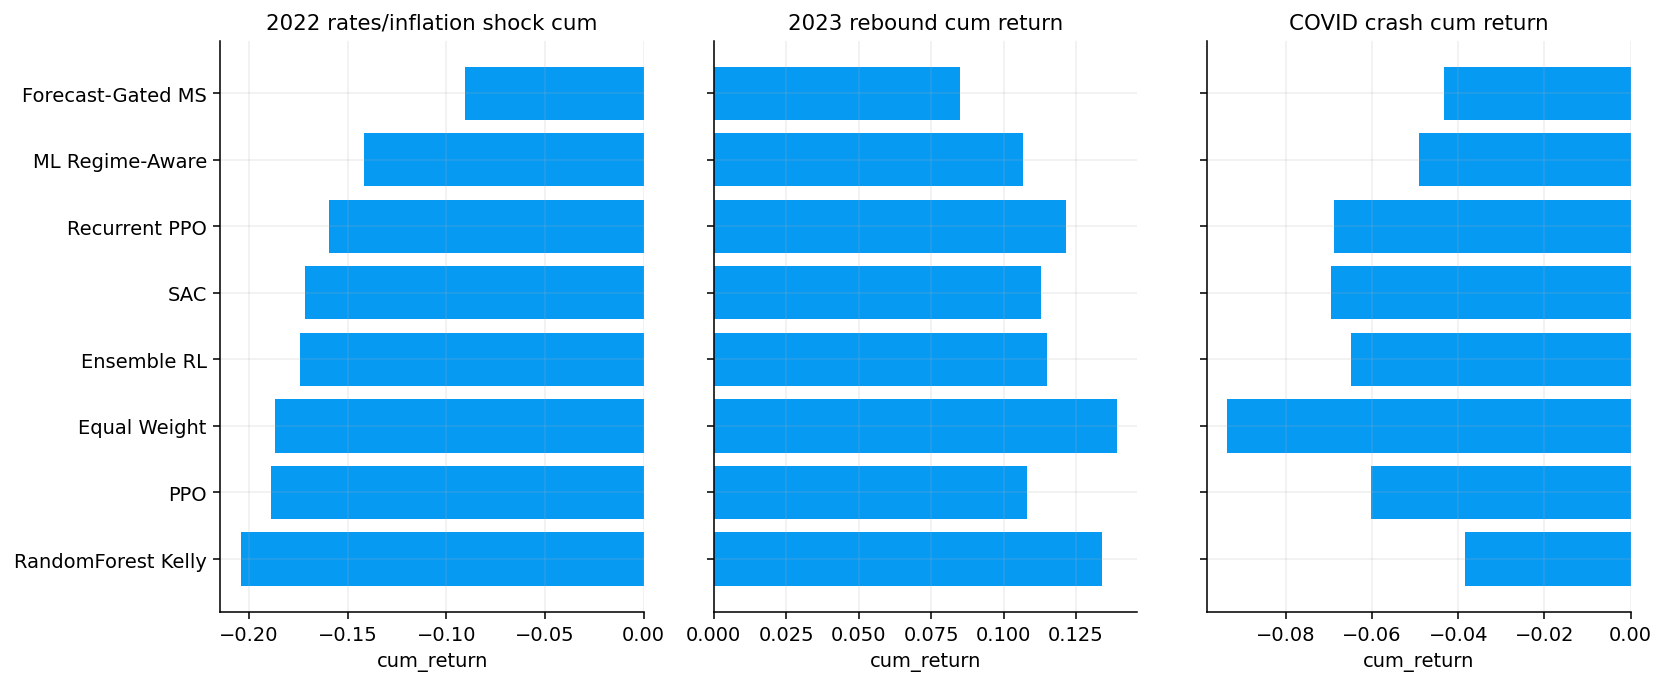

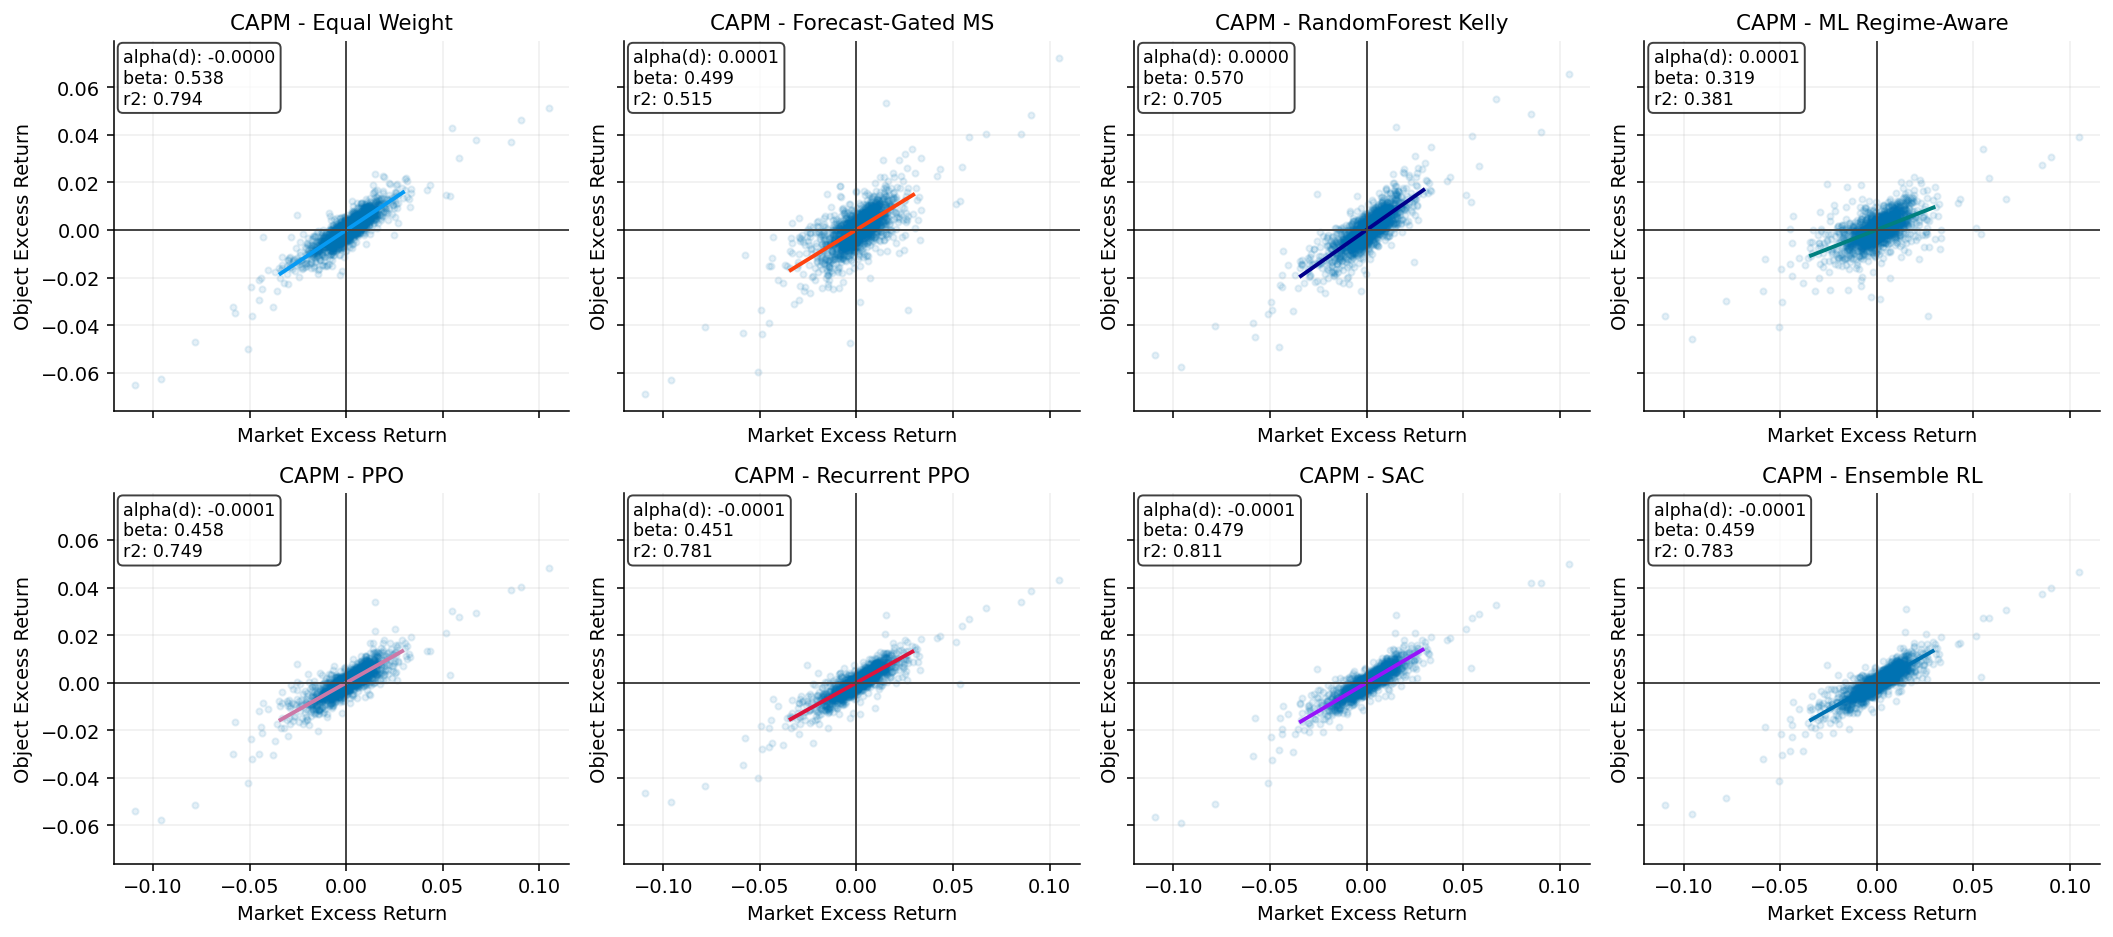

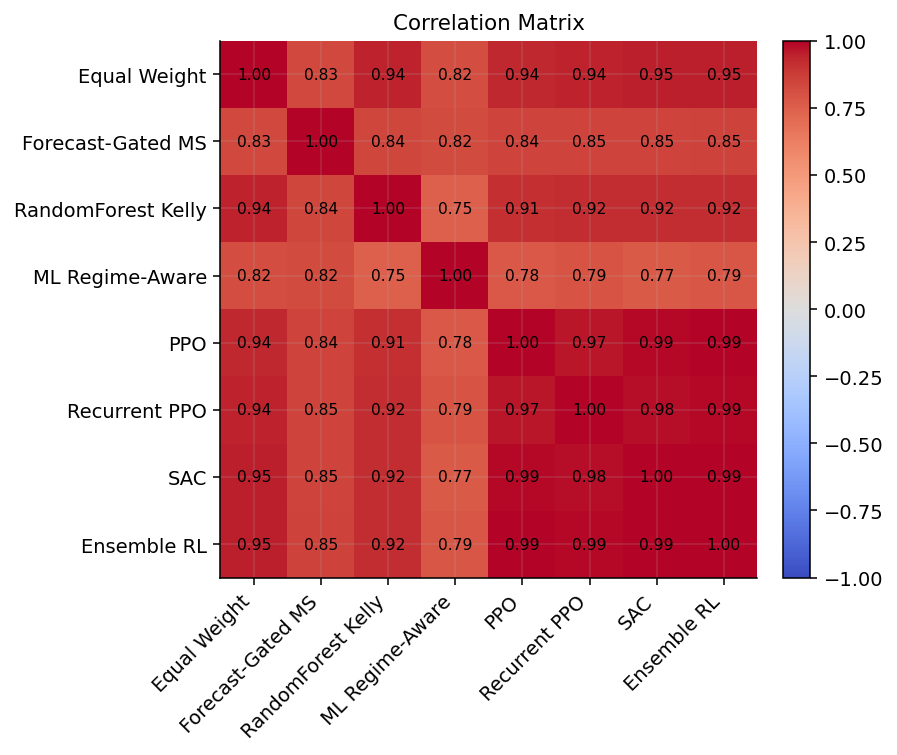

In [50]:
risk_objects = {name: strategy_returns[name].dropna() for name in strategy_returns.columns}
market_ret = r_d[benchmark_ticker].reindex(strategy_returns.index).dropna()
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}
stress_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1]) and strategy_returns.index.max() >= pd.Timestamp(window[0])
}
risk_ncols = max(1, math.ceil(len(risk_objects) / 2))
risk = risk_report(
    objects=risk_objects,
    market_ret=market_ret,
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": False,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": stress_windows, "worst_only": False},
    layout={"ncols": risk_ncols},
    output={
        "display_tables": True,
        "show_figures": True,
        "display_table_keys": ["var_es", "var_backtest", "stress"],
        "round_tables": 4,
        "short_labels": False,
    },
)


In [51]:
final_result_summary = {
    "best_policy": best_policy_name,
    "checkpoint_dir": str(model_dir),
    "best_policy_sharpe": float(final_summary.loc[best_policy_name, "Sharpe"]),
    "forecast_gated_maxsharpe_sharpe": float(final_summary.loc["Forecast-Gated MaxSharpe", "Sharpe"]),
    "best_policy_active_ir": float(active_table.loc[best_policy_name, "Information Ratio"]) if best_policy_name in active_table.index else np.nan,
    "best_policy_ablation_reward_drop_no_forecasts": float(ablation_table.loc["base", "total_reward"] - ablation_table.loc["no_forecasts", "total_reward"]),
}
display(pd.Series(final_result_summary).to_frame("value"))


,value
best_policy,Recurrent PPO
checkpoint_dir,e:\daneshgah\quantitative-finance-lab\models\p...
best_policy_sharpe,0.498842
forecast_gated_maxsharpe_sharpe,0.743261
best_policy_active_ir,-0.682391
best_policy_ablation_reward_drop_no_forecasts,8.9617


In [52]:
library_transition = pd.Series([
    "quantfinlab.ml.environment: state tables, action transform, policy weights",
    "quantfinlab.ml.rewards: reward components and reward tables",
    "quantfinlab.ml.policies: PPO, Recurrent PPO, SAC, twin Q networks",
    "quantfinlab.ml.rl: training, evaluation, validation tables",
    "quantfinlab.ml.evaluation: active, diagnostics, ablation, stress tables",
    "quantfinlab.plotting.ml / plotting.portfolio / plotting.diagrams: RL visuals",
], name="Project 20 reusable additions").to_frame()
display(library_transition)


,Project 20 reusable additions
0,"quantfinlab.ml.environment: state tables, acti..."
1,quantfinlab.ml.rewards: reward components and ...
2,"quantfinlab.ml.policies: PPO, Recurrent PPO, S..."
3,"quantfinlab.ml.rl: training, evaluation, valid..."
4,"quantfinlab.ml.evaluation: active, diagnostics..."
5,quantfinlab.plotting.ml / plotting.portfolio /...


,value
leaky_forecast_features_in_state,0
asset_features,58
global_features,41


,return,vol,sharpe,max_drawdown,total_reward,mean_reward,avg_exposure,checkpoint
Policy,,,,,,,,
PPO,0.1106,0.0951,0.1799,-0.1495,199.4486,1.9178,0.7859,e:\daneshgah\quantitative-finance-lab\models\p...
Recurrent PPO,0.1095,0.0815,0.1895,-0.1193,204.4680,1.9660,0.6770,e:\daneshgah\quantitative-finance-lab\models\p...
SAC,0.1393,0.0890,0.3282,-0.1223,236.1884,2.2710,0.8479,e:\daneshgah\quantitative-finance-lab\models\p...


,CAGR,Vol,Sharpe,Sortino,Max Drawdown,Turnover,Effective N
Strategy,,,,,,,
Forecast-Gated MaxSharpe,0.1836,0.1926,0.7683,0.9200,-0.3750,0.4264,3.1137
Equal Weight,0.1481,0.1834,0.6311,0.7448,-0.3669,0.0192,9.0000
ML Regime-Aware,0.1388,0.1696,0.6299,0.7524,-0.3182,0.1970,5.7746
HistGradientBoosting Kelly,0.1460,0.1930,0.5998,0.7184,-0.3900,0.4677,4.5246
SAC,0.1148,0.1423,0.5580,0.6604,-0.2946,0.1417,7.1331
Ensemble RL,0.1044,0.1407,0.4940,0.5696,-0.3115,0.1509,7.1151
PPO,0.0954,0.1566,0.4042,0.4612,-0.3518,0.2359,5.1328
Recurrent PPO,0.0865,0.1343,0.3880,0.4482,-0.3018,0.2111,4.7712


,Active CAGR,Tracking Error,Information Ratio,Active Max Drawdown,Monthly Active Hit Rate,Mean Daily Active
Strategy,,,,,,
Equal Weight,-0.0322,0.0722,-0.4456,-0.2434,0.5169,-0.0001
HistGradientBoosting Kelly,-0.0322,0.0737,-0.4373,-0.2431,0.4382,-0.0001
ML Regime-Aware,-0.0411,0.0820,-0.5015,-0.3285,0.4270,-0.0002
PPO,-0.0829,0.0887,-0.9344,-0.4922,0.3820,-0.0003
Recurrent PPO,-0.0941,0.0926,-1.0157,-0.5230,0.3596,-0.0004
SAC,-0.0668,0.0870,-0.7678,-0.4180,0.3708,-0.0003
Ensemble RL,-0.0767,0.0834,-0.9192,-0.4518,0.3371,-0.0003


,Avg Risky Exposure,Avg Cash Weight,Avg Turnover,Annualized Turnover,Cost Drag Estimate,Avg HHI,Effective N,Avg Max Weight
Strategy,,,,,,,,
PPO,0.7834,0.2166,0.2324,12.0873,0.0121,0.1488,6.7188,0.2998
Recurrent PPO,0.6799,0.3201,0.2079,10.8118,0.0108,0.1073,9.3239,0.2511
SAC,0.8472,0.1528,0.1412,7.3442,0.0073,0.1196,8.3615,0.2232


return     vol  sharpe  max_drawdown  \
Policy        Ablation                                                   
PPO           base                0.9579  0.1566  0.4006       -0.3519   
              no_forecasts        1.3242  0.1454  0.5768       -0.3034   
              no_priors           0.9761  0.1566  0.4085       -0.3504   
              shuffled_forecasts  1.2691  0.1414  0.5661       -0.2545   
Recurrent PPO base                0.8567  0.1344  0.3897       -0.3020   
              no_forecasts        1.1456  0.1256  0.5613       -0.2589   
              no_priors           0.8576  0.1340  0.3908       -0.3016   
              shuffled_forecasts  1.1236  0.1241  0.5554       -0.2204   
SAC           base                1.1668  0.1431  0.5184       -0.2971   
              no_forecasts        1.1188  0.1408  0.5031       -0.2917   
              no_priors           1.2437  0.1430  0.5512       -0.2966   
              shuffled_forecasts  1.4070  0.1432  0.6159       -0.2753   

                                  total_reward  mean_reward  avg_exposure  
Policy        Ablation                                                     
PPO           base                   -335.1777      -0.8706        0.7834  
              no_forecasts           -401.0457      -1.0417        0.7803  
              no_priors              -335.6423      -0.8718        0.7833  
              shuffled_forecasts     -365.4491      -0.9492        0.7846  
Recurrent PPO base                   -304.5494      -0.7910        0.6803  
              no_forecasts           -415.1291      -1.0783        0.6830  
              no_priors              -302.3553      -0.7853        0.6809  
              shuffled_forecasts     -366.3959      -0.9517        0.6867  
SAC           base                   -194.9957      -0.5065        0.8473  
              no_forecasts            -91.6143      -0.2380        0.8530  
              no_priors              -155.2171      -0.4032        0.8472  
              shuffled_forecasts     -361.7944      -0.9397        0.8484

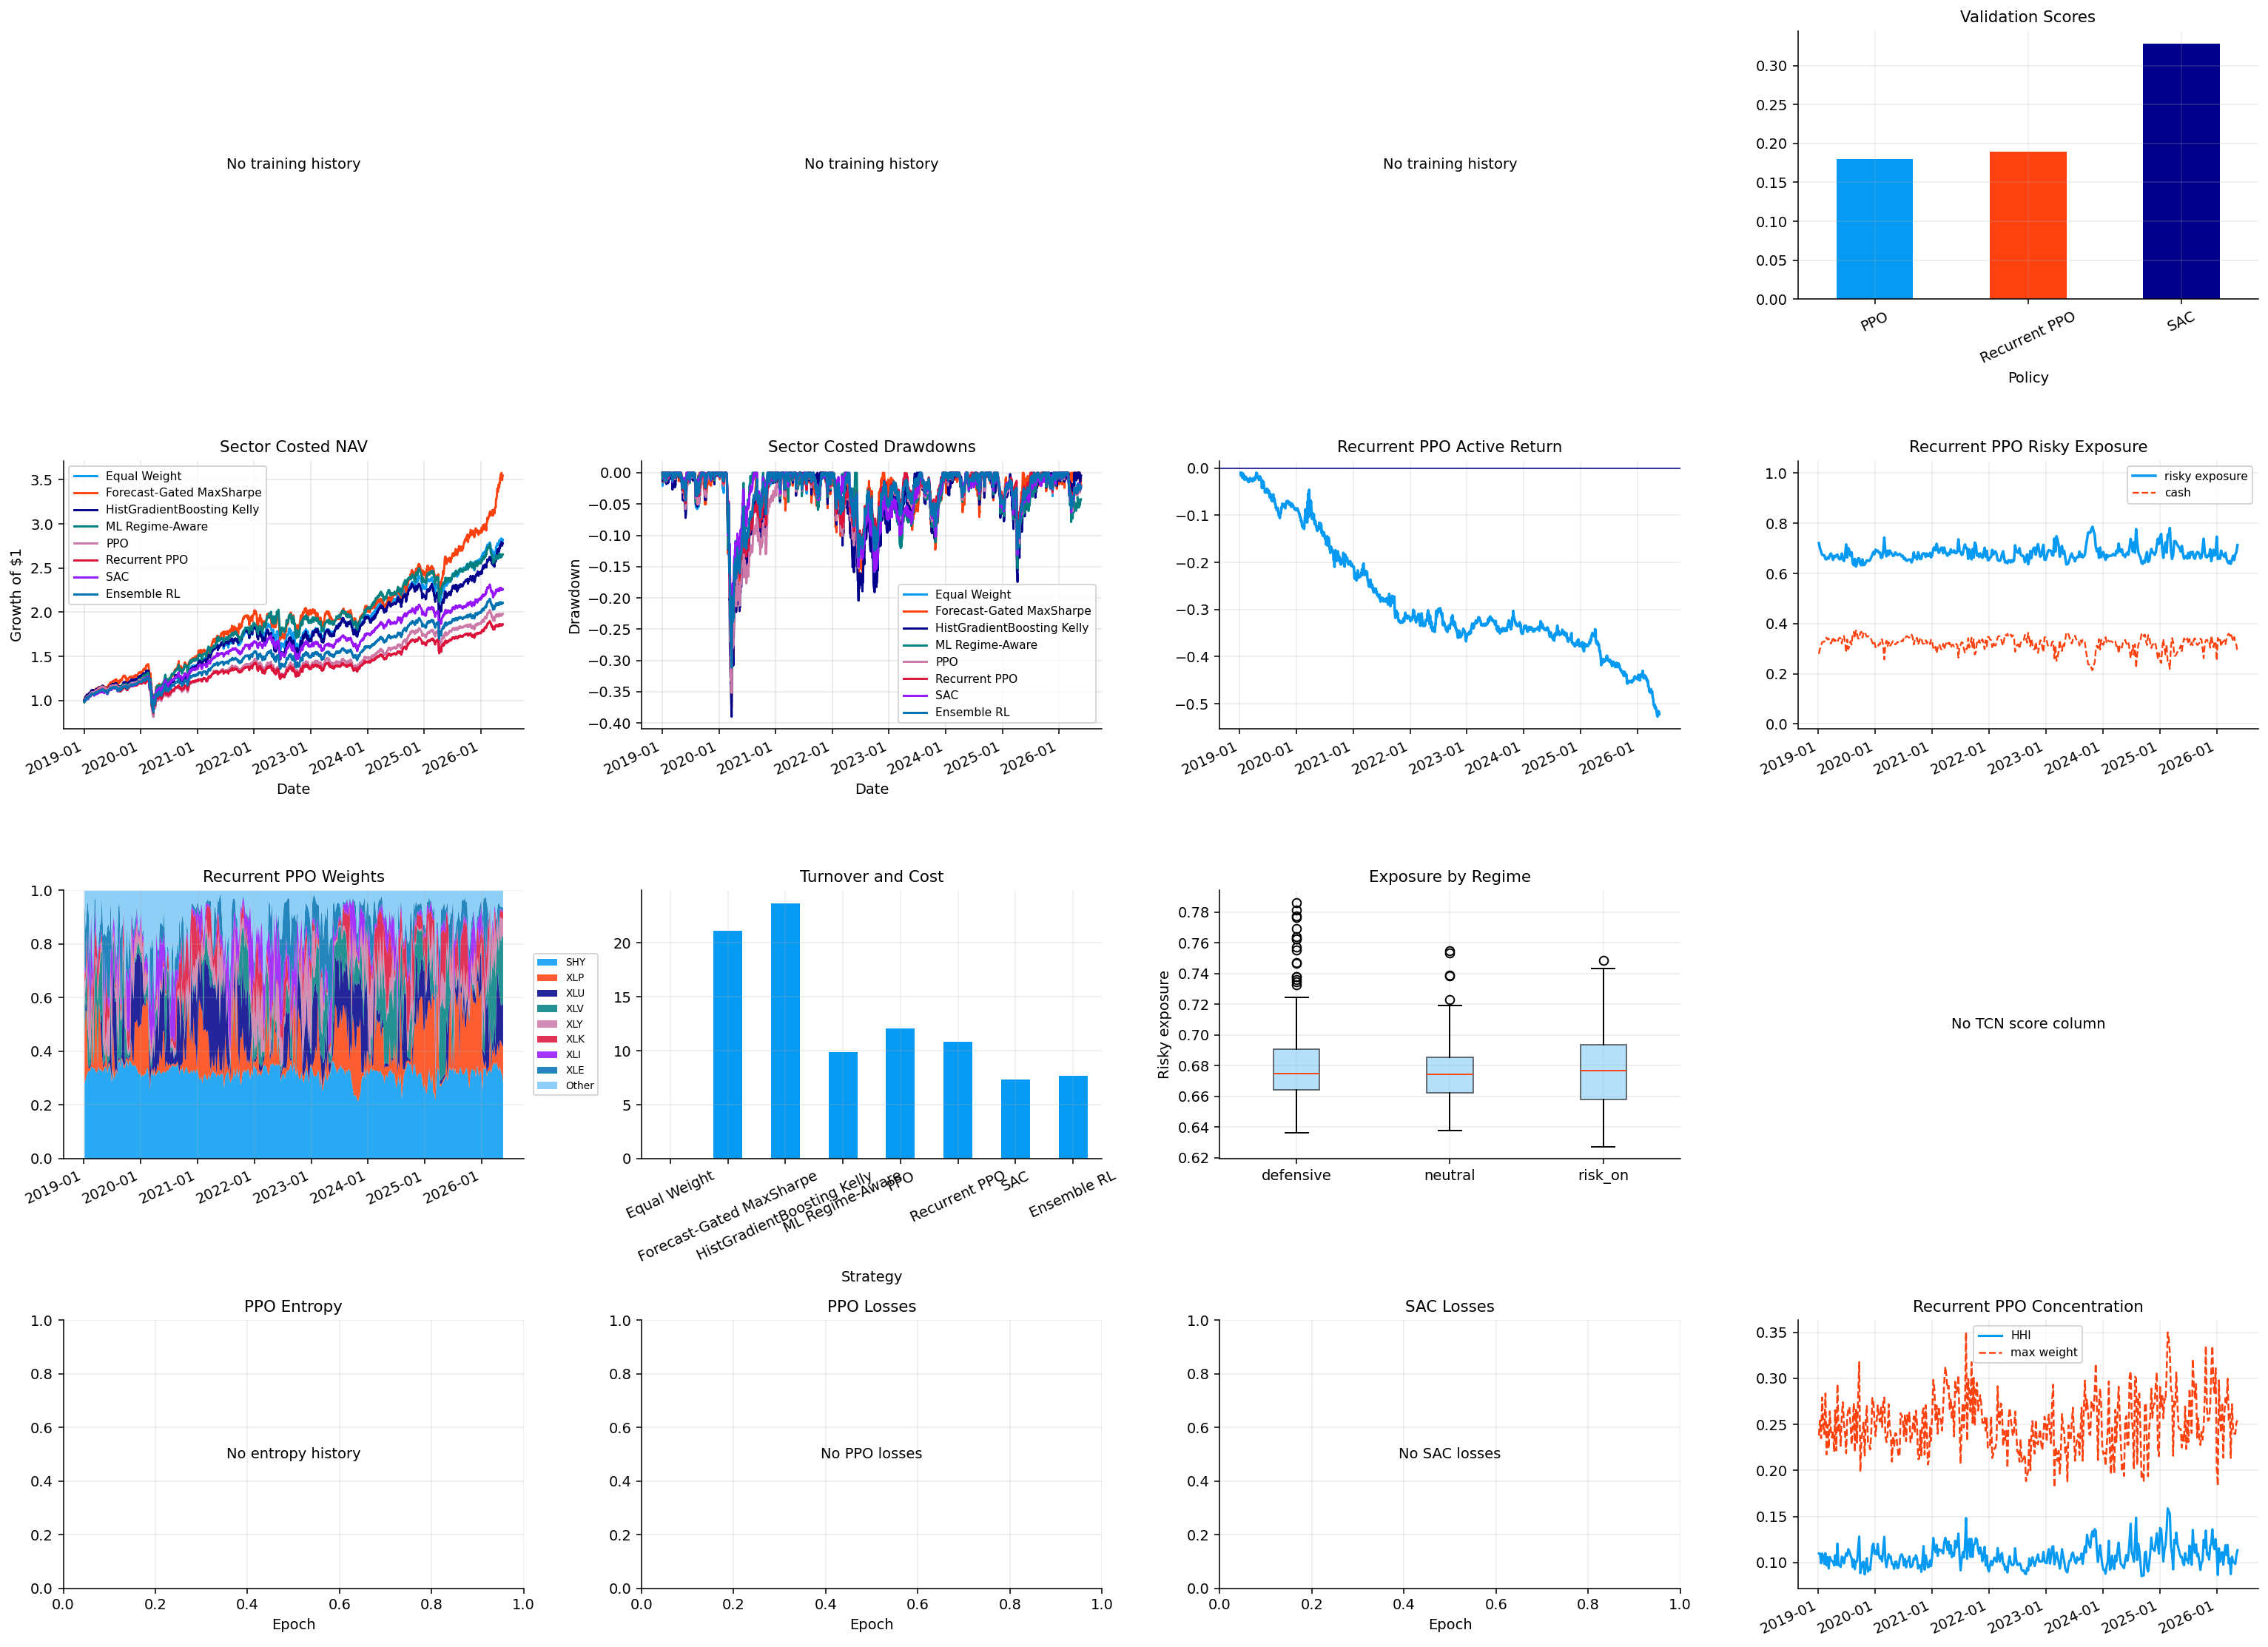

,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Ensemble RL,0.0118,0.0209,0.0121,0.0493,0.0087,0.0126
Equal Weight,0.0151,0.0273,0.0158,0.0575,0.0103,0.0150
Forecast-Gated MaxSharpe,0.0167,0.0283,0.0165,0.0593,0.0146,0.0212
HistGradientBoosting Kelly,0.0163,0.0285,0.0166,0.0598,0.0123,0.0174
ML Regime-Aware,0.0142,0.0251,0.0139,0.0558,0.0097,0.0147
PPO,0.0133,0.0233,0.0139,0.0582,0.0091,0.0136
Recurrent PPO,0.0115,0.0198,0.0116,0.0489,0.0076,0.0115
SAC,0.0117,0.0212,0.0120,0.0466,0.0091,0.0138


breach_count  breach_rate  coverage_error  \
object                     method                                              
Ensemble RL                cf                85       0.0519          0.0019   
                           fhs               93       0.0568          0.0068   
                           hist              89       0.0543          0.0043   
Equal Weight               cf                90       0.0548          0.0048   
                           fhs               92       0.0561          0.0061   
                           hist              87       0.0530          0.0030   
Forecast-Gated MaxSharpe   cf                86       0.0524          0.0024   
                           fhs               86       0.0524          0.0024   
                           hist              85       0.0518          0.0018   
HistGradientBoosting Kelly cf                90       0.0548          0.0048   
                           fhs               92       0.0561          0.0061   
                           hist              88       0.0536          0.0036   
ML Regime-Aware            cf                73       0.0445         -0.0055   
                           fhs               89       0.0542          0.0042   
                           hist              83       0.0506          0.0006   
PPO                        cf                90       0.0549          0.0049   
                           fhs               88       0.0537          0.0037   
                           hist              88       0.0537          0.0037   
Recurrent PPO              cf                88       0.0537          0.0037   
                           fhs               93       0.0568          0.0068   
                           hist              87       0.0531          0.0031   
SAC                        cf                81       0.0495         -0.0005   
                           fhs               90       0.0549          0.0049   
                           hist              92       0.0562          0.0062   

                                   abs_coverage_error  longest_breach_streak  \
object                     method                                              
Ensemble RL                cf                  0.0019                      3   
                           fhs                 0.0068                      2   
                           hist                0.0043                      3   
Equal Weight               cf                  0.0048                      3   
                           fhs                 0.0061                      2   
                           hist                0.0030                      3   
Forecast-Gated MaxSharpe   cf                  0.0024                      3   
                           fhs                 0.0024                      3   
                           hist                0.0018                      3   
HistGradientBoosting Kelly cf                  0.0048                      3   
                           fhs                 0.0061                      2   
                           hist                0.0036                      3   
ML Regime-Aware            cf                  0.0055                      3   
                           fhs                 0.0042                      2   
                           hist                0.0006                      3   
PPO                        cf                  0.0049                      3   
                           fhs                 0.0037                      2   
                           hist                0.0037                      3   
Recurrent PPO              cf                  0.0037                      3   
                           fhs                 0.0068                      2   
                           hist                0.0031                      3   
SAC                        cf                  0.0005                      3   
                           fhs    

,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 rates/inflation shock,Ensemble RL,-0.0411,-0.1343,-0.0323,-0.0643
2022 rates/inflation shock,Equal Weight,-0.0620,-0.1703,-0.0378,-0.0743
2022 rates/inflation shock,Forecast-Gated MaxSharpe,-0.0114,-0.1633,-0.0420,-0.0998
2022 rates/inflation shock,HistGradientBoosting Kelly,-0.0841,-0.2042,-0.0386,-0.0781
2022 rates/inflation shock,ML Regime-Aware,0.0028,-0.1590,-0.0418,-0.1089
2022 rates/inflation shock,PPO,-0.0439,-0.1525,-0.0320,-0.0515
2022 rates/inflation shock,Recurrent PPO,-0.0380,-0.1279,-0.0266,-0.0437
2022 rates/inflation shock,SAC,-0.0459,-0.1579,-0.0364,-0.0847
2023 rebound,Ensemble RL,0.0760,-0.0861,-0.0143,-0.0386


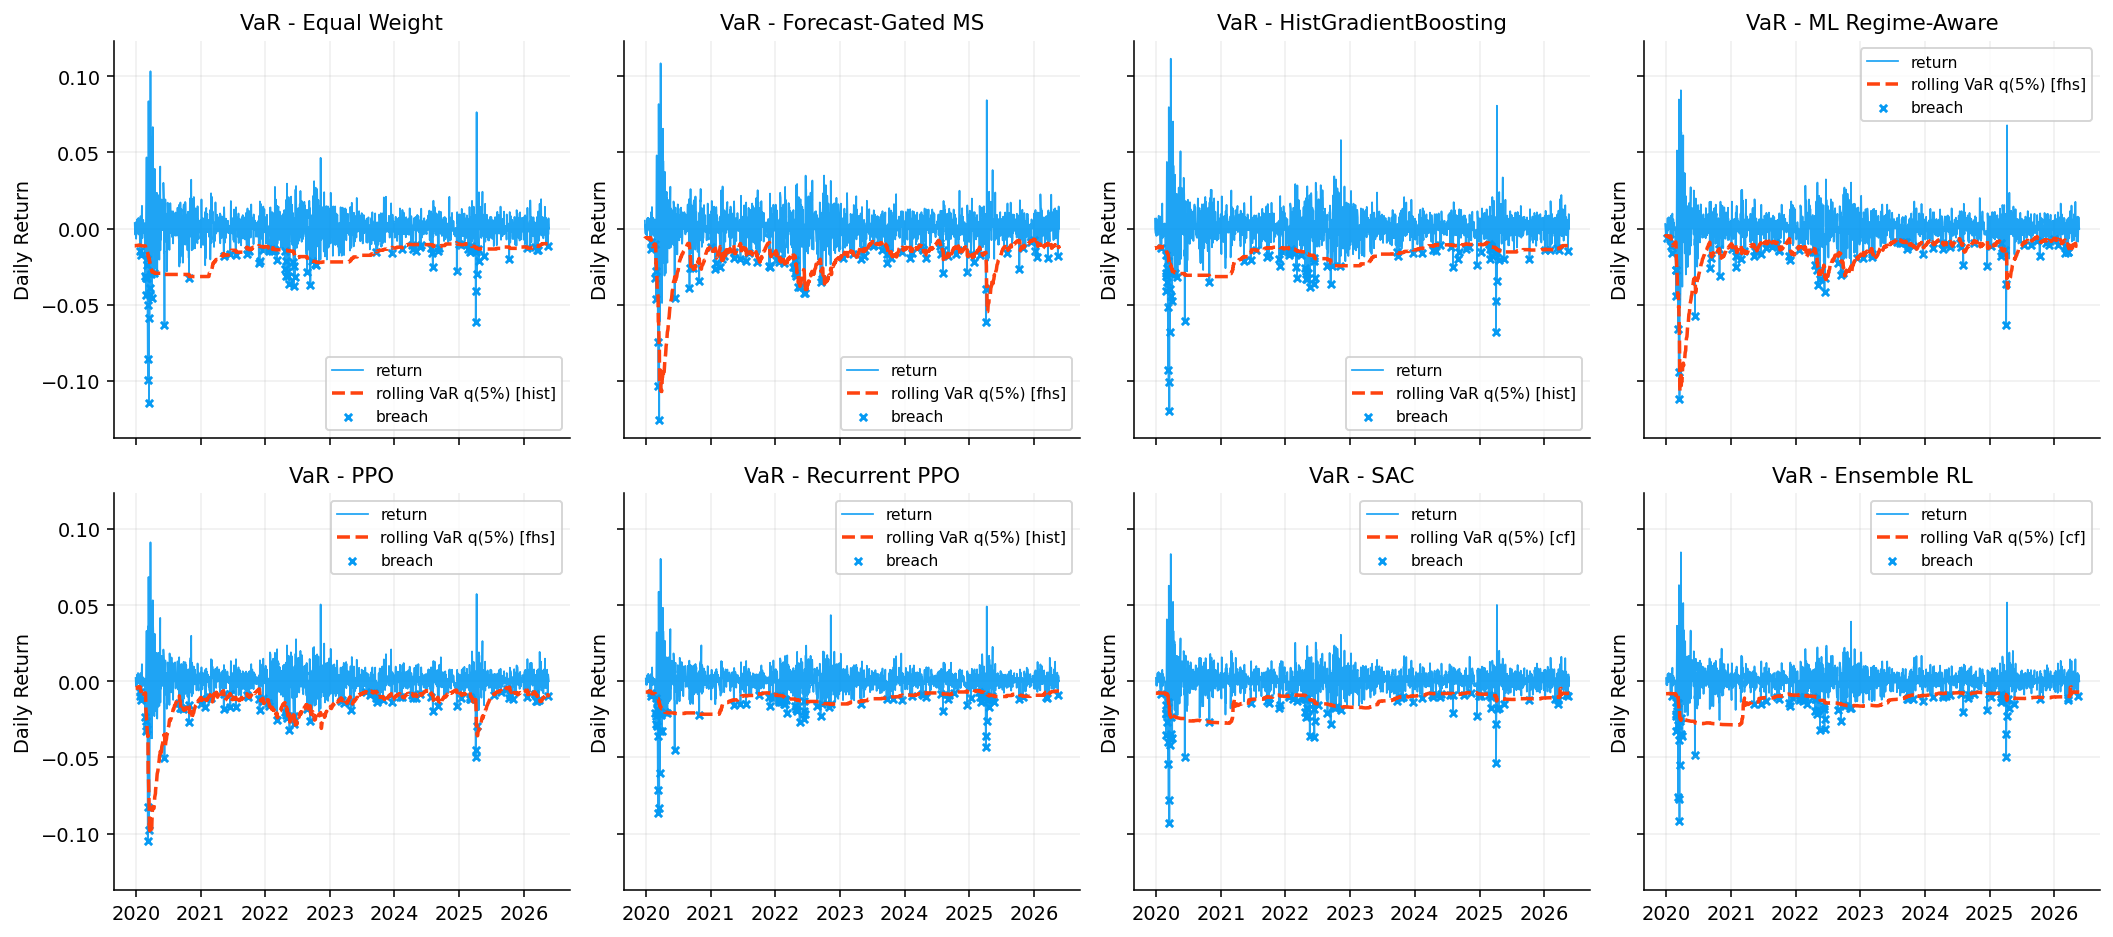

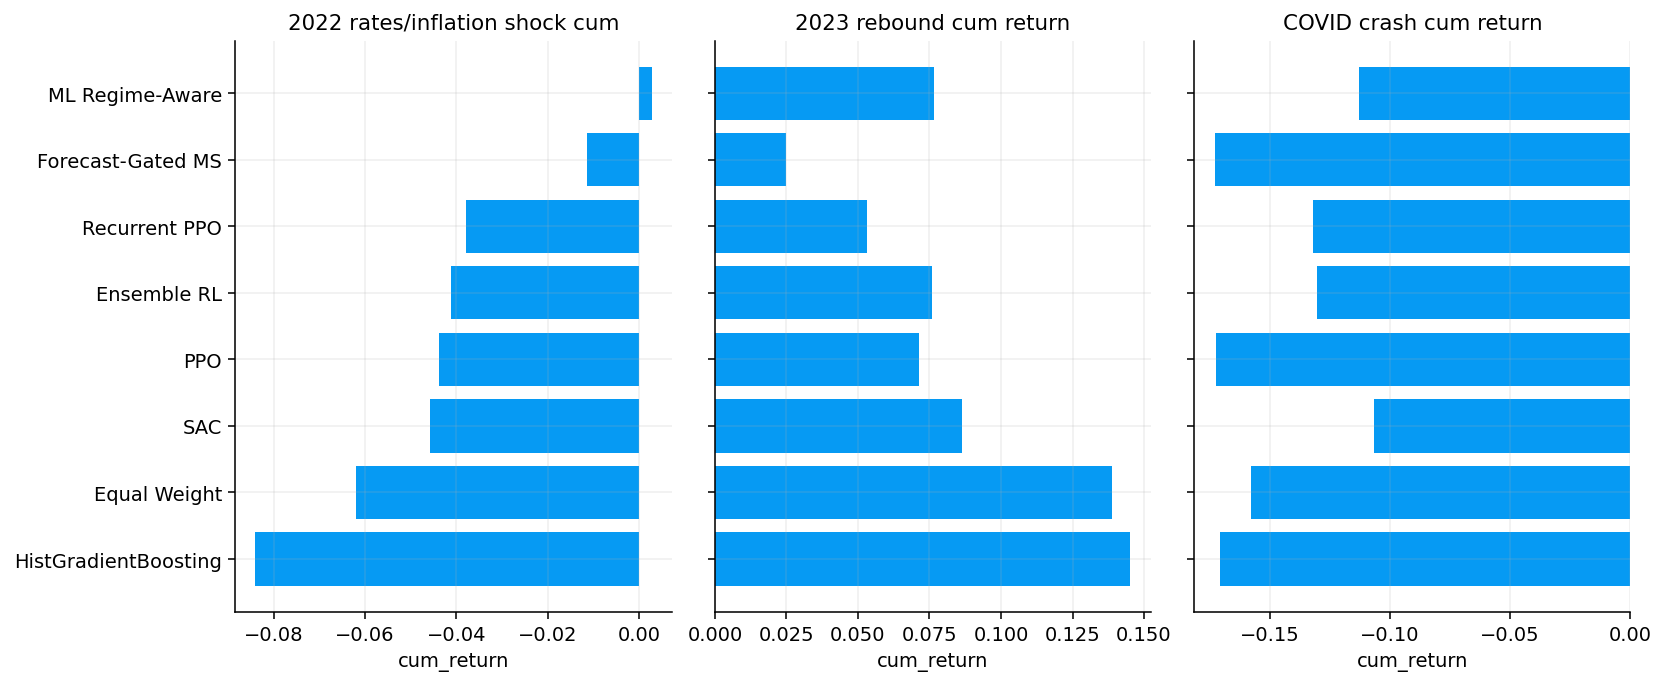

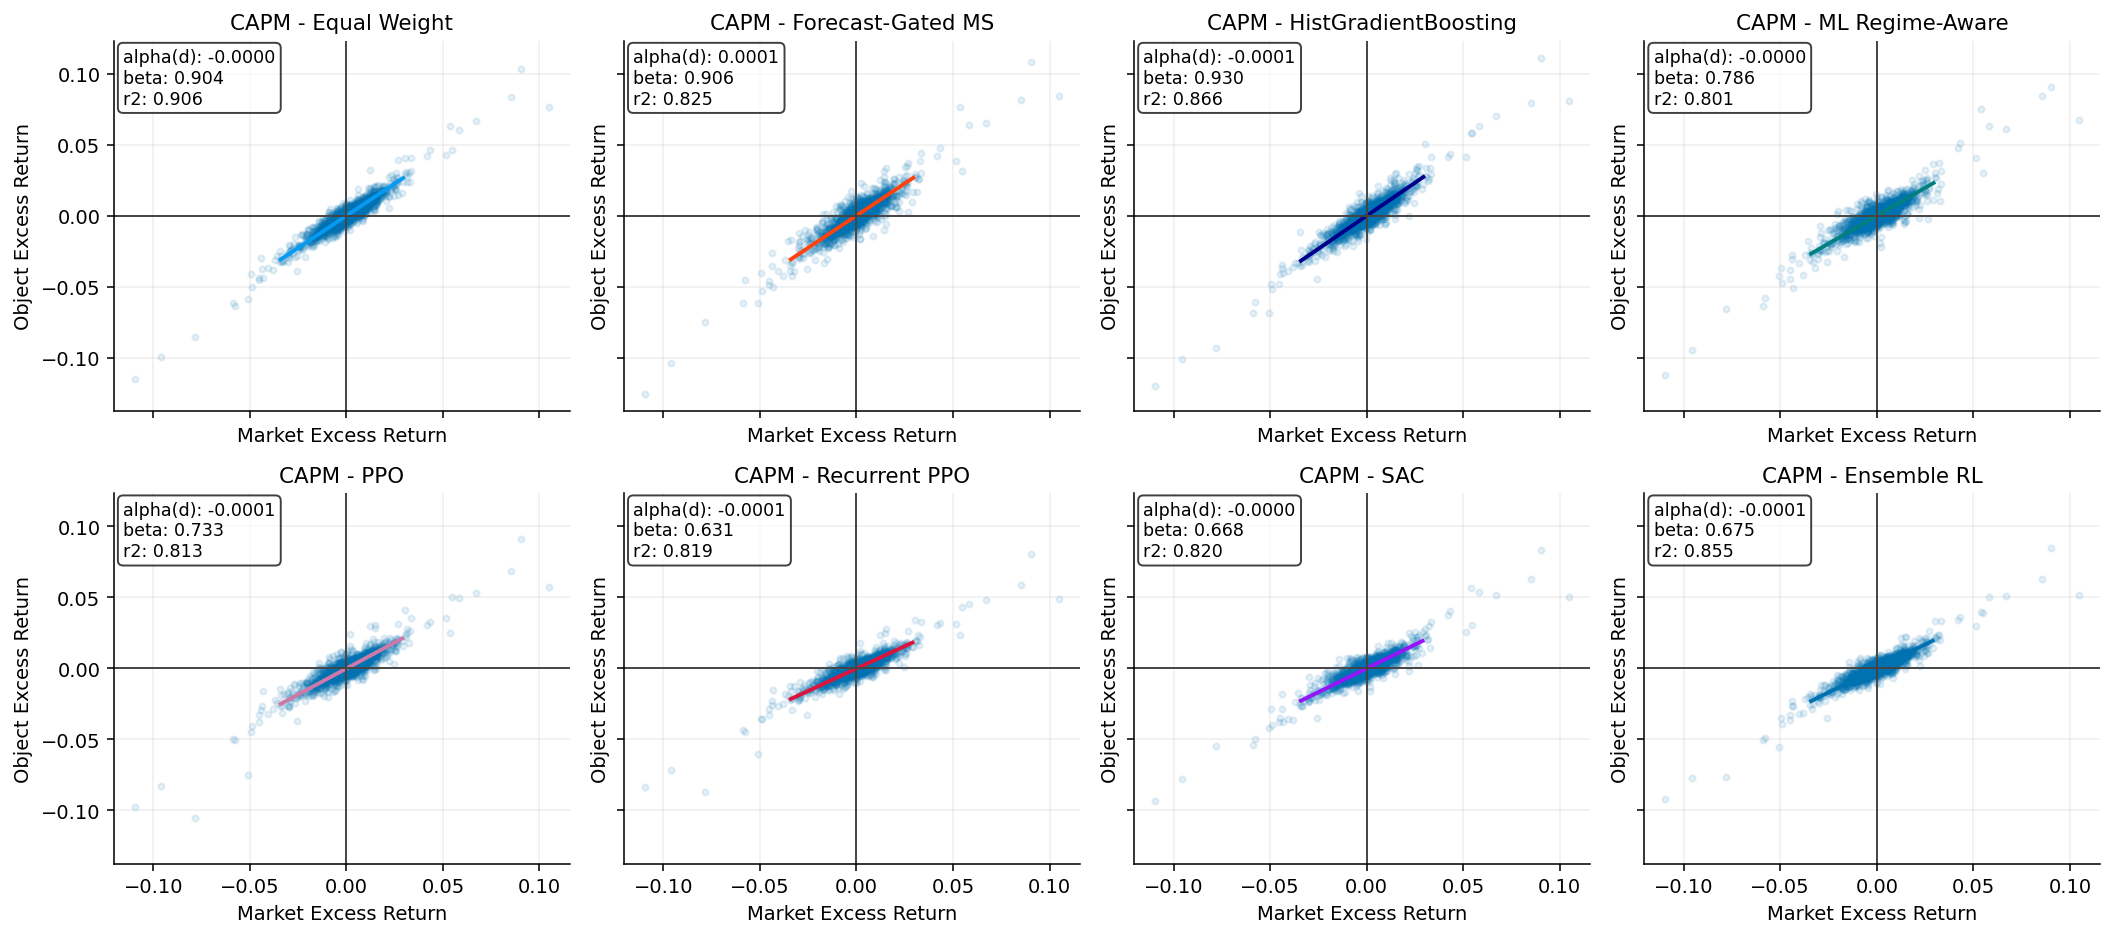

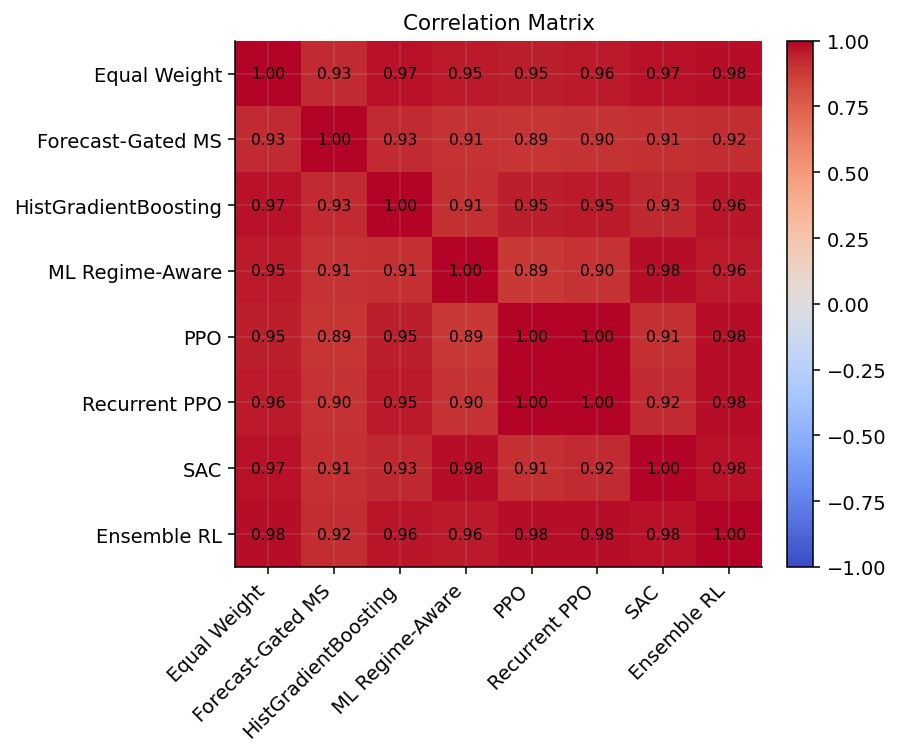

In [53]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_nfci, load_vix, load_yfinance_panel, prices_to_returns_panel, vix_feature_frame
from quantfinlab.ml.environment import align_weight_priors, blend_policy_weights, build_state_tables, make_decision_dates, policy_weight_frame
from quantfinlab.ml.evaluation import active_performance_table, ablation_table, policy_diagnostics_table, walkforward_tabular_predictions
from quantfinlab.ml.features import assemble_forecasting_table, build_asset_feature_block, build_cross_asset_feature_block, build_fci_feature_block, clean_feature_columns, regime_probability_features, trim_feature_table_by_availability
from quantfinlab.ml.policies import PpoPolicy, RecurrentPpoPolicy, SacPolicy
from quantfinlab.ml.rl import train_ppo, train_recurrent_ppo, train_sac, validation_policy_table
from quantfinlab.plotting.ml import policy_entropy_curve, ppo_loss_curves, q_value_curve, sac_loss_curves, training_reward_curve, validation_score_curve
from quantfinlab.plotting.portfolio import active_return_curve, concentration_path, forecast_policy_sensitivity, plot_strategy_drawdowns, plot_strategy_nav, policy_exposure_path, policy_weight_area, regime_exposure_boxplot, turnover_cost_curve
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import covariance, expected_returns, optimizers, views as bl_views
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary
from quantfinlab.portfolio.sizing import forecast_gated_maxsharpe_weight_frame, forecast_kelly_weight_frame
from quantfinlab.portfolio.universe import make_rebalance_dates
from quantfinlab.reports.risk_report import risk_report

model_dir = repo_root / "models" / "project20_sector_strong"
model_dir.mkdir(parents=True, exist_ok=True)
assets = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
signal_assets = ["SPY", "QQQ", "IWM", "TLT", "IEF", "SHY", "LQD", "HYG", "GLD", "DBC", "UUP"]
all_tickers = list(dict.fromkeys(assets + signal_assets + [cash_ticker, benchmark_ticker]))
sector_data_paths = [repo_root / "data" / "sector_etfs.csv", repo_root / "data" / "core_cross_asset_etfs.csv"]
panels = load_yfinance_panel(sector_data_paths, fields=("close", "volume"), tickers=all_tickers, source="yfinance_export", start="2007-01-01")
close_s = panels["close"].sort_index().ffill(limit=3)
volume_s = panels["volume"].sort_index().ffill(limit=3).reindex(close_s.index)
first_valid = close_s[assets + [cash_ticker]].dropna(how="any").index.min()
close_s = close_s.loc[first_valid:].copy()
volume_s = volume_s.reindex(close_s.index).copy()
r_s = prices_to_returns_panel(close_s, kind="simple").replace([np.inf, -np.inf], np.nan).fillna(0.0)
decision_dates = make_decision_dates(r_s.index, freq="W-FRI", min_history_days=756)
monthly_dates = make_rebalance_dates(r_s.index, freq="ME", min_history_days=756)

horizon = 21
vol_lookback = 63
r_log = np.log(close_s[assets] / close_s[assets].shift(1))
fwd = np.log(close_s[assets].shift(-horizon) / close_s[assets])
sigma_21 = r_log.rolling(vol_lookback, min_periods=vol_lookback).std(ddof=1) * np.sqrt(horizon)
z_21 = ((fwd - horizon * np.log1p(rf_daily)) / sigma_21.replace(0.0, np.nan)).clip(-4.0, 4.0)
y_alpha = z_21.sub(z_21.median(axis=1), axis=0).clip(-4.0, 4.0)
target = (
    pd.concat({"sigma_21": sigma_21, "z_21": z_21, "y_alpha": y_alpha}, axis=1)
    .stack(level=1)
    .rename_axis(["date", "asset"])
    .reset_index()
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["sigma_21", "z_21", "y_alpha"])
)
counts = target.groupby("date")["asset"].nunique()
target = target[target["date"].isin(counts[counts.eq(len(assets))].index)].copy()
asset_features_model = build_asset_feature_block(close_s, volume_s, r_s, assets=assets, rf_daily=rf_daily)
context_features_model = build_cross_asset_feature_block(close_s, r_s, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
fci_features_model = build_fci_feature_block(macro_factors, nfci, index=close_s.index)
regime_features_model = regime_probability_features(close_s, r_s, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker, model="GradientBoosting", horizon=horizon, rebalance_dates=decision_dates, output="features", n_jobs=4)
regime_features_model = regime_features_model.reindex(close_s.index.union(regime_features_model.index)).sort_index().ffill().reindex(close_s.index)
data = assemble_forecasting_table(target, asset_features_model, context_features_model, fci_features_model, regime_features_model)
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["y_alpha", "z_21", "sigma_21"])
data = data[data["asset"].isin(assets)].sort_values(["date", "asset"]).reset_index(drop=True)
full_dates = data.groupby("date")["asset"].nunique()
data = data[data["date"].isin(full_dates[full_dates.eq(len(assets))].index)].copy()
feature_cols = [c for c in data.columns if c not in {"date", "asset", "y_alpha", "z_21", "sigma_21"}]
stage1 = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
data, first_model_date, feature_availability = trim_feature_table_by_availability(
    data,
    stage1,
    target_cols=["y_alpha", "sigma_21"],
    min_feature_coverage=0.75,
    min_asset_count=len(assets),
    min_target_complete=1.0,
)
features = clean_feature_columns(data, feature_cols, max_missing=0.30, max_abs_corr=0.985)
for col in features:
    data[col] = data.groupby("asset", sort=False)[col].transform(lambda s: s.ffill())
data[features] = data[features].fillna(data.loc[data["date"] <= pd.Timestamp("2017-12-31"), features].median()).fillna(0.0)
prediction_dates = pd.DatetimeIndex(pd.to_datetime(data.loc[data["date"] >= pd.Timestamp("2008-01-01"), "date"].drop_duplicates())).sort_values()
refit_dates = pd.DatetimeIndex(pd.Series(prediction_dates, index=prediction_dates).groupby(prediction_dates.to_period("Q")).first().to_list())
sector_forecast_cache = model_dir / "sector_hgb_forecast_v1.pkl"
sector_forecast_cols = {"date", "asset", "sigma_21", "z_hgb", "z_hgb_rank", "hgb_confidence", "mu_hat", "width", "c_width", "c_model", "c_total"}
forecast_x = pd.read_pickle(sector_forecast_cache) if sector_forecast_cache.exists() else pd.DataFrame()
if not (not forecast_x.empty and sector_forecast_cols.issubset(set(forecast_x.columns)) and pd.to_datetime(forecast_x["date"]).min() <= prediction_dates.min()):
    tab_predictions = walkforward_tabular_predictions(
        data[features],
        data["y_alpha"],
        pd.to_datetime(data["date"]),
        data["asset"],
        refit_dates=refit_dates,
        prediction_dates=prediction_dates,
        estimators={
            "z_hgb": HistGradientBoostingRegressor(loss="squared_error", max_iter=650, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
            "q10_hgb": HistGradientBoostingRegressor(loss="quantile", quantile=0.10, max_iter=550, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
            "q50_hgb": HistGradientBoostingRegressor(loss="quantile", quantile=0.50, max_iter=550, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
            "q90_hgb": HistGradientBoostingRegressor(loss="quantile", quantile=0.90, max_iter=550, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
        },
        train_window=252 * 6,
        horizon=horizon,
        n_jobs=4,
        inner_threads=1,
        min_train=500,
    )
    forecast_x = data[["date", "asset", "sigma_21", "z_21", "y_alpha"]].merge(tab_predictions, on=["date", "asset"], how="left")
    forecast_x["z_hgb_rank"] = forecast_x.groupby("date")["z_hgb"].rank(pct=True) - 0.5
    scale = forecast_x.groupby("date")["z_hgb"].transform(lambda s: s.abs().median())
    forecast_x["hgb_confidence"] = forecast_x["z_hgb"].abs().div(scale.replace(0.0, np.nan)).clip(0.0, 3.0).fillna(0.0) / 3.0
    forecast_x["mu_hat"] = forecast_x["z_hgb"] * forecast_x["sigma_21"]
    forecast_x["width"] = (forecast_x["q90_hgb"] - forecast_x["q10_hgb"]).abs() * forecast_x["sigma_21"]
    forecast_x["c_width"] = forecast_x["mu_hat"].abs().div(forecast_x["mu_hat"].abs() + forecast_x["width"].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0.75).clip(0.50, 1.0)
    forecast_x["c_model"] = (0.50 + 0.50 * forecast_x["hgb_confidence"]).clip(0.50, 1.0)
    forecast_x["c_total"] = (0.50 + 0.50 * (0.70 * forecast_x["c_width"] + 0.30 * forecast_x["c_model"])).clip(0.50, 1.0)
    forecast_x = forecast_x.dropna(subset=["z_hgb"]).sort_values(["date", "asset"]).reset_index(drop=True)
    forecast_x.to_pickle(sector_forecast_cache)
forecast_x["_hvs"] = forecast_x["z_hgb"] / forecast_x["sigma_21"].replace(0.0, np.nan)
forecast_x["z_hgb_volscaled"] = (forecast_x.groupby("date")["_hvs"].rank(pct=True) - 0.5).fillna(0.0)
forecast_x = forecast_x.drop(columns=["_hvs"])
forecast_state_x = forecast_x.drop(columns=["z_21", "y_alpha"], errors="ignore")
forecast_dates = set(pd.to_datetime(forecast_x["date"]))
returns_sector = r_s[assets + [cash_ticker]]
validation_dates = pd.DatetimeIndex([d for d in monthly_dates if pd.Timestamp("2017-01-01") <= d <= pd.Timestamp("2018-12-31") and d in forecast_dates])
weight_dates = pd.DatetimeIndex([d for d in monthly_dates if pd.Timestamp("2013-01-01") <= d and d in forecast_dates])
lambda_rows = []
for lam in [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50]:
    W_lam = forecast_gated_maxsharpe_weight_frame(forecast_x, alpha_col="z_hgb", returns=returns_sector, rebalance_dates=validation_dates, sigma_col="sigma_21", alpha_is_z=True, width_col="width", confidence_cols=["c_width", "c_model", "c_total"], lambda_alpha=lam, assets=assets + [cash_ticker], cash_asset=cash_ticker, prior_model="bayes_stein", max_weight=0.35, turnover_penalty_bps=cost_bps, rf_daily=rf_daily)
    if W_lam.empty:
        continue
    bt_lam = run_many_weights_backtests({f"lambda={lam:.2f}": W_lam}, returns=returns_sector, cost_bps=cost_bps, rf_daily=rf_daily, w_min=0.0, w_max=1.0, long_only=True, normalize=True, weight_timing="next_close")
    summary_lam = build_strategy_summary(bt_lam, rf_daily=rf_daily, annualization=annualization)
    lambda_rows.append({"lambda_alpha": lam, "Sharpe": float(summary_lam.iloc[0]["Sharpe"]) if len(summary_lam) else np.nan})
lambda_table = pd.DataFrame(lambda_rows)
lambda_alpha = float(lambda_table.sort_values("Sharpe", ascending=False).iloc[0]["lambda_alpha"]) if not lambda_table.empty and lambda_table["Sharpe"].notna().any() else 0.20
w_eq = pd.DataFrame(1.0 / len(assets), index=weight_dates, columns=assets)
w_regime = regime_probability_features(close_s, r_s, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker, model="GradientBoosting", horizon=21, rebalance_dates=weight_dates, output="weights", max_weight=0.35, n_jobs=4)
w_forecast_gated_ms = forecast_gated_maxsharpe_weight_frame(forecast_x, alpha_col="z_hgb", returns=returns_sector, rebalance_dates=weight_dates, sigma_col="sigma_21", alpha_is_z=True, width_col="width", confidence_cols=["c_width", "c_model", "c_total"], lambda_alpha=lambda_alpha, assets=assets + [cash_ticker], cash_asset=cash_ticker, prior_model="bayes_stein", max_weight=0.35, turnover_penalty_bps=cost_bps, rf_daily=rf_daily)
w_hgb_kelly = forecast_kelly_weight_frame(forecast_x, mu_col="z_hgb", returns=returns_sector, rebalance_dates=weight_dates, sigma_col="sigma_21", mu_is_z=True, assets=assets, cash_asset=cash_ticker, kelly_fraction=0.60, max_weight=0.35, target_vol=None, smooth=0.00, confidence_cols=None)


prior_weights = {"Forecast-Gated MaxSharpe": w_forecast_gated_ms, "ML Regime-Aware": w_regime}
asset_x = build_asset_feature_block(close_s, volume_s, r_s, assets=assets, rf_daily=rf_daily)
context_x = build_cross_asset_feature_block(close_s, r_s, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
fci_x = build_fci_feature_block(macro_factors, nfci, index=close_s.index)
regime_x = regime_probability_features(close_s, r_s, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker, model="GradientBoosting", horizon=21, rebalance_dates=decision_dates, output="features", n_jobs=4)
vix_level_s = load_vix(vix_path, index=close_s.index) if vix_path.exists() else pd.Series(dtype=float)
vix_x_s = vix_feature_frame(vix_level_s, index=close_s.index) if not vix_level_s.empty else None
state = build_state_tables(asset_features=asset_x, context_features=context_x, fci_features=fci_x, regime_features=regime_x, vix_features=vix_x_s, forecast_features=forecast_state_x, prior_weights=prior_weights, include_prior_weights=False, returns=returns_sector, decision_dates=decision_dates, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
leaky_state_features = [name for name in state.asset_feature_names if name.lower() in {"z_21", "y_alpha"}]
display(pd.Series({"leaky_forecast_features_in_state": len(leaky_state_features), "asset_features": state.n_asset_features, "global_features": state.n_global_features}).to_frame("value"))
assert not leaky_state_features, f"Leaky forecast columns reached RL state: {leaky_state_features}"

reward_settings_final = dict(reward_settings)
reward_settings_final.update({
    "reward_mode": "dsr",
    "dsr_scale": 4.0,
    "dsr_eta": 0.01,
    "target_vol": 0.18,
    "drawdown_floor": -0.12,
    "lambda_cost": 0.10,
    "lambda_vol": 0.25,
    "lambda_drawdown": 1.5,
    "lambda_conc": 0.10,
    "hhi_target": 0.30,
    "cash_cap": 0.20,
    "lambda_cash": 0.5,
    "decorr_cap": 0.88,
    "lambda_decorr": 0.5,
    "min_exposure": 0.55,
    "max_exposure": 1.00,
    "max_weight": 0.35,
    "sac_gamma": 0.97,
})
train_period = ("2008-01-01", "2016-12-31")
valid_period = ("2017-01-01", "2018-12-31")
test_period = ("2019-01-01", "2026-12-31")

alpha_index_s = state.asset_feature_names.index("z_hgb_volscaled") if "z_hgb_volscaled" in state.asset_feature_names else None
ppo = PpoPolicy(n_asset_features=state.n_asset_features, n_global_features=state.n_global_features, n_assets=len(assets), hidden_size=128, attention_heads=4, min_exposure=0.55, max_weight=0.35, alpha_feature_index=alpha_index_s).to(device)
rppo = RecurrentPpoPolicy(n_asset_features=state.n_asset_features, n_global_features=state.n_global_features, n_assets=len(assets), hidden_size=128, recurrent_size=96, attention_heads=4, sequence_length=52, min_exposure=0.55, max_weight=0.35, alpha_feature_index=alpha_index_s).to(device)
sac = SacPolicy(n_asset_features=state.n_asset_features, n_global_features=state.n_global_features, n_assets=len(assets), hidden_size=128, attention_heads=4, min_exposure=0.55, max_weight=0.35, alpha_feature_index=alpha_index_s).to(device)
ppo_result = train_ppo(policy=ppo, state=state, returns=returns_sector, train_period=train_period, valid_period=valid_period, reward_settings=reward_settings_final, epochs=160, rollout_length=96, minibatch_size=128, ppo_epochs=5, model_path=model_dir / "ppo_dsr.pt", device=device)
rppo_result = train_recurrent_ppo(policy=rppo, state=state, returns=returns_sector, train_period=train_period, valid_period=valid_period, reward_settings=reward_settings_final, epochs=180, rollout_length=104, minibatch_size=128, ppo_epochs=5, model_path=model_dir / "recurrent_ppo_dsr.pt", device=device)
sac_result = train_sac(policy=sac, state=state, returns=returns_sector, train_period=train_period, valid_period=valid_period, reward_settings=reward_settings_final, epochs=160, batch_size=128, updates_per_step=2, gamma=0.97, model_path=model_dir / "sac_dsr.pt", device=device)

validation_table = validation_policy_table({"PPO": ppo_result, "Recurrent PPO": rppo_result, "SAC": sac_result}, benchmark_name="Forecast-Gated MaxSharpe")
w_ppo = policy_weight_frame(policy=ppo, state=state, period=test_period, assets=assets, cash_ticker=cash_ticker, device=device)
w_rppo = policy_weight_frame(policy=rppo, state=state, period=test_period, assets=assets, cash_ticker=cash_ticker, device=device)
w_sac = policy_weight_frame(policy=sac, state=state, period=test_period, assets=assets, cash_ticker=cash_ticker, device=device)
w_ensemble = blend_policy_weights(
    {"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac},
    blend_weights={
        "PPO": max(0.01, float(ppo_result.validation.get("sharpe", 0.0))),
        "Recurrent PPO": max(0.01, float(rppo_result.validation.get("sharpe", 0.0))),
        "SAC": max(0.01, float(sac_result.validation.get("sharpe", 0.0))),
    },
).reindex(columns=[*assets, cash_ticker]).fillna(0.0)
weights_by_strategy = {
    "Equal Weight": w_eq,
    "Forecast-Gated MaxSharpe": w_forecast_gated_ms,
    "HistGradientBoosting Kelly": w_hgb_kelly,
    "ML Regime-Aware": w_regime,
    "PPO": w_ppo,
    "Recurrent PPO": w_rppo,
    "SAC": w_sac,
    "Ensemble RL": w_ensemble,
}
backtests = run_many_weights_backtests(weights_by_strategy, returns=returns_sector.loc[pd.Timestamp(test_period[0]):pd.Timestamp(test_period[1])], cost_bps=cost_bps, rf_daily=rf_daily, w_min=0.0, w_max=1.0, long_only=True, normalize=True, weight_timing="next_close")
strategy_summary = build_strategy_summary(backtests, rf_daily=rf_daily, annualization=annualization).sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
strategy_returns = pd.DataFrame({name: result.net_returns for name, result in backtests.items()}).dropna(how="all")
nav = pd.DataFrame({name: result.net_values for name, result in backtests.items()}).dropna(how="all")
active_table = active_performance_table(strategy_returns=strategy_returns, benchmark="Forecast-Gated MaxSharpe", rf_daily=rf_daily, annualization=annualization)
policy_table = policy_diagnostics_table(weights_by_strategy={"PPO": w_ppo, "Recurrent PPO": w_rppo, "SAC": w_sac}, returns=returns_sector, cost_bps=cost_bps)
ablation_results = ablation_table(state=state, policies={"PPO": ppo, "Recurrent PPO": rppo, "SAC": sac}, returns=returns_sector, benchmark_weights=w_forecast_gated_ms, period=test_period, reward_settings=reward_settings_final, ablations=["no_forecasts", "no_priors", "shuffled_forecasts"], device=device)

display(validation_table.round(4))
display(strategy_summary[["CAGR", "Vol", "Sharpe", "Sortino", "Max Drawdown", "Turnover", "Effective N"]].round(4))
display(active_table.round(4))
display(policy_table.round(4))
display(ablation_results.round(4))

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
axes = axes.ravel()
training_reward_curve(axes[0], ppo_result.history, label="PPO", title="PPO Training Reward")
training_reward_curve(axes[1], rppo_result.history, label="Recurrent PPO", title="Recurrent PPO Training Reward")
training_reward_curve(axes[2], sac_result.history, label="SAC", title="SAC Training Reward")
validation_score_curve(axes[3], validation_table, title="Validation Scores")
plot_strategy_nav(nav, ax=axes[4], title="Sector Costed NAV")
plot_strategy_drawdowns(nav, ax=axes[5], title="Sector Costed Drawdowns")
active_return_curve(axes[6], strategy_returns, strategy="Recurrent PPO", benchmark="Forecast-Gated MaxSharpe", title="Recurrent PPO Active Return")
policy_exposure_path(axes[7], w_rppo, cash_ticker=cash_ticker, title="Recurrent PPO Risky Exposure")
policy_weight_area(axes[8], w_rppo, title="Recurrent PPO Weights")
turnover_cost_curve(axes[9], weights_by_strategy, cost_bps=cost_bps, title="Turnover and Cost")
regime_exposure_boxplot(axes[10], w_rppo, regime_x, title="Exposure by Regime")
forecast_policy_sensitivity(axes[11], w_rppo, forecast_state_x, title="Policy Response to HistGradientBoosting Forecasts")
policy_entropy_curve(axes[12], ppo_result.history, title="PPO Entropy")
ppo_loss_curves(axes[13], ppo_result.history, title="PPO Losses")
sac_loss_curves(axes[14], sac_result.history, title="SAC Losses")
concentration_path(axes[15], w_rppo, title="Recurrent PPO Concentration")
fig.tight_layout()
plt.show()

risk_objects = {name: strategy_returns[name].dropna() for name in strategy_returns.columns}
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}
stress_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1]) and strategy_returns.index.max() >= pd.Timestamp(window[0])
}
risk_ncols = max(1, math.ceil(len(risk_objects) / 2))
risk = risk_report(
    objects=risk_objects,
    market_ret=r_s[benchmark_ticker].reindex(strategy_returns.index).dropna(),
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": False,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": stress_windows, "worst_only": False},
    layout={"ncols": risk_ncols},
    output={"display_tables": True, "show_figures": True, "display_table_keys": ["var_es", "var_backtest", "stress"], "round_tables": 4, "short_labels": False},
)
